### Imports and File Configuration

In [1]:
# Cell 1: Imports and File Configuration

import copy
import json
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

np.random.seed(20260126)

# Root directory for the unzipped MTF 2022 survey data
DATA_ROOT = "RWA_2022_MTF_v01_M_CSV"
HH_DIR = os.path.join(DATA_ROOT, "household_survey_data")

# Fallback for flat directory structures
if not os.path.exists(HH_DIR):
    HH_DIR = "."

print(f">>> Environment Ready. Data Directory: {HH_DIR}")

>>> Environment Ready. Data Directory: RWA_2022_MTF_v01_M_CSV/household_survey_data


### Load Survey Data (MTF 2022)

In [2]:
# Cell 2: Load Survey Data (MTF 2022)

def safe_read(filename, cols=None):
    """Helper to read CSVs if they exist, returning None otherwise."""
    path = os.path.join(HH_DIR, filename)
    if os.path.exists(path):
        return pd.read_csv(path, usecols=cols)
    print(f"Warning: {filename} not found.")
    return None

print(">>> Loading Verified Survey Files...")

# 1. Roster: Weights & Location
# HI04: Urban/Rural (1=Urban, 2=Rural)
df_roster = safe_read("ROSTER_A1.csv", ["hhid", "Cluster", "PROVINCE", "DISTRICT", "HI04", "HH_WT", "ref_weight", "camp"])
if df_roster is None:
    raise FileNotFoundError("CRITICAL: ROSTER_A1.csv is required.")

# 2. Grid & Mini-Grid (SECTION_C1)
# Grid: C002, C029B (Day), C030B (Eve)
# Mini-Grid: C041, C070D (Day), C071D (Eve)
c1_cols = ["hhid", "C002", "C029B", "C030B", "C041", "C070D", "C071D"]
df_c1 = safe_read("SECTION_C1.csv", c1_cols)

# 3. Assets (SECTION_DE) aligned to MTF Tier proxies
asset_cols = [
    "hhid",

    # -------------------------
    # Tier 5 — Very High Power Appliances
    # (thermal conditioning & high-heat cooking loads)
    # -------------------------
    "E22A",  # Air conditioner
    "E24A",  # Electric water heater
    "E11A",  # Microwave oven

    # -------------------------
    # Tier 4 — High Power Appliances
    # (heavy household & productive loads)
    # -------------------------
    "E18A",  # Washing machine
    "E13A",  # Electric iron
    "E23A",  # Electric space heater
    "E34A",  # Electric mill
    "E35A",  # Electric water pump
    "E20A",  # Electric sewing machine
    "E14A",  # Hair dryer

    # -------------------------
    # Tier 3 — Medium Power Appliances
    # (cold chain & electric cooking/processing loads)
    # -------------------------
    "E10A",  # Refrigerator
    "E17A",  # Freezer
    "E16A",  # Rice cooker
    "E15A",  # Electric food processor / blender

    # -------------------------
    # Tier 2 — Low / Medium Plug Loads
    # (entertainment, comfort & connectivity devices)
    # -------------------------
    "E31A",  # Color TV
    "E32A",  # Flat color TV
    "E30A",  # Black & white TV
    "E26A",  # Computer
    "E09A",  # Fan
    "E06A",  # Radio
    "E07A",  # Radio / CD player / sound system
    "E08A",  # DVD / VCD player
    "E33A"   # Internet modem / router
]

df_de = safe_read("SECTION_DE.csv", asset_cols)

# 4. Financial Access (SECTION_B) - all cols to capture loan items
df_b_raw = safe_read("SECTION_B.csv")

# 5. Barriers (SECTION_MN)
# M02_01: "Appliance too expensive"
df_mn = safe_read("SECTION_MN.csv", ["hhid", "M02_01"])

# 6. Section H (H03-H06) plus weights (for credit lift and Accept_Cash)
df_h_raw = safe_read("SECTION_H.csv", ["hhid", "H03", "H04", "H05", "H06", "HH_WT"])

print(">>> Data Loading Complete.")


>>> Loading Verified Survey Files...
>>> Data Loading Complete.


### Cleaning and Merging

In [3]:
# DEFINE COLUMNS TO FORCE TO NUMERIC
numeric_cols = [
    'HH_WT', 'ref_weight', 'HI04',

    # Connection & availability (C1 section)
    'C002', 'C029B', 'C030B',
    'C041', 'C070D', 'C071D',

    # -------------------------
    # Appliance assets — Tier 5
    # -------------------------
    'E22A',  # Air conditioner
    'E24A',  # Electric water heater
    'E11A',  # Microwave oven

    # -------------------------
    # Appliance assets — Tier 4
    # -------------------------
    'E18A',  # Washing machine
    'E13A',  # Electric iron
    'E23A',  # Electric space heater
    'E34A',  # Electric mill
    'E35A',  # Electric water pump
    'E20A',  # Electric sewing machine
    'E14A',  # Hair dryer

    # -------------------------
    # Appliance assets — Tier 3
    # -------------------------
    'E10A',  # Refrigerator
    'E17A',  # Freezer
    'E16A',  # Rice cooker
    'E15A',  # Food processor / blender

    # -------------------------
    # Appliance assets — Tier 2
    # -------------------------
    'E31A',  # Color TV
    'E32A',  # Flat color TV
    'E30A',  # Black & white TV
    'E26A',  # Computer
    'E09A',  # Fan
    'E06A',  # Radio
    'E07A',  # Radio/CD system
    'E08A',  # DVD/VCD player
    'E33A',  # Internet modem/router

    # Financing / adoption (Section H)
    'H03', 'H04', 'H05', 'H06',

    # Barrier indicator (Section MN)
    'M02_01',

    # Geography (confirmed numeric codes)
    'Cluster', 'PROVINCE', 'DISTRICT'
]

# CONVERT & CLEAN NUMERIC COLUMNS
for df_temp in [df_roster, df_c1, df_de, df_mn, df_h_raw]:
    if df_temp is not None:
        for c in numeric_cols:
            if c in df_temp.columns:
                df_temp[c] = pd.to_numeric(df_temp[c], errors='coerce')

# Base DF from roster
df = df_roster.drop_duplicates(subset='hhid').copy()

# Weight fix: replace HH_WT with ref_weight when present & valid
if {'ref_weight', 'camp'}.issubset(df.columns):
    mask_ref = df['ref_weight'].gt(0) & df['camp'].notna()
    df.loc[mask_ref, 'HH_WT'] = df.loc[mask_ref, 'ref_weight']

# Fallback for weights
df['HH_WT'] = df['HH_WT'].fillna(df['HH_WT'].median())
df['HH_WT'] = pd.to_numeric(df['HH_WT'], errors='coerce').fillna(0.0)

# Merge modules
if df_c1 is not None: df = df.merge(df_c1, on='hhid', how='left')
if df_de is not None: df = df.merge(df_de, on='hhid', how='left')
if df_mn is not None: df = df.merge(df_mn, on='hhid', how='left')
# Merge Section H (H03–H06) so we can compute agent-level lift
if df_h_raw is not None:
    df = df.merge(df_h_raw[['hhid','H03','H04','H05','H06']], on='hhid', how='left')
    for c in ['H03','H04','H05','H06']:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).astype(int)
else:
    for c in ['H03','H04','H05','H06']:
        df[c] = 0


# Financial Access (SECTION_B)
if df_b_raw is not None:
    df_b = df_b_raw.drop_duplicates(subset='hhid').copy()
    loan_cols = [c for c in df_b.columns if c.startswith('B08_')]
    if loan_cols:
        for c in loan_cols:
            df_b[c] = pd.to_numeric(df_b[c], errors='coerce').fillna(0)
        df_b['Any_Loan'] = (df_b[loan_cols] == 1).any(axis=1).astype(int)
    else:
        df_b['Any_Loan'] = 0
    b09 = pd.to_numeric(df_b.get('B09', 0), errors='coerce')
    df_b['Mobile_Money'] = (b09 == 1).astype(int)
    df_b['Has_Credit'] = (df_b['Any_Loan'] | df_b['Mobile_Money']).astype(int)
    df = df.merge(df_b[['hhid', 'Has_Credit']], on='hhid', how='left')
else:
    df['Has_Credit'] = 0

# Unified connection indicator (grid or mini-grid)
df['Conn_Grid'] = ((df.get('C002', 0) == 1) | (df.get('C041', 0) == 1)).astype(int)

# Reliability hours (grid default, override with mini-grid when available)
df['Hours'] = df.get('C029B', np.nan)
df['Evening_Hrs'] = df.get('C030B', np.nan)
mask_mini = (df.get('C041', 0) == 1)
if 'C070D' in df.columns:
    df.loc[mask_mini, 'Hours'] = df.loc[mask_mini, 'C070D'].where(df.loc[mask_mini, 'C070D'].notna(),
                                                                  df.loc[mask_mini, 'Hours'])
    df.loc[mask_mini, 'Evening_Hrs'] = df.loc[mask_mini, 'C071D'].where(df.loc[mask_mini, 'C071D'].notna(),
                                                                        df.loc[mask_mini, 'Evening_Hrs'])

# Zero out for unconnected
mask_conn = df['Conn_Grid'] == 1
df.loc[~mask_conn, ['Hours','Evening_Hrs']] = 0

# Bounds & simple hierarchical imputation
df['Hours'] = df['Hours'].where(df['Hours'].between(0,24))
df['Evening_Hrs'] = df['Evening_Hrs'].where(df['Evening_Hrs'].between(0,12))

for col in ['Cluster','PROVINCE']:
    if col not in df.columns:
        df[col] = 1

def wmean_hier(s):
    w = df.loc[s.index, 'HH_WT']
    
    # LEVEL 1: CLUSTER (Village)
    ok = s.notna() & w.gt(0)
    if ok.any(): return np.average(s[ok], weights=w[ok])
    
    # LEVEL 2: DISTRICT (District 11-57)
    dist = df.loc[s.index, 'DISTRICT'].iloc[0]
    cand_dist = df[df['DISTRICT'] == dist]
    ok_dist = cand_dist[s.name].notna() & cand_dist['HH_WT'].gt(0)
    if ok_dist.any(): return np.average(cand_dist[s.name][ok_dist], weights=cand_dist['HH_WT'][ok_dist])

    # LEVEL 3: PROVINCE (Province 1-5)
    prov = df.loc[s.index, 'PROVINCE'].iloc[0]
    cand_prov = df[df['PROVINCE'] == prov]
    ok_prov = cand_prov[s.name].notna() & cand_prov['HH_WT'].gt(0)
    if ok_prov.any(): return np.average(cand_prov[s.name][ok_prov], weights=cand_prov['HH_WT'][ok_prov])
    
    return 0

df.loc[mask_conn, 'Hours'] = df.loc[mask_conn].groupby('Cluster')['Hours'].transform(
    lambda s: s.fillna(wmean_hier(s))
).fillna(0)

df.loc[mask_conn, 'Evening_Hrs'] = df.loc[mask_conn].groupby('Cluster')['Evening_Hrs'].transform(
    lambda s: s.fillna(wmean_hier(s))
).fillna(0)

df['Hours'] = df['Hours'].clip(0,24)
df['Evening_Hrs'] = df['Evening_Hrs'].clip(0,12)

print(">>> Merge & basic cleaning complete.")
print(len(df), "households in final dataframe.")


>>> Merge & basic cleaning complete.
5706 households in final dataframe.


### Apply ABM Logic (Reliability & Tiers)
Converts raw survey answers into model parameters ($m(R)$, Tiers, Urban/Rural).

In [4]:
# Cell 4: ABM Parameters (m(R), Tier, Urban/Rural, Agent Table)

# Usability/availability score m(R)
daily_score = (0.15 + ((df['Hours'] / 24.0) ** 0.8))/(0.15+1)
evening_score = (df['Evening_Hrs'] / 4.0).clip(0, 1)
m_raw = 0.7 * daily_score + 0.3 * evening_score
df['m_R'] = np.where(df['Conn_Grid'] == 1, m_raw.clip(0, 1), 0.0)

# Urban flag (1=Urban, 0=Rural)
df['Is_Urban'] = (df.get('HI04', 2) == 1).astype(int)

# Tier mapping (winner-takes-all by highest load asset)

TIER5_VARS = ["E22A", "E24A", "E11A"]  # AC, water heater, microwave
TIER4_VARS = ["E18A", "E13A", "E23A", "E34A", "E35A", "E20A", "E14A"]
TIER3_VARS = ["E10A", "E17A", "E16A", "E15A"]
TIER2_VARS = ["E31A","E32A","E30A","E26A","E09A","E06A","E07A","E08A","E33A"]

def has_any_asset(row, cols):
    return any(row.get(c, 0) > 0 for c in cols)

def get_tier_strict(row):

    # -------- Tier 5 --------
    if has_any_asset(row, TIER5_VARS):
        return 5  # Very high load appliances

    # -------- Tier 4 --------
    elif has_any_asset(row, TIER4_VARS):
        return 4  # High load appliances

    # -------- Tier 3 --------
    elif has_any_asset(row, TIER3_VARS):
        return 3  # Medium load appliances

    # -------- Tier 2 --------
    elif has_any_asset(row, TIER2_VARS):
        return 2  # Low/medium plug loads

    # -------- Tier 1 --------
    elif row.get('Conn_Grid', 0) == 1:
        return 1  # Connected but no Tier 2+ assets

    # -------- Tier 0 --------
    else:
        return 0  # Not connected


df['Tier'] = df.apply(get_tier_strict, axis=1)

# Accept_Cash from Section H (fallback to 0 if missing)
for c in ['H03','H04','H05','H06']:
    if c not in df.columns:
        df[c] = 0
df['Accept_Cash'] = (pd.to_numeric(df['H03'], errors='coerce') == 1).astype(int)

# # Final agent table (consistent columns for solver)
# df_agents = df[['hhid','HH_WT','Conn_Grid','m_R','Tier','Accept_Cash']].copy()
# Ensure we use CapacityTier (if you only have 'Tier', map it once here)
if 'CapacityTier' not in df.columns and 'Tier' in df.columns:
    df['CapacityTier'] = df['Tier']

# --- FIX: ensure required columns exist before selecting cols_micro ---

# 1) Reliability alias
if 'UsabilityIndex' not in df.columns:
    if 'm_R' in df.columns:
        df['UsabilityIndex'] = df['m_R']
    else:
        print("Warning: 'm_R' not found; setting 'UsabilityIndex' to 0.0")
        df['UsabilityIndex'] = 0.0  # hard fallback (shouldn't happen)

# 2) Tier alias
if 'CapacityTier' not in df.columns:
    if 'Tier' in df.columns:
        df['CapacityTier'] = df['Tier'].astype(int)
    else:
        print("Warning: 'Tier' not found; setting 'CapacityTier' to 0")
        df['CapacityTier'] = 0

# 3) Section H guards (in case merge didn’t happen earlier)
for c in ['H03','H04','H05','H06']:
    if c not in df.columns:
        print(f"Warning: '{c}' not found; setting to 0")
        df[c] = 0

# (optional) sanity checks
assert {'UsabilityIndex','CapacityTier','HH_WT'}.issubset(df.columns), "Missing core inputs for df_agents"


cols_micro = [
    'hhid','HH_WT','Conn_Grid','UsabilityIndex','CapacityTier',
    'H03','H04','H05','H06'  # keep raw responses for agent-level lift
]
df_agents = df[cols_micro].copy()


print(f">>> ABM Parameters Calculated. Avg m(R) among connected: {np.average(df.loc[df['Conn_Grid']==1,'m_R'], weights=df.loc[df['Conn_Grid']==1,'HH_WT']):.2f}")
print(">>> Tier Distribution (Connected Only):")
print(df.loc[df['Conn_Grid']==1, 'Tier'].value_counts(normalize=True).sort_index())


>>> ABM Parameters Calculated. Avg m(R) among connected: 0.96
>>> Tier Distribution (Connected Only):
Tier
1    0.382187
2    0.296881
3    0.006013
4    0.290868
5    0.024051
Name: proportion, dtype: float64


### Validation Visualizations & Diagnostic Report (incl. Credit Lift)

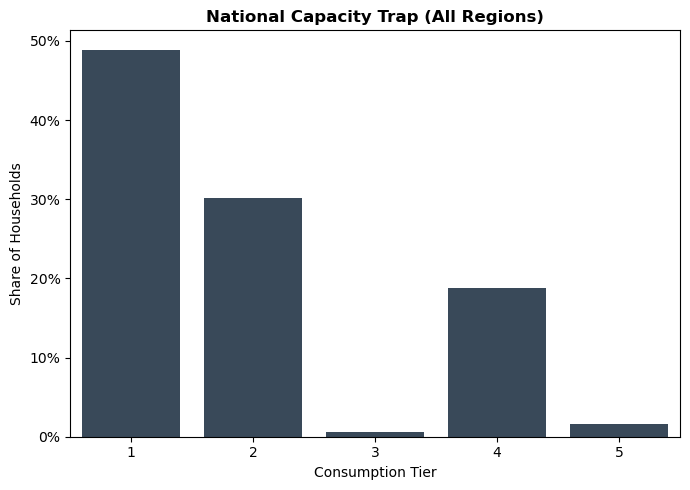

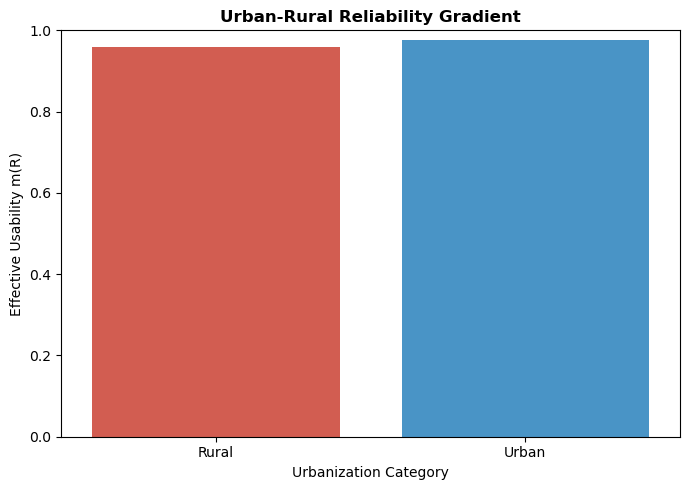

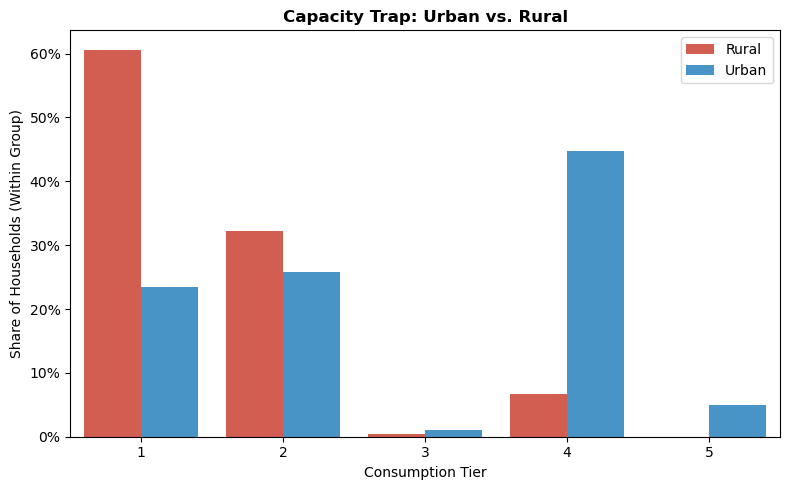

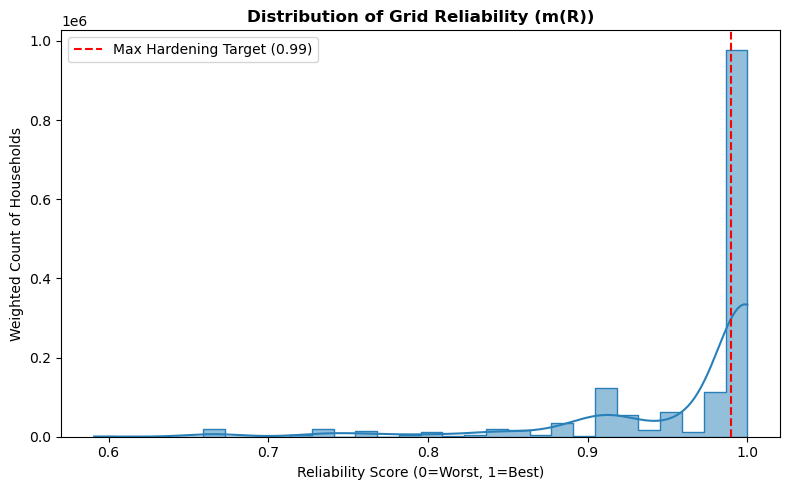

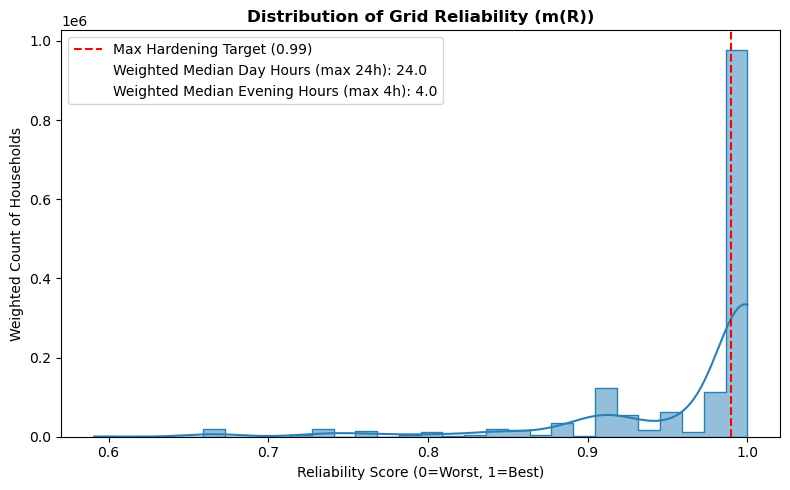

--- FINAL DIAGNOSTIC REPORT ---
1. RELIABILITY (m(R))
   - National Avg: 0.96
   - Urban:        0.98
   - Rural:        0.96
------------------------------
2. CAPACITY TRAP (Share of HHs in Tier 1)
   - National Avg: 48.9%
   - Urban:        23.5%
   - Rural:        60.6%


In [5]:
# Cell 5: Validation Visualizations & Diagnostic Report
# Prepare Data
grid_users = df[df['Conn_Grid']==1].copy()
grid_users['URB'] = np.where(grid_users['Is_Urban']==1, 'Urban', 'Rural')

# ---------- Weighted median helper ----------
def wmedian(x, w):
    x = np.asarray(x)
    w = np.asarray(w)
    s = np.argsort(x)
    x, w = x[s], w[s]
    cw = np.cumsum(w) / np.sum(w)
    return x[np.searchsorted(cw, 0.5)]

# ---------- Compute weighted medians ----------
rw_day_med = wmedian(grid_users["Hours"], grid_users["HH_WT"])
rw_eve_med = wmedian(grid_users["Evening_Hrs"], grid_users["HH_WT"])

# --- Plot 1: National Capacity Trap ---
plt.figure(figsize=(7,5))
nat_trap = grid_users.groupby('Tier')['HH_WT'].sum().reset_index()
nat_trap['Pct'] = nat_trap['HH_WT'] / nat_trap['HH_WT'].sum()
sns.barplot(data=nat_trap, x='Tier', y='Pct', order=[1,2,3,4,5], color="#34495e")
plt.title("National Capacity Trap (All Regions)", fontweight='bold')
plt.ylabel("Share of Households")
plt.xlabel("Consumption Tier")
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.savefig("fig_capacity_trap_national.png", dpi=300)
plt.show()

# --- Plot 2: Urban-Rural Reliability Gradient ---
plt.figure(figsize=(7,5))
cliff_data = grid_users.groupby('URB')[['m_R','HH_WT']].apply(
    lambda x: np.average(x['m_R'], weights=x['HH_WT'])
).reset_index(name='m_R')
sns.barplot(data=cliff_data, x='URB', y='m_R', hue='URB', legend=False,
            order=['Rural','Urban'], palette=["#e74c3c","#3498db"])
plt.title("Urban-Rural Reliability Gradient", fontweight='bold')
plt.ylabel("Effective Usability m(R)")
plt.xlabel("Urbanization Category")
plt.ylim(0,1)
plt.tight_layout()
plt.savefig("fig_reliability_gradient.png", dpi=300) 
plt.show()

# --- Plot 3: Capacity Trap by URB ---
plt.figure(figsize=(8,5))
trap_data = grid_users.groupby(['URB','Tier'])['HH_WT'].sum().reset_index()
totals = grid_users.groupby('URB')['HH_WT'].sum()
trap_data['Pct'] = trap_data.apply(lambda x: x['HH_WT'] / totals[x['URB']], axis=1)
sns.barplot(data=trap_data, x='Tier', y='Pct', hue='URB',
            hue_order=['Rural','Urban'], order=[1,2,3,4,5],
            palette=["#e74c3c","#3498db"])
plt.title("Capacity Trap: Urban vs. Rural", fontweight='bold')
plt.xlabel("Consumption Tier")
plt.ylabel("Share of Households (Within Group)")
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.legend(title="")
plt.tight_layout()
plt.savefig("fig_capacity_trap_urban_rural.png", dpi=300)
plt.show()

# --- Reliability Distribution ---
plt.figure(figsize=(8,5))
sns.histplot(data=grid_users, x='m_R', weights='HH_WT', 
             bins=30, kde=True, color="#2980b9", element="step")
plt.title("Distribution of Grid Reliability (m(R))", fontweight='bold')
plt.xlabel("Reliability Score (0=Worst, 1=Best)")
plt.ylabel("Weighted Count of Households")
plt.axvline(0.99, color='red', linestyle='--', label='Max Hardening Target (0.99)')
plt.legend()
plt.tight_layout()
plt.savefig("fig_reliability_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(
    data=grid_users,
    x='m_R',
    weights='HH_WT',
    bins=30,
    kde=True,
    color="#2980b9",
    element="step"
)

plt.title("Distribution of Grid Reliability (m(R))", fontweight='bold')
plt.xlabel("Reliability Score (0=Worst, 1=Best)")
plt.ylabel("Weighted Count of Households")

plt.axvline(0.99, color='red', linestyle='--', label='Max Hardening Target (0.99)')

# ---------- Legend text block ----------
plt.plot([], [], ' ', label=f"Weighted Median Day Hours (max 24h): {rw_day_med:.1f}")
plt.plot([], [], ' ', label=f"Weighted Median Evening Hours (max 4h): {rw_eve_med:.1f}")

plt.legend()
plt.tight_layout()
plt.savefig("fig_reliability_distribution.png", dpi=300)
plt.show()

# --- Diagnostics (numbers) ---
def get_trap_share(subset_df):
    if subset_df.empty: return 0.0
    tier1_weight = subset_df[subset_df['Tier'] <= 1]['HH_WT'].sum()
    total_weight = subset_df['HH_WT'].sum()
    return tier1_weight / total_weight if total_weight > 0 else 0

national_trap = get_trap_share(grid_users)
national_mr = np.average(grid_users['m_R'], weights=grid_users['HH_WT'])
urban_subset = grid_users[grid_users['URB']=='Urban']
rural_subset = grid_users[grid_users['URB']=='Rural']
urban_trap = get_trap_share(urban_subset)
rural_trap = get_trap_share(rural_subset)
urban_mr_val = np.average(urban_subset['m_R'], weights=urban_subset['HH_WT'])
rural_mr_val = np.average(rural_subset['m_R'], weights=rural_subset['HH_WT'])

print("--- FINAL DIAGNOSTIC REPORT ---")
print("1. RELIABILITY (m(R))")
print(f"   - National Avg: {national_mr:.2f}")
print(f"   - Urban:        {urban_mr_val:.2f}")
print(f"   - Rural:        {rural_mr_val:.2f}")
print("-"*30)
print("2. CAPACITY TRAP (Share of HHs in Tier 1)")
print(f"   - National Avg: {national_trap:.1%}")
print(f"   - Urban:        {urban_trap:.1%}")
print(f"   - Rural:        {rural_trap:.1%}")


--- CREDIT LIFT CALCULATION ---
Cash Adoption: 30.9%
Total Adoption (w/ Credit): 49.2%
CREDIT MULTIPLIER: 1.59x
Absolute lift used in model: 0.183


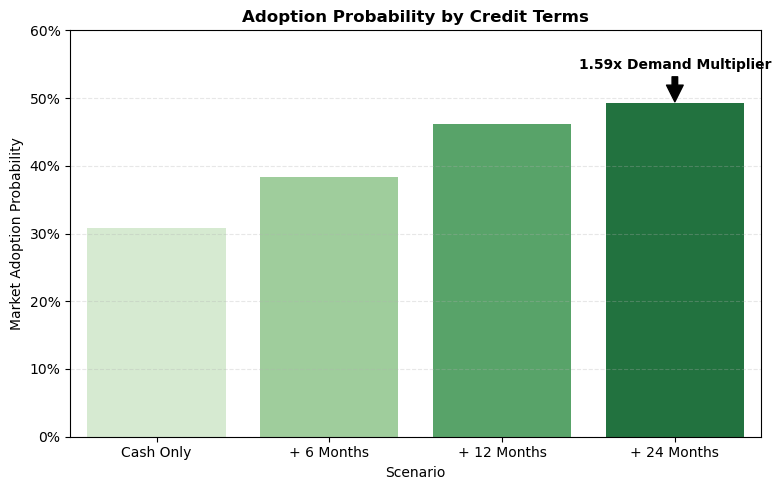

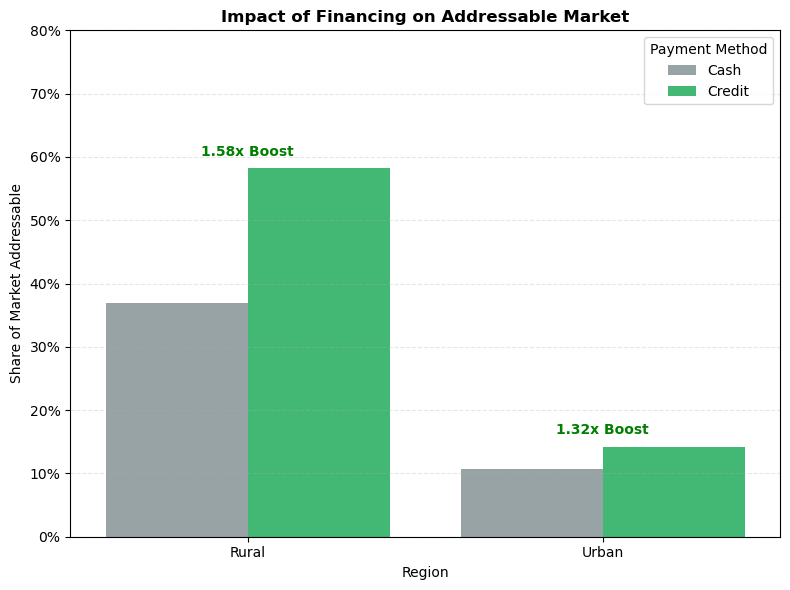

In [6]:
# Cell 5b: Credit Lift and Elasticity Analysis (Publication Ready)

print("\n--- CREDIT LIFT CALCULATION ---")
PROB_LIFT_FROM_DATA = 0.08  # default

if df_h_raw is not None:
    # 1) Build a clean Section-H table with its own weights
    h = (df_h_raw[['hhid','H03','H04','H05','H06','HH_WT']].copy()
           .rename(columns={'HH_WT':'H_WT'}))
    for c in ['H03','H04','H05','H06','H_WT']:
        h[c] = pd.to_numeric(h[c], errors='coerce')
    h[['H03','H04','H05','H06']] = h[['H03','H04','H05','H06']].fillna(0)
    h = h[h['H_WT'] > 0]

    # 2) Flags and national rates (weighted by H_WT)
    h['Accept_Cash']       = (h['H03'] == 1).astype(int)
    h['Accept_Credit_Any'] = ((h['H03']==1)|(h['H04']==1)|(h['H05']==1)|(h['H06']==1)).astype(int)

    rate_cash  = np.average(h['Accept_Cash'],       weights=h['H_WT'])
    rate_total = np.average(h['Accept_Credit_Any'], weights=h['H_WT'])
    multiplier = rate_total / rate_cash if rate_cash > 0 else np.nan
    abs_lift   = rate_total - rate_cash

    print(f"Cash Adoption: {rate_cash:.1%}")
    print(f"Total Adoption (w/ Credit): {rate_total:.1%}")
    print(f"CREDIT MULTIPLIER: {multiplier:.2f}x")
    print(f"Absolute lift used in model: {abs_lift:.3f}")

    # 3) Plot 1: The Credit Ladder (Cumulative Demand)
    rate_6m  = np.average(((h['H03']==1)|(h['H04']==1)).astype(int), weights=h['H_WT'])
    rate_12m = np.average(((h['H03']==1)|(h['H04']==1)|(h['H05']==1)).astype(int), weights=h['H_WT'])

    ladder = pd.DataFrame({
        'Scenario': ['Cash Only', '+ 6 Months', '+ 12 Months', '+ 24 Months'],
        'Adoption': [rate_cash, rate_6m, rate_12m, rate_total]
    })

    plt.figure(figsize=(8,5))
    sns.barplot(data=ladder, x='Scenario', y='Adoption', hue='Scenario', palette="Greens", legend=False)
    plt.title("Adoption Probability by Credit Terms", fontweight='bold')
    plt.ylabel("Market Adoption Probability")
    plt.ylim(0,0.6) # Set limit to 60% for clarity
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Annotate the boost
    plt.annotate(f"{multiplier:.2f}x Demand Multiplier",
                 xy=(3, rate_total), xytext=(3, rate_total+0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05), ha='center', fontweight='bold')
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig("fig_credit_ladder.png", dpi=300)
    plt.show()

    # 4) Plot 2: Regional Sensitivity (Urban vs Rural)
    h_ur = h.merge(df_roster[['hhid','HI04']], on='hhid', how='left')
    h_ur['Region'] = np.where(h_ur['HI04'] == 1, 'Urban', 'Rural')

    def wavg(s, w): return np.average(s, weights=w) if np.isfinite(w).all() and w.sum() > 0 else np.nan

    rows = []
    for region, g in h_ur.groupby('Region'):
        w  = g['H_WT']
        rc = wavg(g['Accept_Cash'], w)
        rt = wavg(g['Accept_Credit_Any'], w)
        rows.append({'Region': region, 'Scenario': 'Cash',   'Adoption': rc})
        rows.append({'Region': region, 'Scenario': 'Credit', 'Adoption': rt})

    plot_data = pd.DataFrame(rows)

    plt.figure(figsize=(8,6))
    sns.barplot(data=plot_data, x='Region', y='Adoption', hue='Scenario',
                palette=["#95a5a6", "#2ecc71"])
    plt.title("Impact of Financing on Addressable Market", fontweight='bold')
    plt.ylabel("Share of Market Addressable")
    plt.ylim(0,0.8)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    for i, region in enumerate(['Rural', 'Urban']): 
        if region not in plot_data['Region'].values: continue
        
        rc_val = plot_data.query("Region == @region and Scenario == 'Cash'")['Adoption'].values[0]
        rt_val = plot_data.query("Region == @region and Scenario == 'Credit'")['Adoption'].values[0]
        mult = (rt_val/rc_val) if rc_val > 0 else 0
        
        # Position calculations need to align with seaborn's bar placement
        plt.text(i, rt_val + 0.02, f"{mult:.2f}x Boost", 
                 color='green', fontweight='bold', ha='center')

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title="Payment Method")
    plt.tight_layout()
    plt.savefig("fig_credit_regional.png", dpi=300)
    plt.show()

    PROB_LIFT_FROM_DATA = float(abs_lift)
else:
    print("Section H not available; skipping ladder/multiplier plots.")

### Export Survey Inputs (Agents, Sector Aggregates, ABM Inputs, Assumptions)

In [7]:
# Cell 6: Export Survey Inputs (Agents, Sector Aggregates, ABM Inputs, Assumptions)

# 1) Micro-Agents
cols_micro = ['hhid','Cluster','PROVINCE','HH_WT','Conn_Grid','m_R','Tier','Is_Urban','Accept_Cash']
df[cols_micro].to_csv("abm_agents.csv", index=False)

# 2) Sector Aggregates
def weighted_agg(x):
    w = x['HH_WT']
    if w.sum() == 0:
        return pd.Series({'Avg_Reliability':0, 'Grid_Access':0, 'Productive_Share':0, 'Pop_Weight':0, 'Is_Urban':x['Is_Urban'].max()})
    return pd.Series({
        'Avg_Reliability': np.average(x['m_R'], weights=w),
        'Grid_Access': np.average(x['Conn_Grid'], weights=w),
        'Productive_Share': np.average((x['Tier']>=2).astype(float), weights=w),
        'Pop_Weight': w.sum(),
        'Is_Urban': x['Is_Urban'].max()
    })

cols_agg = ['m_R','Conn_Grid','Tier','HH_WT','Is_Urban']
sector_agg = df.groupby('Cluster')[cols_agg].apply(weighted_agg).reset_index()
sector_agg.to_csv("sector_aggregates.csv", index=False)

# 3) ABM inputs (renamed)
abm_inputs = sector_agg.rename(columns={
    'Avg_Reliability':'m_R_avg',
    'Grid_Access':'access_rate',
    'Productive_Share':'share_tier_ge2',
    'Pop_Weight':'pop_weight'
})[['Cluster','m_R_avg','access_rate','share_tier_ge2','pop_weight','Is_Urban']]
abm_inputs.to_csv("abm_inputs.csv", index=False)

# 4) Metadata
assumptions = {
    'HI04': '1=Urban, 2=Rural',
    'Conn_Grid': 'Grid (C002) OR Mini-Grid (C041)',
    'Hours': 'C029B (Grid) or C070D (Mini)',
    'Credit_Lift': 'Data-driven absolute lift from Section H (Accept_Credit_Any - Accept_Cash)'
}
with open('mtf_assumptions.json', 'w') as f:
    json.dump(assumptions, f, indent=2)

print("Artifacts Generated: abm_agents.csv, sector_aggregates.csv, abm_inputs.csv, mtf_assumptions.json")


Artifacts Generated: abm_agents.csv, sector_aggregates.csv, abm_inputs.csv, mtf_assumptions.json


### Utility Baseline (TTM) from RURA and Save

In [8]:
# Cell 7: Utility Baseline (TTM) - Updated with Q2 2024 Report

# TTM Calculation: Q3 2023 + Q4 2023 + Q1 2024 + Q2 2024
# Source: Table 3 (Sales) and Table 1 (Generation) from Q2 2024 Report

# 1. Total Electricity Sold (kWh)
# Q3'23: 268,746,539 | Q4'23: 275,148,722 | Q1'24: 279,071,046 | Q2'24: 297,107,270
total_sales_kwh = 268746539 + 275148722 + 279071046 + 297107270
total_sales_gwh = total_sales_kwh / 1e6

# 2. Residential Sales (kWh)
# Q3'23: 55,420,152 | Q4'23: 56,716,702 | Q1'24: 58,677,996 | Q2'24: 61,233,673
res_sales_kwh = 55420152 + 56716702 + 58677996 + 61233673
res_sales_gwh = res_sales_kwh / 1e6

# 3. Total Generation (kWh)
# Q3'23: 325,175,399 | Q4'23: 333,210,202 | Q1'24: 342,072,816 | Q2'24: 365,934,860
total_gen_kwh = 325175399 + 333210202 + 342072816 + 365934860

# 4. Network Losses (Technical + Commercial)
# Derived: (Gen - Sold) / Gen
loss_rate = (total_gen_kwh - total_sales_kwh) / total_gen_kwh

utility_baseline = {
    "Total_Customers": 1_360_000,   # Reg. estimate (approx stable)
    "Annual_Gen_GWh": total_gen_kwh / 1e6,
    "Annual_Sold_GWh": total_sales_gwh,
    "Residential_Sold_GWh": res_sales_gwh,
    "Residential_Share": res_sales_kwh / total_sales_kwh,
    "Technical_Losses": loss_rate,
    "Peak_Demand_MW": 233.74,       # UPDATED: New Peak from Q2 2024 
    "Cost_Recovery_Target_Frw": 360 # Tariff structure remains unchanged 
}

pd.DataFrame([utility_baseline]).to_csv("utility_baseline_2024.csv", index=False)

print(f">>> Baseline Updated (TTM Q2 2024).")
print(f"    - Peak Demand: {utility_baseline['Peak_Demand_MW']} MW")
print(f"    - System Losses: {loss_rate:.1%}")
print(f"    - Residential Sales: {res_sales_gwh:.1f} GWh/yr")

>>> Baseline Updated (TTM Q2 2024).
    - Peak Demand: 233.74 MW
    - System Losses: 18.0%
    - Residential Sales: 232.0 GWh/yr


### Stackelberg Game Configuration & Simulation

>>> Solving with STRICT SUPPLY-CONSTRAINED Logic...


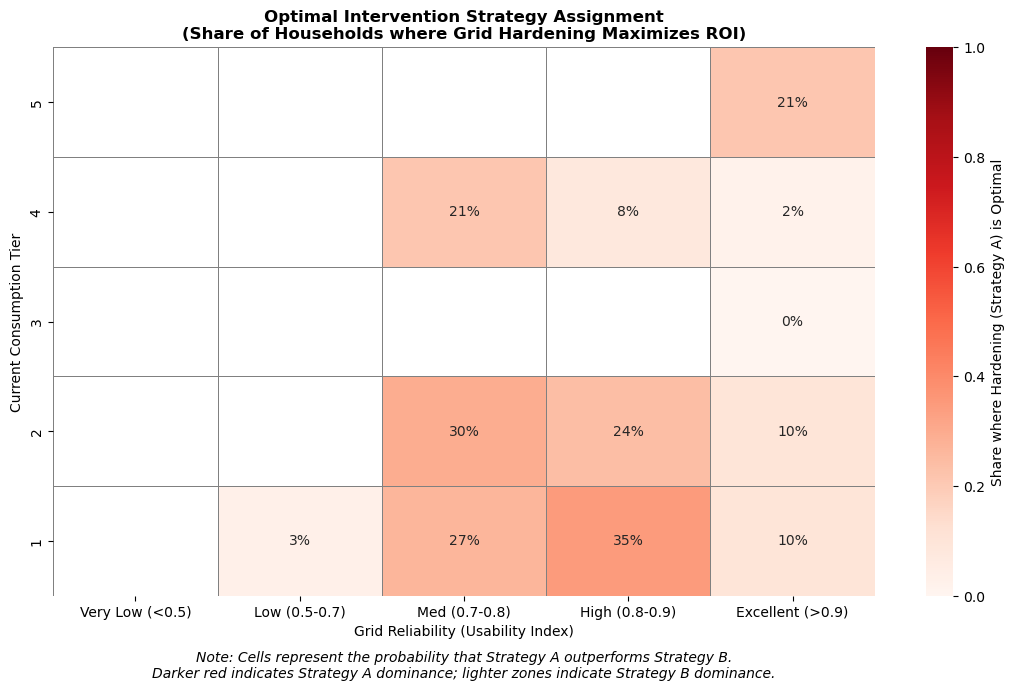


--- FINAL RESULTS (Connected HHs Only) ---
Financing (B) dominates in: 74.2% of households
Hardening (A) dominates in: 10.5% of households
No Viable Intervention:     15.3% of households


In [9]:
# Cell 8: Stackelberg Game Configuration & Simulation 
# --- Configuration ---
CONFIG_FAIR = {
    "P_BASE": 0.02,
    "COST_GRID_PER_HH": 100_000,
    "COST_CAPITAL_SUBSIDY": 300_000,
    "DEFAULT_RATE": 0.15,
    "ADMIN_PER_LOAN": 5_000,
    "TARIFF_BLOCKS": [
        {"limit": 15, "price": 89},
        {"limit": 50, "price": 310},
        {"limit": 9_999, "price": 369}
    ],
    "TIER_KWH_MONTHLY": {0:0, 1:5, 2:15, 3:30, 4:150, 5:250}
}

ABSOLUTE_LIFT = float(PROB_LIFT_FROM_DATA) if 'PROB_LIFT_FROM_DATA' in globals() else 0.183

# --- Billing Functions ---
def block_bill(kwh, blocks):
    bill, rem, prev = 0.0, kwh, 0
    for b in sorted(blocks, key=lambda z: z['limit']):
        span = b['limit'] - prev
        take = min(rem, span)
        bill += take * b['price']
        rem  -= take
        prev  = b['limit']
        if rem <= 0: break
    return bill

def annual_bill_from_kwh(monthly_kwh, config):
    return block_bill(monthly_kwh, config['TARIFF_BLOCKS']) * 12

def calculate_stackelberg_winner(agent_df, config, absolute_lift=0.15):
    df = agent_df.copy()

    # [Standard Aliases & Cleanup]
    if 'Tier' not in df.columns:
        df['Tier'] = df['CapacityTier'].astype(int) if 'CapacityTier' in df.columns else 0
    if 'm_R' not in df.columns:
        df['m_R'] = df['UsabilityIndex'].astype(float) if 'UsabilityIndex' in df.columns else 0.0
    for c in ['H03', 'H04', 'H05', 'H06']: 
        if c not in df.columns: df[c] = 0
    df['Accept_Cash'] = (pd.to_numeric(df['H03'], errors='coerce') == 1).astype(int)

    # --- 1. BASELINE ---
    base_kwh_monthly = df['Tier'].map(config['TIER_KWH_MONTHLY']).fillna(0)
    u0 = df['m_R'].replace(0, 0.01)
    
    # --- 2. STRATEGY A: HARDENING ---
    u1 = np.minimum(u0 * 1.2, 0.99)
    base_rev    = (base_kwh_monthly * u0).apply(lambda k: annual_bill_from_kwh(k, config))
    strat_A_rev = (base_kwh_monthly * u1).apply(lambda k: annual_bill_from_kwh(k, config))
    
    rev_gain_A = strat_A_rev - base_rev
    cost_A     = config['COST_GRID_PER_HH']
    df['ROI_A'] = np.where(df['Conn_Grid'] == 1, rev_gain_A / cost_A, 0.0)

    # --- 3. STRATEGY B: FINANCING ---
    next_kwh_monthly = (df['Tier'] + 1).clip(0, 5).map(config['TIER_KWH_MONTHLY'])
    next_rev = (next_kwh_monthly * u0).apply(lambda k: annual_bill_from_kwh(k, config))
    
    risk_cost   = config['COST_CAPITAL_SUBSIDY'] * config['DEFAULT_RATE']
    unit_cost_B = max(risk_cost + config['ADMIN_PER_LOAN'], 1e-9)
    
    rev_gain_B = (next_rev - base_rev) * absolute_lift * np.power(u0, 0.6)
    
    # Eligibility: Not Tier 5, and must not have accepted cash (unless willing to credit)
    elig_B = (df['Tier'] < 5) & ((df['Accept_Cash'] == 0) | (df['H04'] == 1) | (df['H05'] == 1) | (df['H06'] == 1))
    rev_gain_B[~elig_B] = 0.0
    
    df['ROI_B'] = np.where(df['Conn_Grid'] == 1, rev_gain_B / unit_cost_B, 0.0)

    # --- 4. STRICT WINNER LOGIC ---
    EPS = 1e-9
    df['Winner'] = 'None'
    
    # Hardening wins if ROI_A > ROI_B and ROI_A > 0
    mask_A = (df['ROI_A'] > df['ROI_B'] + EPS) & (df['ROI_A'] > EPS)
    df.loc[mask_A, 'Winner'] = 'Hardening'
    
    # Financing wins if ROI_B > ROI_A and ROI_B > 0
    mask_B = (df['ROI_B'] > df['ROI_A'] + EPS) & (df['ROI_B'] > EPS)
    df.loc[mask_B, 'Winner'] = 'Financing'
    
    return df



print(">>> Solving with STRICT SUPPLY-CONSTRAINED Logic...")
df_solved = calculate_stackelberg_winner(df_agents, CONFIG_FAIR, ABSOLUTE_LIFT)

# --- VISUALIZATION: ROBUST MASKED HEATMAP ---

# 1. Define Ordered Categories
rel_cats = ['Very Low (<0.5)', 'Low (0.5-0.7)', 'Med (0.7-0.8)', 'High (0.8-0.9)', 'Excellent (>0.9)']
rel_dtype = pd.CategoricalDtype(categories=rel_cats, ordered=True)

df_solved['Rel_Bin'] = pd.cut(
    df_solved['m_R'],
    bins=[0, 0.5, 0.7, 0.8, 0.9, 1.0],
    labels=rel_cats,
    include_lowest=True
).astype(rel_dtype)

# 2. Filter for Connected Only
conn = df_solved[df_solved['Conn_Grid'] == 1].copy()

# 3. Helper for Weighted Mean
def wmean(x, w):
    return np.average(x, weights=w) if np.sum(w) > 0 else np.nan

# 4. Prepare Flags
conn['A_win'] = (conn['Winner'] == 'Hardening').astype(float)
conn['B_win'] = (conn['Winner'] == 'Financing').astype(float)

# 5. Create Pivots
# pivot_A = (conn.groupby(['Tier', 'Rel_Bin'], observed=False)
#               .apply(lambda g: wmean(g['A_win'], g['HH_WT']))
#               .unstack())

pivot_A = (conn.groupby(['Tier', 'Rel_Bin'], observed=False)[['A_win', 'HH_WT']]
              .apply(lambda g: wmean(g['A_win'], g['HH_WT']))
              .unstack())

# Reindex Tiers (5 at top, 1 at bottom)
tier_order = [5, 4, 3, 2, 1]
pivot_A = pivot_A.reindex(index=tier_order, columns=rel_cats).fillna(0.0)

# 6. SUPPORT MASKING (Hide cells with < 0.5% of population)
support_w = (conn.groupby(['Tier', 'Rel_Bin'], observed=False)['HH_WT']
                .sum().unstack().reindex(index=tier_order, columns=rel_cats).fillna(0.0))

support_pct_all = support_w / support_w.values.sum() * 100.0
LOW_SUPPORT_THRESHOLD = 0.5 
mask_low = support_pct_all < LOW_SUPPORT_THRESHOLD

# Create Annotation Strings
annot = (pivot_A * 100).round().astype(int).astype(str) + '%'
annot = annot.where(~mask_low, other='')

# 7. Plotting
plt.figure(figsize=(11, 7))
sns.heatmap(
    pivot_A, 
    annot=annot, 
    fmt='', 
    cmap="Reds", 
    mask=mask_low,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Share where Hardening (Strategy A) is Optimal'},
    linewidths=0.5, linecolor='gray'
)

plt.title("Optimal Intervention Strategy Assignment\n(Share of Households where Grid Hardening Maximizes ROI)", fontsize=12, fontweight='bold')
plt.ylabel("Current Consumption Tier")
plt.xlabel("Grid Reliability (Usability Index)")

# Add Explanatory Note
plt.text(0.5, -0.15, "Note: Cells represent the probability that Strategy A outperforms Strategy B.\nDarker red indicates Strategy A dominance; lighter zones indicate Strategy B dominance.",
         transform=plt.gca().transAxes, ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig("fig_policy_dominance.png", dpi=300)
plt.show()

# --- VALIDATION REPORT ---
w = conn['HH_WT']
share_B = np.average(conn['B_win'], weights=w)
share_A = np.average(conn['A_win'], weights=w)
share_None = 1.0 - (share_A + share_B)

print(f"\n--- FINAL RESULTS (Connected HHs Only) ---")
print(f"Financing (B) dominates in: {share_B:.1%} of households")
print(f"Hardening (A) dominates in: {share_A:.1%} of households")
print(f"No Viable Intervention:     {share_None:.1%} of households")

In [10]:
# Cell 8b: Helper Functions for Default-Rate Sensitivity Heatmaps

def build_heatmap_pivot(df_solved):
    rel_cats = ['Very Low (<0.5)', 'Low (0.5-0.7)', 'Med (0.7-0.8)', 'High (0.8-0.9)', 'Excellent (>0.9)']
    rel_dtype = pd.CategoricalDtype(categories=rel_cats, ordered=True)

    df = df_solved.copy()

    df['Rel_Bin'] = pd.cut(
        df['m_R'],
        bins=[0, 0.5, 0.7, 0.8, 0.9, 1.0],
        labels=rel_cats,
        include_lowest=True
    ).astype(rel_dtype)

    conn = df[df['Conn_Grid'] == 1].copy()
    conn['A_win'] = (conn['Winner'] == 'Hardening').astype(float)

    def wmean(x, w):
        return np.average(x, weights=w) if np.sum(w) > 0 else np.nan

    # pivot_A = (
    #     conn.groupby(['Tier', 'Rel_Bin'], observed=False)
    #     .apply(lambda g: wmean(g['A_win'], g['HH_WT']))
    #     .unstack()
    # )

    pivot_A = (conn.groupby(['Tier', 'Rel_Bin'], observed=False)[['A_win', 'HH_WT']]
                  .apply(lambda g: wmean(g['A_win'], g['HH_WT']))
                  .unstack())

    tier_order = [5, 4, 3, 2, 1]
    pivot_A = pivot_A.reindex(index=tier_order, columns=rel_cats).fillna(0.0)

    support_w = (
        conn.groupby(['Tier', 'Rel_Bin'], observed=False)['HH_WT']
        .sum()
        .unstack()
        .reindex(index=tier_order, columns=rel_cats)
        .fillna(0.0)
    )

    support_pct_all = support_w / support_w.values.sum() * 100.0
    LOW_SUPPORT_THRESHOLD = 0.5
    mask_low = support_pct_all < LOW_SUPPORT_THRESHOLD

    annot = (pivot_A * 100).round().astype(int).astype(str) + '%'
    annot = annot.where(~mask_low, other='')

    return pivot_A, annot, mask_low

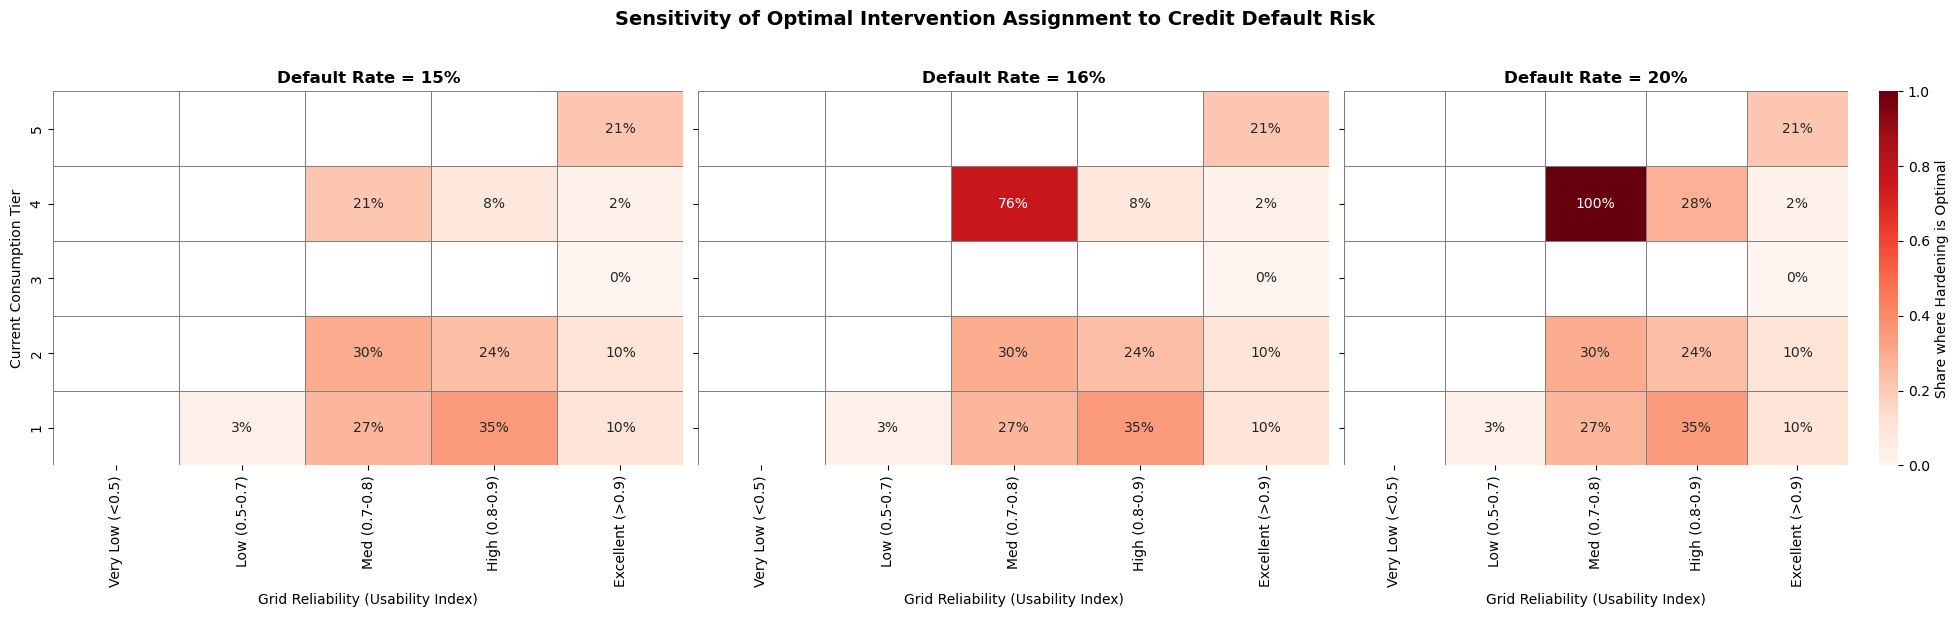

In [11]:
# Cell 8c: Three-Panel Sensitivity Heatmap for Default Rates

default_grid = [0.15, 0.16, 0.20]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, dr in zip(axes, default_grid):
    config_tmp = CONFIG_FAIR.copy()
    config_tmp["DEFAULT_RATE"] = dr

    df_tmp = calculate_stackelberg_winner(df_agents, config_tmp, ABSOLUTE_LIFT)
    pivot_tmp, annot_tmp, mask_tmp = build_heatmap_pivot(df_tmp)

    sns.heatmap(
        pivot_tmp,
        ax=ax,
        annot=annot_tmp,
        fmt='',
        cmap="Reds",
        mask=mask_tmp,
        vmin=0,
        vmax=1,
        cbar=(ax == axes[-1]),
        cbar_kws={'label': 'Share where Hardening is Optimal'} if ax == axes[-1] else None,
        linewidths=0.5,
        linecolor='gray'
    )

    ax.set_title(f"Default Rate = {int(dr*100)}%", fontsize=12, fontweight='bold')
    ax.set_xlabel("Grid Reliability (Usability Index)")
    if ax == axes[0]:
        ax.set_ylabel("Current Consumption Tier")
    else:
        ax.set_ylabel("")

plt.suptitle(
    "Sensitivity of Optimal Intervention Assignment to Credit Default Risk",
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig("fig_default_sensitivity_heatmaps.png", dpi=300, bbox_inches='tight')
plt.show()

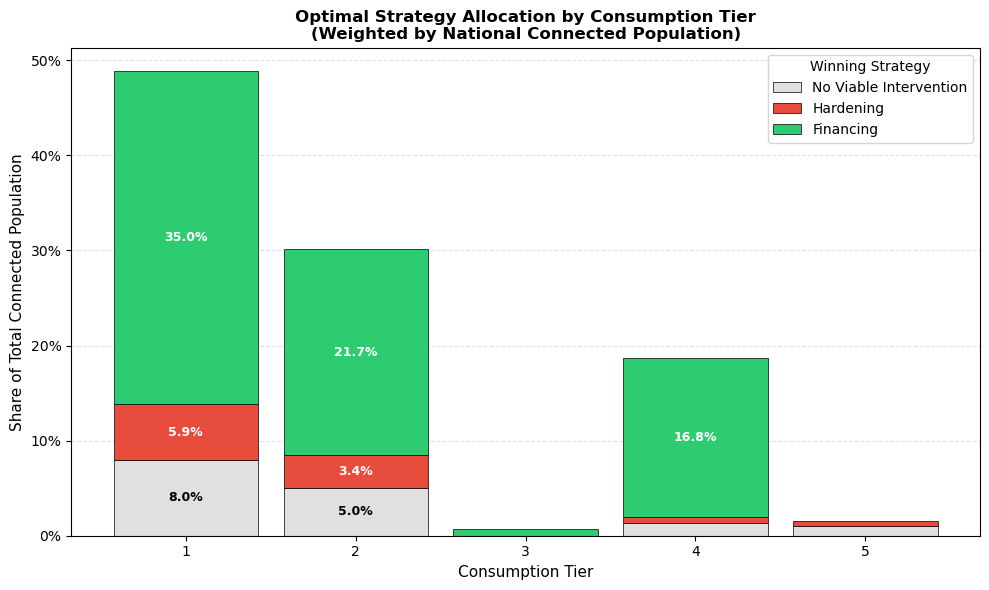


Column totals (Strategy Shares):
Winner
None         15.32%
Hardening    10.48%
Financing    74.20%
dtype: object

Tier totals (Demographic Shares):
Tier
1    48.88%
2    30.16%
3     0.66%
4    18.74%
5     1.56%
dtype: object


In [12]:
# Cell 13: Population-Weighted Dominance Analysis (Publication Ready)

import matplotlib.ticker as mtick
import numpy as np # Ensure numpy is imported for isclose

# 1. Prepare Data: Group by Tier and Winner, sum the Weights
tiers = [1, 2, 3, 4, 5]
pop_view = (
    df_solved[df_solved['Conn_Grid'] == 1]
      .groupby(['Tier', 'Winner'], observed=False)['HH_WT']
      .sum()
      .unstack(fill_value=0)
      .reindex(index=tiers, fill_value=0)
)

# 2. Convert to "Share of Total Population"
total_pop_weight = pop_view.values.sum()
pop_share = pop_view / total_pop_weight

# 3. Plot Stacked Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    'Financing': '#2ecc71', 
    'Hardening': '#e74c3c', 
    'None': '#e0e0e0'  # Light Gray
}

# Order: None -> Hardening -> Financing
plot_cols = ['None', 'Hardening', 'Financing']
pop_share = pop_share.reindex(columns=plot_cols, fill_value=0)

pop_share.plot(
    kind='bar', 
    stacked=True, 
    color=[colors[c] for c in plot_cols], 
    ax=ax, 
    width=0.85,
    edgecolor='black',
    linewidth=0.5
)

# 4. Formatting
ax.set_title("Optimal Strategy Allocation by Consumption Tier\n(Weighted by National Connected Population)", fontsize=12, fontweight='bold')
ax.set_ylabel("Share of Total Connected Population", fontsize=11)
ax.set_xlabel("Consumption Tier", fontsize=11)

# Format Y-axis as Percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_axisbelow(True); ax.yaxis.grid(True, linestyle='--', alpha=0.4)

# Legend
handles, labels = ax.get_legend_handles_labels()
labels = [l if l != 'None' else 'No Viable Intervention' for l in labels]
ax.legend(handles, labels, title="Winning Strategy", loc='upper right', frameon=True)

# 5. Robust Bar Labels
for container in ax.containers:
    vals = [p.get_height() for p in container]
    fc = container.patches[0].get_facecolor()
    luminance = 0.299*fc[0] + 0.587*fc[1] + 0.114*fc[2]
    text_color = 'black' if luminance > 0.6 else 'white'
    
    # Only label segments > 2%
    labels_pct = [f"{v:.1%}" if v > 0.02 else "" for v in vals]
    ax.bar_label(container, labels=labels_pct, label_type='center', 
                 color=text_color, fontsize=9, weight='bold')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("fig_strategy_distribution.png", dpi=300)
plt.show()

# 6. Exact Breakdown & Sanity Checks
col_totals = pop_share.sum(axis=0)
row_totals = pop_share.sum(axis=1)

# Assertions
assert np.isclose(col_totals.sum(), 1.0), "Winner columns must sum to 100%."
assert np.isclose(row_totals.sum(), 1.0), "Tier shares must sum to 100%."

print("\nColumn totals (Strategy Shares):")
print(col_totals.map(lambda x: f"{x:.2%}"))
print("\nTier totals (Demographic Shares):")
print(row_totals.map(lambda x: f"{x:.2%}"))

In [13]:
# Updated Leader Allocation Function (Mutually Exclusive Greedy)

def solve_allocation_by_marginal(agent_df, config, budget, absolute_lift=None):
    if absolute_lift is None and 'ABSOLUTE_LIFT' in globals():
        absolute_lift = ABSOLUTE_LIFT

    # 1. Calculate ROIs for everyone
    st = calculate_stackelberg_winner(agent_df, config, absolute_lift=absolute_lift)

    cost_A = max(config['COST_GRID_PER_HH'], 1e-9)
    # Ensure Cost B uses the Risk-Adjusted logic
    cost_B = max(config['ADMIN_PER_LOAN'] + config['DEFAULT_RATE']*config['COST_CAPITAL_SUBSIDY'], 1e-9)

    roiA = st['ROI_A'].values
    roiB = st['ROI_B'].values
    
    # 2. DECISION: Pick the better strategy per household
    choose_B = roiB > roiA

    # 3. Create the "Density" list (Gain per Cost)
    dens   = np.where(choose_B, roiB, roiA)
    costs  = np.where(choose_B, cost_B, cost_A)
    labels = np.where(choose_B, 1, 0) # 0=A, 1=B
    mass   = st['HH_WT'].values

    # 4. Filter: Ignore non-positive investments
    keep = dens > 0
    dens, costs, labels, mass = dens[keep], costs[keep], labels[keep], mass[keep]

    # 5. Sort by Density (Best Bang-for-Buck first)
    order = np.argsort(-dens)
    
    spend_A = spend_B = profit = 0.0
    rem = float(budget)

    for j in order:
        if rem <= 0: break
        c, w = float(costs[j]), float(mass[j])
        
        # How many households can we treat?
        take = min(w, rem / c)
        if take <= 0: continue
        
        profit += dens[j] * c * take    # Gain
        
        if labels[j] == 0: 
            spend_A += c * take
        else:              
            spend_B += c * take
            
        rem -= c * take

    return spend_A, spend_B, profit

=== One-shot Stackelberg Allocation (Leader) ===
Budget:          20,000,000,000 RWF
Spend on A:      1,588,274,760 RWF  (7.9%)
Spend on B:      18,411,725,240 RWF  (92.1%)
Expected profit: 23,179,112,802 RWF


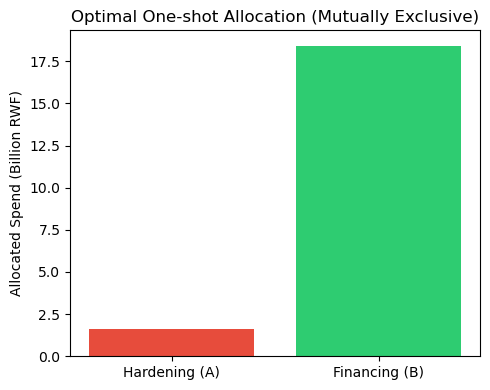

In [14]:
# Run the allocation
BUDGET_ONE_SHOT = CONFIG_FAIR.get('ANNUAL_BUDGET_RWF', 20_000_000_000)

spend_A, spend_B, profit = solve_allocation_by_marginal(
    df_agents, CONFIG_FAIR, BUDGET_ONE_SHOT, absolute_lift=ABSOLUTE_LIFT
)

total = spend_A + spend_B
print("=== One-shot Stackelberg Allocation (Leader) ===")
print(f"Budget:          {BUDGET_ONE_SHOT:,.0f} RWF")
print(f"Spend on A:      {spend_A:,.0f} RWF  ({spend_A/max(total,1e-9):.1%})")
print(f"Spend on B:      {spend_B:,.0f} RWF  ({spend_B/max(total,1e-9):.1%})")
print(f"Expected profit: {profit:,.0f} RWF")

# Quick bar plot
plt.figure(figsize=(5,4))
plt.bar(['Hardening (A)','Financing (B)'], [spend_A/1e9, spend_B/1e9], color=['#e74c3c', '#2ecc71'])
plt.ylabel('Allocated Spend (Billion RWF)')
plt.title('Optimal One-shot Allocation (Mutually Exclusive)')
plt.tight_layout()
plt.show()

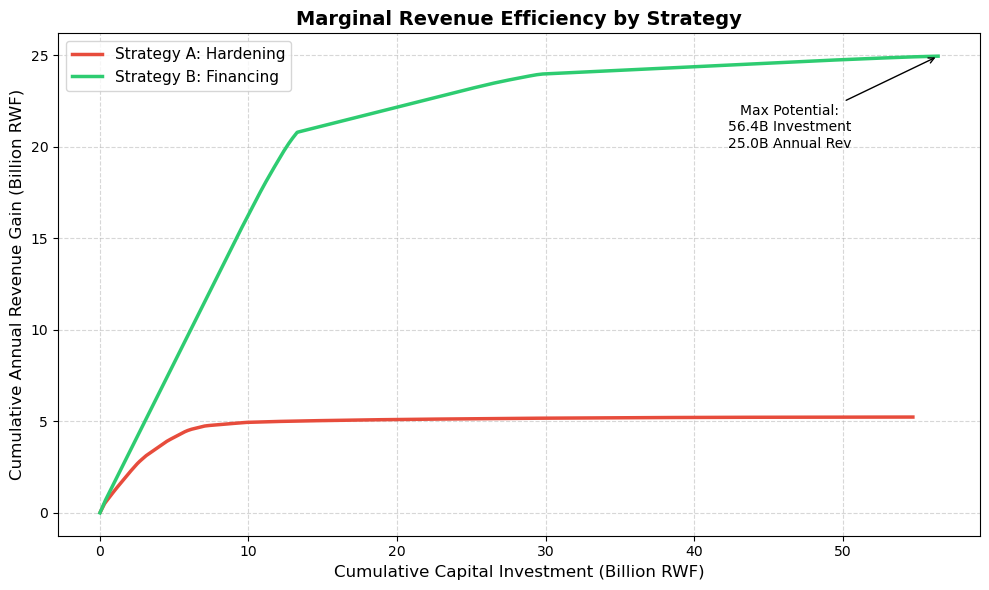

--- STRATEGY B POTENTIAL ---
Total Investable Capital: 56.42 Billion RWF
Total Annual Revenue:     24.96 Billion RWF
Average Payback Period:   2.26 Years


In [15]:
# Cell 12: Cumulative Revenue vs Cost (Marginal Efficiency Frontier)

# --- Helper ---
def calculate_annual_bill(monthly_kwh, config):
    return block_bill(monthly_kwh, config['TARIFF_BLOCKS']) * 12

# --- Re-calculate Metrics based on df_solved ---
base_kwh = df_solved['Tier'].map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)
next_kwh = (df_solved['Tier'] + 1).clip(0, 5).map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)

u0 = df_solved['m_R'].replace(0, 0.01)
u1 = np.minimum(u0 * 1.2, 0.99)

# Baseline & Potential Revenue
base_rev = (base_kwh * u0).apply(lambda k: calculate_annual_bill(k, CONFIG_FAIR))
next_rev = (next_kwh * u0).apply(lambda k: calculate_annual_bill(k, CONFIG_FAIR))
strat_A_rev = (base_kwh * u1).apply(lambda k: calculate_annual_bill(k, CONFIG_FAIR))

# --- Strategy A: Hardening Analysis ---
gain_A = strat_A_rev - base_rev
cost_A = CONFIG_FAIR['COST_GRID_PER_HH']
roi_A  = np.where(df_solved['Conn_Grid']==1, gain_A / cost_A, 0.0)

# Filter for strictly positive ROI (Rational Investor)
A_df = pd.DataFrame({
    'roi': roi_A,
    'gain': gain_A * df_solved['HH_WT'],
    'cost': cost_A * df_solved['HH_WT'],
    'ok': (df_solved['Conn_Grid']==1)
}).query("ok")
A_df = A_df[A_df['roi'] > 1e-9].sort_values('roi', ascending=False)

A_df['cum_cost'] = A_df['cost'].cumsum()
A_df['cum_gain'] = A_df['gain'].cumsum()

# --- Strategy B: Financing Analysis ---
risk_cost = CONFIG_FAIR['COST_CAPITAL_SUBSIDY'] * CONFIG_FAIR['DEFAULT_RATE']
unit_cost_B = risk_cost + CONFIG_FAIR['ADMIN_PER_LOAN']

gain_B = (next_rev - base_rev) * ABSOLUTE_LIFT * np.power(u0, 0.6)

# Eligibility Filter
elig_B = (df_solved['Tier'] < 5) & (
    (df_solved['Accept_Cash'] == 0) | (df_solved['H04'] == 1) | 
    (df_solved['H05'] == 1) | (df_solved['H06'] == 1)
)

roi_B = np.where((df_solved['Conn_Grid']==1) & elig_B, gain_B / unit_cost_B, 0.0)

# Filter for strictly positive ROI
B_df = pd.DataFrame({
    'roi': roi_B,
    'gain': (gain_B * df_solved['HH_WT']).where(elig_B & (df_solved['Conn_Grid']==1), 0.0),
    'cost': (unit_cost_B * df_solved['HH_WT']).where(elig_B & (df_solved['Conn_Grid']==1), 0.0),
})
B_df = B_df[B_df['roi'] > 1e-9].sort_values('roi', ascending=False)

B_df['cum_cost'] = B_df['cost'].cumsum()
B_df['cum_gain'] = B_df['gain'].cumsum()

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Plot Curves
plt.plot(A_df['cum_cost']/1e9, A_df['cum_gain']/1e9, label='Strategy A: Hardening', linewidth=2.5, color='#e74c3c')
plt.plot(B_df['cum_cost']/1e9, B_df['cum_gain']/1e9, label='Strategy B: Financing', linewidth=2.5, color='#2ecc71')

# Labels and Formatting
plt.xlabel("Cumulative Capital Investment (Billion RWF)", fontsize=12)
plt.ylabel("Cumulative Annual Revenue Gain (Billion RWF)", fontsize=12)
plt.title("Marginal Revenue Efficiency by Strategy", fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Annotate Max Potential for Strategy B
if not B_df.empty:
    max_rev = B_df['cum_gain'].max()/1e9
    max_inv = B_df['cum_cost'].max()/1e9
    plt.annotate(f'Max Potential:\n{max_inv:.1f}B Investment\n{max_rev:.1f}B Annual Rev', 
                 xy=(max_inv, max_rev), 
                 xytext=(max_inv - 10, max_rev - 5), 
                 arrowprops=dict(facecolor='black', arrowstyle="->"),
                 fontsize=10, ha='center')

plt.tight_layout()
plt.savefig("fig_marginal_revenue_curves.png", dpi=300)
plt.show()

# --- Output Statistics ---
print(f"--- STRATEGY B POTENTIAL ---")
print(f"Total Investable Capital: {B_df['cum_cost'].max()/1e9:.2f} Billion RWF")
print(f"Total Annual Revenue:     {B_df['cum_gain'].max()/1e9:.2f} Billion RWF")
print(f"Average Payback Period:   {(B_df['cum_cost'].max()/B_df['cum_gain'].max()):.2f} Years")

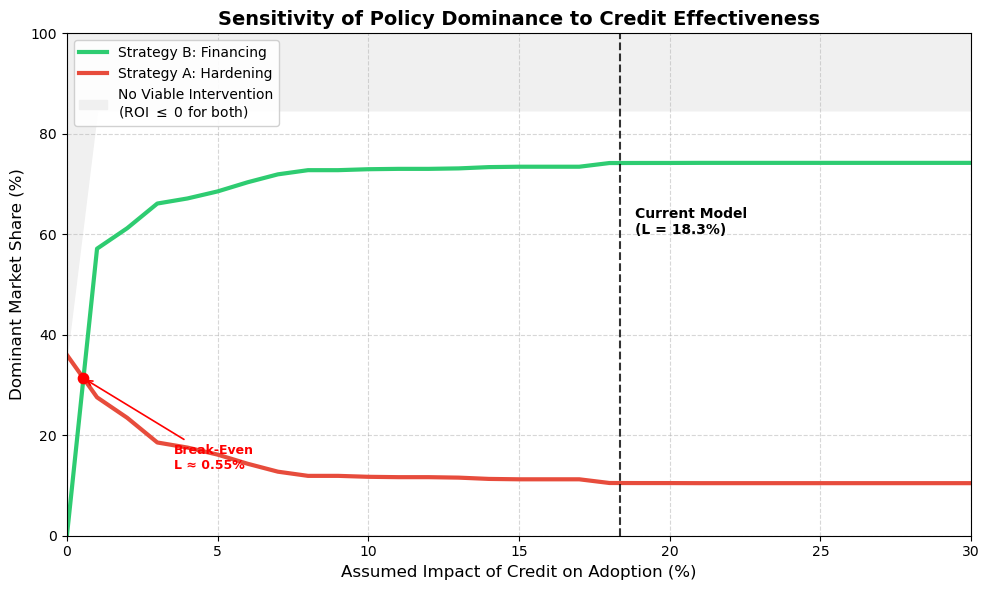

--- ROBUSTNESS REPORT (Connected HHs Only) ---
Consistency Check at L=0.0%:
  - Strategy B Share: 0.0% (Should be 0.0%)
  - Strategy A Share: 36.0% (Households needing reliability)
  - No Intervention:  64.0%

Break-even (intersection): L ≈ 0.55% at share ≈ 31.36% of connected HHs.
Saturation: Strategy B plateaus at ~74.2%.
  -> Why not 100%? Remaining 15.3% likely have ROI≤0 even with high credit lift.


In [16]:
# Cell 13: Sensitivity Analysis – Break-Even & Safety Margin
import matplotlib.ticker as mtick

def solve_with_lift_strict(L):
    # 1. Run the game with hypothetical Lift 'L'
    tmp = calculate_stackelberg_winner(df_agents, CONFIG_FAIR, absolute_lift=L)
    
    # FILTER: Align with Methodology (Post-connection analysis only)
    universe = tmp[tmp['Conn_Grid'] == 1].copy()
    w = universe['HH_WT']
    if w.sum() == 0:
        return 0.0, 0.0
    
    roi_A = universe['ROI_A']
    roi_B = universe['ROI_B']
    
    # EPSILON for numerical stability
    EPS = 1e-9
    
    # 2. STRICT DOMINANCE LOGIC
    mask_B_wins = (roi_B > roi_A + EPS) & (roi_B > EPS)
    mask_A_wins = (roi_A > roi_B + EPS) & (roi_A > EPS)
    
    # Weighted shares within the CONNECTED population
    share_B = np.average(mask_B_wins.astype(float), weights=w)
    share_A = np.average(mask_A_wins.astype(float), weights=w)
    return share_A, share_B

# 1. Run the Sensitivity Sweep
lifts = np.linspace(0.00, 0.30, 31)  # includes 0.0 exactly
res = np.array([solve_with_lift_strict(L) for L in lifts])

# 2. Break-even (true intersection via linear interpolation)
EPS = 1e-12
delta = res[:, 1] - res[:, 0]  # shares in [0,1]

# Find intersection
brackets = np.where((delta[:-1] < 0) & (delta[1:] > 0))[0]
if len(brackets) == 0:
    i_star = int(np.argmin(np.abs(delta)))
    L_star = lifts[i_star]
    share_star = res[i_star, 1]
else:
    i0 = int(brackets[0])
    d0, d1 = delta[i0], delta[i0 + 1]
    t = d0 / (d0 - d1)
    L_star = lifts[i0] + t * (lifts[i0 + 1] - lifts[i0])
    share_star = res[i0, 1] + t * (res[i0 + 1, 1] - res[i0, 1])

break_even_lift = L_star
break_even_share = share_star

# 3. Plot
plt.figure(figsize=(10, 6))

# Define Data Series
x = lifts * 100
y_A = res[:, 0] * 100
y_B = res[:, 1] * 100
y_None = 100 - (y_A + y_B)

# Curves
plt.plot(x, y_B, label='Strategy B: Financing', color='#2ecc71', linewidth=3)
plt.plot(x, y_A, label='Strategy A: Hardening', color='#e74c3c', linewidth=3)

# "No Intervention" zone
plt.fill_between(x, y_A + y_B, 100, color='#f0f0f0',
                 label='No Viable Intervention\n(ROI $\\leq$ 0 for both)')

# Actual model marker
current_lift_pct = ABSOLUTE_LIFT * 100
plt.axvline(current_lift_pct, color='black', linestyle='--', alpha=0.8)
plt.text(current_lift_pct + 0.5, 60, f'Current Model\n(L = {current_lift_pct:.1f}%)',
         color='black', fontweight='bold', fontsize=10)

# Break-even marker
x_star = break_even_lift * 100
y_star = break_even_share * 100
plt.scatter([x_star], [y_star], color='red', s=55, zorder=5)
plt.annotate(f'Break-Even\nL ≈ {x_star:.2f}%',
             xy=(x_star, y_star),
             xytext=(x_star + 3, y_star - 18),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
             color='red', fontsize=9, fontweight='bold')

# Formatting
plt.xlabel("Assumed Impact of Credit on Adoption (%)", fontsize=12)
plt.ylabel("Dominant Market Share (%)", fontsize=12)
plt.title("Sensitivity of Policy Dominance to Credit Effectiveness", fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.xlim(0, 30)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.savefig("fig_sensitivity_breakeven.png", dpi=300)
plt.show()

# --- VALIDATION REPORT ---
print(f"--- ROBUSTNESS REPORT (Connected HHs Only) ---")
print(f"Consistency Check at L=0.0%:")
print(f"  - Strategy B Share: {y_B[0]:.1f}% (Should be 0.0%)")
print(f"  - Strategy A Share: {y_A[0]:.1f}% (Households needing reliability)")
print(f"  - No Intervention:  {y_None[0]:.1f}%")

assert abs(y_B[0]) < 1e-6, "Logic Error: Strategy B has non-zero share at 0% lift!"
assert (y_A[0] + y_B[0] + y_None[0]) > 99.9, "Logic Error: Shares do not sum to 100%"

print(f"\nBreak-even (intersection): L ≈ {break_even_lift*100:.2f}% "
      f"at share ≈ {break_even_share*100:.2f}% of connected HHs.")
print(f"Saturation: Strategy B plateaus at ~{res[-1,1]*100:.1f}%.")
sat_gap = 100 - (res[-1,0]*100 + res[-1,1]*100)
print(f"  -> Why not 100%? Remaining {sat_gap:.1f}% likely have ROI≤0 even with high credit lift.")

Simulations Complete.

--- Strategy B: Guarantee (Year 1 from initial state) ---
Treated units available from budget: 400,000
Total eligible weight: 1,489,272.5
Total treated weight: 400,000.0
Expected upgrader weight: 72,374.2
Expected Tier 3+ gain weight (mainly T2->T3): 18,437.5

Eligible weight by tier:
 Tier  eligible_weight
    1    723867.453732
    2    465939.132450
    3     21631.440942
    4    277834.425393

Treated weight by tier:
 Tier  treated_weight
    2   100534.133665
    3    21631.440942
    4   277834.425393

Expected upgrade flows (origin -> destination):
 origin_tier  dest_tier  upgrader_wt
           2          3 18437.525619
           3          4  3893.997349
           4          5 50042.678613

--- Strategy B: Principal (Year 1 from initial state) ---
Treated units available from budget: 65,574
Total eligible weight: 1,489,272.5
Total treated weight: 65,573.8
Expected upgrader weight: 12,007.2
Expected Tier 3+ gain weight (mainly T2->T3): 0.0

Eligible we

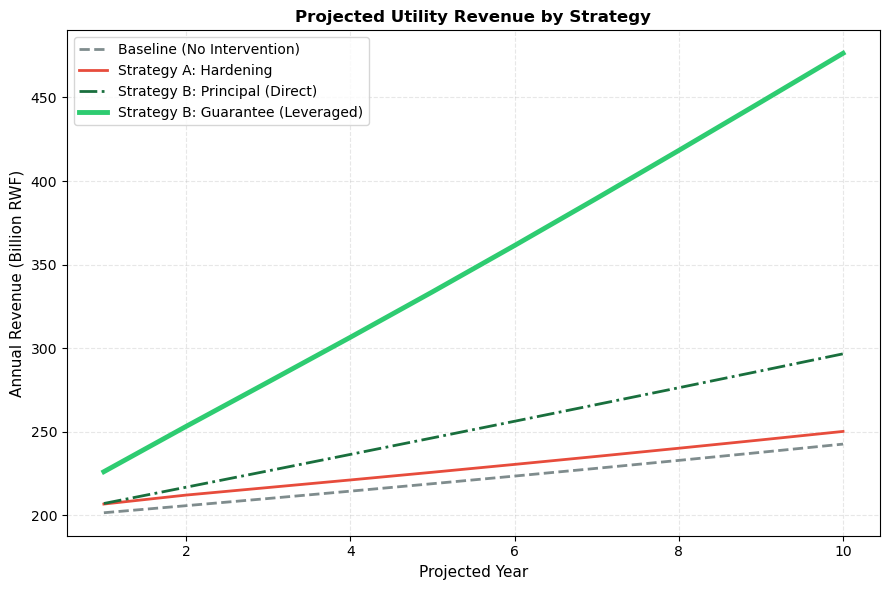

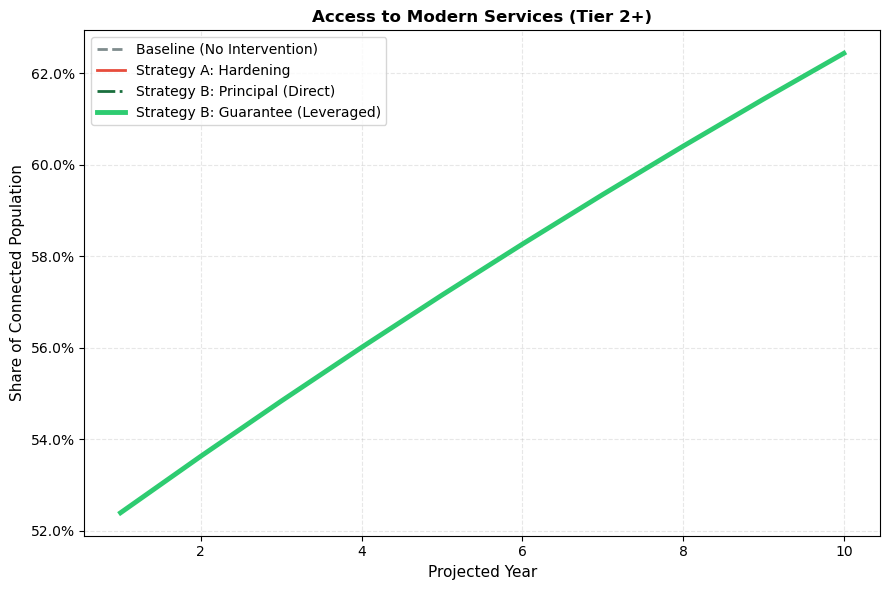

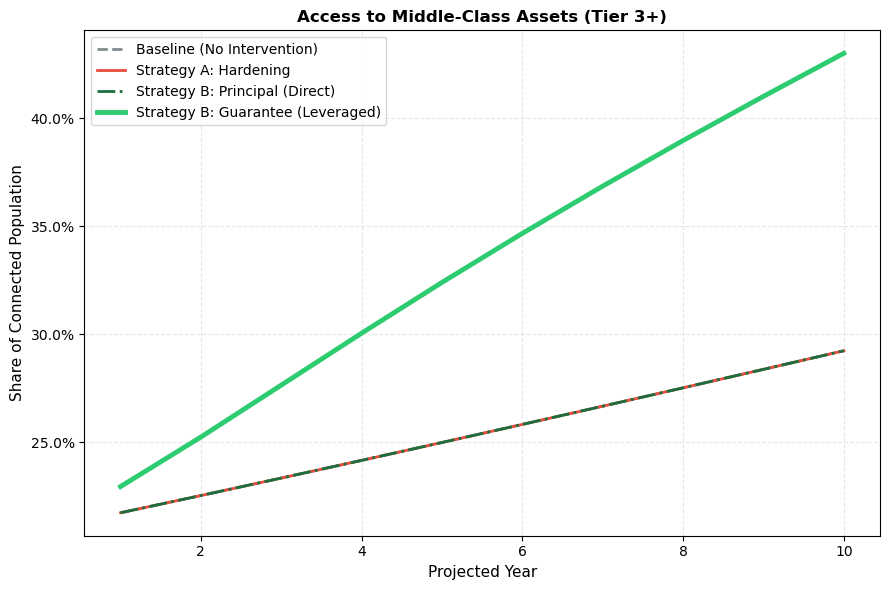

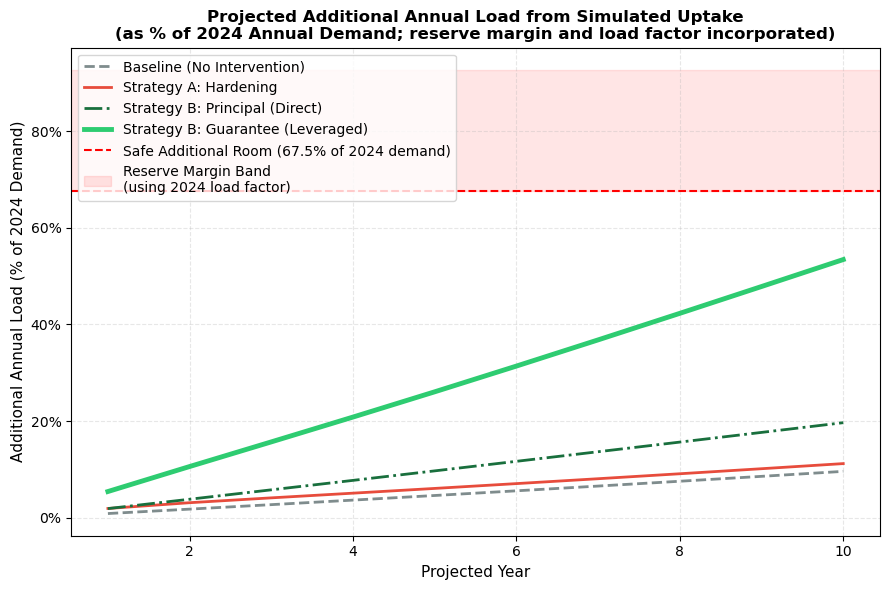

0.6967244046945168

--- RESULTS SUMMARY (Year 10) ---
Initial model-implied connected load: 692.8 GWh/yr
------------------------------
Revenue (Guarantee): 476.4B RWF
Revenue (Principal): 296.7B RWF
Revenue Multiplier:  1.61x
------------------------------
Tier 3+ (Guarantee): 43.0%
Tier 3+ (Principal): 29.2%
------------------------------
Added Load (Guarantee): +789.1 GWh/yr
Added Load (Principal): +290.8 GWh/yr
Added Load (Hardening): +165.9 GWh/yr
------------------------------
Safe Additional Room:     997 GWh/yr
Absolute Additional Room: 1,368 GWh/yr
------------------------------
Added Load Share (Guarantee): 53.4% of 2024 demand
Added Load Share (Principal): 19.7% of 2024 demand
Added Load Share (Hardening): 11.2% of 2024 demand
Safe Additional Room:         67.5% of 2024 demand
Absolute Additional Room:     92.6% of 2024 demand

--- Year 10 Tier 3+ comparison ---
Baseline (No Intervention): 0.2924
Strategy A: Hardening: 0.2924
Strategy B: Principal (Direct): 0.2924
Strategy B

In [17]:
# --- Cell 14: 10-Year Projections & Additional-Load Analysis ---
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# === 1. CONFIGURATION ===
BUDGET_PER_YEAR = 20_000_000_000
ABS_LIFT = float(PROB_LIFT_FROM_DATA) if 'PROB_LIFT_FROM_DATA' in globals() else 0.183
BASE_DRIFT_RATE = 0.026

# Cost Constants
COST_A = CONFIG_FAIR['COST_GRID_PER_HH']  # 100,000

principal = CONFIG_FAIR['COST_CAPITAL_SUBSIDY']
exp_loss = principal * CONFIG_FAIR['DEFAULT_RATE']
admin_cost = CONFIG_FAIR['ADMIN_PER_LOAN']

# Define the two costs for B
COST_B_GUARANTEE = max(exp_loss + admin_cost, 1e-9)   # ~29k
COST_B_PRINCIPAL = max(principal + admin_cost, 1e-9)  # ~305k

# --- 2. HELPER FUNCTIONS ---
def block_bill(kwh, blocks):
    bill, rem, prev = 0.0, float(kwh), 0
    for b in sorted(blocks, key=lambda z: z['limit']):
        span = b['limit'] - prev
        take = min(rem, span)
        bill += take * b['price']
        rem -= take
        prev = b['limit']
        if rem <= 0:
            break
    return bill

def current_revenue(state):
    mask = state['Conn_Grid'] == 1
    if not mask.any():
        return 0.0
    base = state.loc[mask].copy()
    monthly_kwh = base['Tier'].map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0).astype(float)
    eff_kwh = monthly_kwh * base['m_R'].clip(0, 1)
    bills = eff_kwh.apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    return float(np.sum(bills * base['HH_WT']))

def share_tier_x_plus(state, x=2):
    mask = state['Conn_Grid'] == 1
    wtot = float(state.loc[mask, 'HH_WT'].sum())
    if wtot <= 0:
        return 0.0
    return float(np.sum((state.loc[mask, 'Tier'] >= x).astype(float) * state.loc[mask, 'HH_WT']) / wtot)

def current_load_gwh(state):
    """
    Model-implied annual load of the simulated connected population.
    This is NOT national system load; it is the load represented by the model state.
    """
    mask = state['Conn_Grid'] == 1
    if not mask.any():
        return 0.0
    base = state.loc[mask].copy()
    monthly_kwh = base['Tier'].map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0).astype(float)
    eff_kwh = monthly_kwh * base['m_R'].clip(0, 1)
    return float(np.sum(eff_kwh * 12 * base['HH_WT']) / 1e6)

def additional_load_gwh(state, base_load_gwh):
    """
    Additional annual load relative to the model's initial state.
    This is the correct quantity to compare against safe additional room for new load.
    """
    return current_load_gwh(state) - base_load_gwh

def apply_natural_drift(state, rate=BASE_DRIFT_RATE):
    st = state.copy()
    mask = st['Conn_Grid'] == 1

    st['HH_Move'] = np.where(mask, st['HH_WT'] * rate, 0.0)
    st['HH_Stay'] = st['HH_WT'] - st['HH_Move']

    moved = st[mask].copy()
    moved['HH_WT'] = moved['HH_Move']
    moved['Tier'] = (moved['Tier'] + 1).clip(0, 5)

    stayed = st.copy()
    stayed['HH_WT'] = stayed['HH_Stay']

    out = pd.concat([stayed, moved], ignore_index=True)
    return out[out['HH_WT'] > 0].groupby(['hhid', 'Conn_Grid', 'Tier', 'm_R'], as_index=False)['HH_WT'].sum()

def with_roi_columns(state, cost_A, cost_B):
    st = state.copy()
    base_kwh = st['Tier'].map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)
    next_kwh = (st['Tier'] + 1).clip(0, 5).map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)
    m0 = st['m_R'].astype(float).clip(0, 1)

    bill0 = (base_kwh * m0).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    bill1 = (next_kwh * m0).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12

    m1 = np.minimum(m0 * 1.2, 0.99)
    bill0_improved = (base_kwh * m1).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    st['ROI_A'] = np.where(st['Conn_Grid'] == 1, (bill0_improved - bill0) / max(cost_A, 1e-9), 0.0)

    prob_adopt = ABS_LIFT * np.power(m0, 0.6)
    st['ROI_B'] = np.where(
        (st['Conn_Grid'] == 1) & (st['Tier'] < 5),
        ((bill1 - bill0) * prob_adopt) / max(cost_B, 1e-9),
        0.0
    )
    return st

def apply_hardening_year(state, budget, cost_A):
    state = apply_natural_drift(state)
    st = with_roi_columns(state, cost_A, 999999)

    mask_eligible = (st['Conn_Grid'] == 1) & (st['ROI_A'] > 0)
    candidates = st[mask_eligible].copy()
    others = st[~mask_eligible].copy()

    if candidates.empty:
        return state

    candidates = candidates.sort_values('ROI_A', ascending=False)
    treat_units = budget / cost_A
    candidates['cumsum_wt'] = candidates['HH_WT'].cumsum()
    candidates['take'] = np.minimum(
        candidates['HH_WT'],
        np.maximum(0, treat_units - (candidates['cumsum_wt'] - candidates['HH_WT']))
    )

    treated = candidates[candidates['take'] > 0].copy()
    treated['HH_WT'] = treated['take']
    treated['m_R'] = np.minimum(treated['m_R'] * 1.2, 0.99)

    candidates['HH_WT'] = np.maximum(candidates['HH_WT'] - candidates['take'], 0.0)
    untreated = candidates[candidates['HH_WT'] > 1e-9]

    out = pd.concat([treated, untreated, others], ignore_index=True)
    return out.groupby(['hhid', 'Conn_Grid', 'Tier', 'm_R'], as_index=False)['HH_WT'].sum()

def apply_finance_year(state, budget, cost_B):
    state = apply_natural_drift(state)
    st = with_roi_columns(state, 999999, cost_B)

    mask_eligible = (st['Conn_Grid'] == 1) & (st['ROI_B'] > 0)
    candidates = st[mask_eligible].copy()
    others = st[~mask_eligible].copy()

    if candidates.empty:
        return state

    candidates = candidates.sort_values('ROI_B', ascending=False)
    treat_units = budget / cost_B
    candidates['cumsum_wt'] = candidates['HH_WT'].cumsum()
    candidates['take'] = np.minimum(
        candidates['HH_WT'],
        np.maximum(0, treat_units - (candidates['cumsum_wt'] - candidates['HH_WT']))
    )

    treated_part = candidates[candidates['take'] > 0].copy()
    treated_part['HH_WT'] = treated_part['take']

    p = np.clip(ABS_LIFT * np.power(treated_part['m_R'].astype(float).clip(0, 1), 0.0 + 0.6), 0.0, 1.0)

    upgraders = treated_part.copy()
    upgraders['HH_WT'] = treated_part['HH_WT'] * p
    upgraders['Tier'] = (upgraders['Tier'] + 1).clip(0, 5)

    non_upgraders = treated_part.copy()
    non_upgraders['HH_WT'] = treated_part['HH_WT'] * (1 - p)

    candidates['HH_WT'] = np.maximum(candidates['HH_WT'] - candidates['take'], 0.0)
    untreated = candidates[candidates['HH_WT'] > 1e-9]

    out = pd.concat([upgraders, non_upgraders, untreated, others], ignore_index=True)
    return out.groupby(['hhid', 'Conn_Grid', 'Tier', 'm_R'], as_index=False)['HH_WT'].sum()

# --- 3. RUNNING ALL SCENARIOS ---
state0 = df_agents.rename(columns={'UsabilityIndex': 'm_R', 'CapacityTier': 'Tier'}).copy()
for c in ['Tier', 'm_R', 'HH_WT', 'Conn_Grid']:
    state0[c] = pd.to_numeric(state0[c], errors='coerce').fillna(0)

years = range(1, 11)

# Initial model-implied load of the connected population
initial_model_load_gwh = current_load_gwh(state0)

# Names for Legend
KEY_BASE = 'Baseline (No Intervention)'
KEY_STRAT_A = 'Strategy A: Hardening'
KEY_GUAR = 'Strategy B: Guarantee (Leveraged)'
KEY_PRINC = 'Strategy B: Principal (Direct)'

results = {
    KEY_BASE:    {'rev': [], 'share2': [], 'share3': [], 'added_load': [], 'total_load': []},
    KEY_STRAT_A: {'rev': [], 'share2': [], 'share3': [], 'added_load': [], 'total_load': []},
    KEY_GUAR:    {'rev': [], 'share2': [], 'share3': [], 'added_load': [], 'total_load': []},
    KEY_PRINC:   {'rev': [], 'share2': [], 'share3': [], 'added_load': [], 'total_load': []}
}

# 1. Baseline
curr = state0.copy()
for t in years:
    curr = apply_natural_drift(curr)
    total_load = current_load_gwh(curr)
    results[KEY_BASE]['rev'].append(current_revenue(curr))
    results[KEY_BASE]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_BASE]['share3'].append(share_tier_x_plus(curr, 3))
    results[KEY_BASE]['total_load'].append(total_load)
    results[KEY_BASE]['added_load'].append(total_load - initial_model_load_gwh)

# 2. Strategy A
curr = state0.copy()
for t in years:
    curr = apply_hardening_year(curr, BUDGET_PER_YEAR, COST_A)
    total_load = current_load_gwh(curr)
    results[KEY_STRAT_A]['rev'].append(current_revenue(curr))
    results[KEY_STRAT_A]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_STRAT_A]['share3'].append(share_tier_x_plus(curr, 3))
    results[KEY_STRAT_A]['total_load'].append(total_load)
    results[KEY_STRAT_A]['added_load'].append(total_load - initial_model_load_gwh)

# 3. Strategy B (Guarantee)
curr = state0.copy()
for t in years:
    curr = apply_finance_year(curr, BUDGET_PER_YEAR, COST_B_GUARANTEE)
    total_load = current_load_gwh(curr)
    results[KEY_GUAR]['rev'].append(current_revenue(curr))
    results[KEY_GUAR]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_GUAR]['share3'].append(share_tier_x_plus(curr, 3))
    results[KEY_GUAR]['total_load'].append(total_load)
    results[KEY_GUAR]['added_load'].append(total_load - initial_model_load_gwh)

# 4. Strategy B (Principal)
curr = state0.copy()
for t in years:
    curr = apply_finance_year(curr, BUDGET_PER_YEAR, COST_B_PRINCIPAL)
    total_load = current_load_gwh(curr)
    results[KEY_PRINC]['rev'].append(current_revenue(curr))
    results[KEY_PRINC]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_PRINC]['share3'].append(share_tier_x_plus(curr, 3))
    results[KEY_PRINC]['total_load'].append(total_load)
    results[KEY_PRINC]['added_load'].append(total_load - initial_model_load_gwh)

print("Simulations Complete.")

# --- Diagnostic: Finance transition flows by tier ---

def finance_transition_diagnostics(state, budget, cost_B, label="Finance Scenario"):
    """
    Run one finance year from a given state and report:
    - eligible households by tier
    - treated households by tier
    - realized upgrader weight by tier transition
    - how much of the treatment actually increases Tier 3+ access
    """
    # Step 1: apply drift exactly as in your model
    state_after_drift = apply_natural_drift(state)

    # Step 2: compute ROI columns
    st = with_roi_columns(state_after_drift, 999999, cost_B)

    mask_eligible = (st['Conn_Grid'] == 1) & (st['ROI_B'] > 0)
    candidates = st[mask_eligible].copy()

    if candidates.empty:
        print(f"\n--- {label} ---")
        print("No eligible candidates.")
        return None

    # Step 3: same treatment allocation logic
    candidates = candidates.sort_values('ROI_B', ascending=False).copy()
    treat_units = budget / cost_B
    candidates['cumsum_wt'] = candidates['HH_WT'].cumsum()
    candidates['take'] = np.minimum(
        candidates['HH_WT'],
        np.maximum(0, treat_units - (candidates['cumsum_wt'] - candidates['HH_WT']))
    )

    treated_part = candidates[candidates['take'] > 0].copy()
    treated_part['HH_WT_treated'] = treated_part['take']

    # Adoption probability exactly as in model
    p = np.clip(
        ABS_LIFT * np.power(treated_part['m_R'].astype(float).clip(0, 1), 0.6),
        0.0, 1.0
    )
    treated_part['p_adopt'] = p

    # Realized expected upgrader/non-upgrader weights
    treated_part['upgrader_wt'] = treated_part['HH_WT_treated'] * treated_part['p_adopt']
    treated_part['non_upgrader_wt'] = treated_part['HH_WT_treated'] * (1 - treated_part['p_adopt'])

    treated_part['origin_tier'] = treated_part['Tier'].astype(int)
    treated_part['dest_tier'] = (treated_part['Tier'] + 1).clip(0, 5).astype(int)

    # Summaries
    eligible_by_tier = (
        candidates.groupby('Tier', as_index=False)['HH_WT']
        .sum()
        .rename(columns={'HH_WT': 'eligible_weight'})
    )

    treated_by_tier = (
        treated_part.groupby('origin_tier', as_index=False)['HH_WT_treated']
        .sum()
        .rename(columns={'origin_tier': 'Tier', 'HH_WT_treated': 'treated_weight'})
    )

    upgrade_flows = (
        treated_part.groupby(['origin_tier', 'dest_tier'], as_index=False)['upgrader_wt']
        .sum()
        .sort_values(['origin_tier', 'dest_tier'])
    )

    # Which upgrades matter for Tier 3+?
    # Only transitions from Tier < 3 to Tier >= 3 increase share3
    tier3_plus_gain = treated_part.loc[
        (treated_part['origin_tier'] < 3) & (treated_part['dest_tier'] >= 3),
        'upgrader_wt'
    ].sum()

    total_upgrader_wt = treated_part['upgrader_wt'].sum()
    total_treated_wt = treated_part['HH_WT_treated'].sum()

    print(f"\n--- {label} ---")
    print(f"Treated units available from budget: {treat_units:,.0f}")
    print(f"Total eligible weight: {candidates['HH_WT'].sum():,.1f}")
    print(f"Total treated weight: {total_treated_wt:,.1f}")
    print(f"Expected upgrader weight: {total_upgrader_wt:,.1f}")
    print(f"Expected Tier 3+ gain weight (mainly T2->T3): {tier3_plus_gain:,.1f}")

    print("\nEligible weight by tier:")
    print(eligible_by_tier.to_string(index=False))

    print("\nTreated weight by tier:")
    print(treated_by_tier.to_string(index=False))

    print("\nExpected upgrade flows (origin -> destination):")
    print(upgrade_flows.to_string(index=False))

    return {
        'eligible_by_tier': eligible_by_tier,
        'treated_by_tier': treated_by_tier,
        'upgrade_flows': upgrade_flows,
        'treated_part': treated_part
    }


# --- Run diagnostics on initial state for both finance models ---
diag_guar = finance_transition_diagnostics(
    state0.copy(),
    BUDGET_PER_YEAR,
    COST_B_GUARANTEE,
    label="Strategy B: Guarantee (Year 1 from initial state)"
)

diag_princ = finance_transition_diagnostics(
    state0.copy(),
    BUDGET_PER_YEAR,
    COST_B_PRINCIPAL,
    label="Strategy B: Principal (Year 1 from initial state)"
)

# --- 4. PLOTTING ---
colors = {
    KEY_BASE:    '#7f8c8d',
    KEY_STRAT_A: '#e74c3c',
    KEY_GUAR:    '#2ecc71',
    KEY_PRINC:   '#196f3d'
}
styles = {
    KEY_BASE:    '--',
    KEY_STRAT_A: '-',
    KEY_GUAR:    '-',
    KEY_PRINC:   '-.'
}
widths = {
    KEY_BASE:    2,
    KEY_STRAT_A: 2,
    KEY_GUAR:    3.5,
    KEY_PRINC:   2
}

def plot_scenario(metric_key, title, ylabel, filename, percent=False,
                  h_line=None, h_line_label=None,
                  reserve_top=None, reserve_label=None,
                  legend_loc='upper left'):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(9, 6))
    plot_order = [KEY_BASE, KEY_STRAT_A, KEY_PRINC, KEY_GUAR]

    for name in plot_order:
        y_vals = np.array(results[name][metric_key])
        if metric_key == 'rev':
            y_vals = y_vals / 1e9

        plt.plot(
            years, y_vals,
            linestyle=styles[name],
            color=colors[name],
            linewidth=widths[name],
            label=name
        )

    if h_line is not None:
        plt.axhline(y=h_line, color='red', linestyle='--', linewidth=1.5, label=h_line_label)

    if (h_line is not None) and (reserve_top is not None):
        plt.axhspan(h_line, reserve_top, color='red', alpha=0.10, label=reserve_label)

    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel("Projected Year", fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=10, loc=legend_loc, frameon=True)

    if percent:
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# --- GRID CAPACITY CONSTANTS (LCPDP 2024 Review) ---
INSTALLED_CAPACITY_MW = 466.2
RESERVE_MARGIN = 0.15
PEAK_DEMAND_2024_MW = 242.0
ANNUAL_DEMAND_2024_GWH = 1477.0

# Safe annual ceiling
load_factor = (ANNUAL_DEMAND_2024_GWH * 1000) / (PEAK_DEMAND_2024_MW * 8760)
max_safe_peak_mw = INSTALLED_CAPACITY_MW / (1 + RESERVE_MARGIN)
max_safe_capacity_gwh = (max_safe_peak_mw * 8760 * load_factor) / 1000

# Absolute annual ceiling if reserve is exhausted
absolute_capacity_gwh = (INSTALLED_CAPACITY_MW * 8760 * load_factor) / 1000

# Safe and absolute additional room for NEW load
safe_additional_room_gwh = max_safe_capacity_gwh - ANNUAL_DEMAND_2024_GWH
absolute_additional_room_gwh = absolute_capacity_gwh - ANNUAL_DEMAND_2024_GWH

# Express additional load relative to 2024 annual demand
safe_additional_room_pct = safe_additional_room_gwh / ANNUAL_DEMAND_2024_GWH
absolute_additional_room_pct = absolute_additional_room_gwh / ANNUAL_DEMAND_2024_GWH

for key in results:
    results[key]['added_load_pct'] = [
        x / ANNUAL_DEMAND_2024_GWH for x in results[key]['added_load']
    ]

# Generate standard plots
plot_scenario(
    'rev',
    "Projected Utility Revenue by Strategy",
    "Annual Revenue (Billion RWF)",
    "fig_proj_revenue.png"
)

plot_scenario(
    'share2',
    "Access to Modern Services (Tier 2+)",
    "Share of Connected Population",
    "fig_proj_tier2.png",
    percent=True
)

plot_scenario(
    'share3',
    "Access to Middle-Class Assets (Tier 3+)",
    "Share of Connected Population",
    "fig_proj_tier3.png",
    percent=True
)

# # Plot ADDITIONAL load against safe additional room
# plot_scenario(
#     'added_load',
#     "Projected Additional Annual Load from Simulated Uptake",
#     "Additional Annual Load (GWh)",
#     "fig_proj_added_load_gwh.png",
#     h_line=safe_additional_room_gwh,
#     h_line_label=f"Safe Additional Room ({safe_additional_room_gwh:,.0f} GWh)",
#     reserve_top=absolute_additional_room_gwh,
#     reserve_label="Reserve Margin Band",
#     legend_loc='upper left'
# )

# Plot ADDITIONAL load as a share of 2024 annual demand
plot_scenario(
    'added_load_pct',
    "Projected Additional Annual Load from Simulated Uptake\n"
    "(as % of 2024 Annual Demand; reserve margin and load factor incorporated)",
    "Additional Annual Load (% of 2024 Demand)",
    "fig_proj_added_load_pct.png",
    percent=True,
    h_line=safe_additional_room_pct,
    h_line_label=f"Safe Additional Room ({safe_additional_room_pct:.1%} of 2024 demand)",
    reserve_top=absolute_additional_room_pct,
    reserve_label="Reserve Margin Band\n(using 2024 load factor)",
    legend_loc='upper left'
)

# --- 5. FINAL RESULTS SUMMARY ---
print(load_factor)
print("\n--- RESULTS SUMMARY (Year 10) ---")
print(f"Initial model-implied connected load: {initial_model_load_gwh:,.1f} GWh/yr")
print("-" * 30)
print(f"Revenue (Guarantee): {results[KEY_GUAR]['rev'][-1]/1e9:.1f}B RWF")
print(f"Revenue (Principal): {results[KEY_PRINC]['rev'][-1]/1e9:.1f}B RWF")
print(f"Revenue Multiplier:  {results[KEY_GUAR]['rev'][-1] / results[KEY_PRINC]['rev'][-1]:.2f}x")
print("-" * 30)
print(f"Tier 3+ (Guarantee): {results[KEY_GUAR]['share3'][-1]:.1%}")
print(f"Tier 3+ (Principal): {results[KEY_PRINC]['share3'][-1]:.1%}")
print("-" * 30)
print(f"Added Load (Guarantee): {results[KEY_GUAR]['added_load'][-1]:+.1f} GWh/yr")
print(f"Added Load (Principal): {results[KEY_PRINC]['added_load'][-1]:+.1f} GWh/yr")
print(f"Added Load (Hardening): {results[KEY_STRAT_A]['added_load'][-1]:+.1f} GWh/yr")
print("-" * 30)
print(f"Safe Additional Room:     {safe_additional_room_gwh:,.0f} GWh/yr")
print(f"Absolute Additional Room: {absolute_additional_room_gwh:,.0f} GWh/yr")

print("-" * 30)
print(f"Added Load Share (Guarantee): {results[KEY_GUAR]['added_load_pct'][-1]:.1%} of 2024 demand")
print(f"Added Load Share (Principal): {results[KEY_PRINC]['added_load_pct'][-1]:.1%} of 2024 demand")
print(f"Added Load Share (Hardening): {results[KEY_STRAT_A]['added_load_pct'][-1]:.1%} of 2024 demand")
print(f"Safe Additional Room:         {safe_additional_room_pct:.1%} of 2024 demand")
print(f"Absolute Additional Room:     {absolute_additional_room_pct:.1%} of 2024 demand")

print("\n--- Year 10 Tier 3+ comparison ---")
for key in [KEY_BASE, KEY_STRAT_A, KEY_PRINC, KEY_GUAR]:
    print(f"{key}: {results[key]['share3'][-1]:.4f}")

--- COST PARAMETERS ---
Strategy A (Hardening):   100,000 RWF
Strategy B (Guarantee):   50,000 RWF (Risk Only)
Strategy B (Principal):   305,000 RWF (Full Cost)
------------------------------
Simulations Complete.


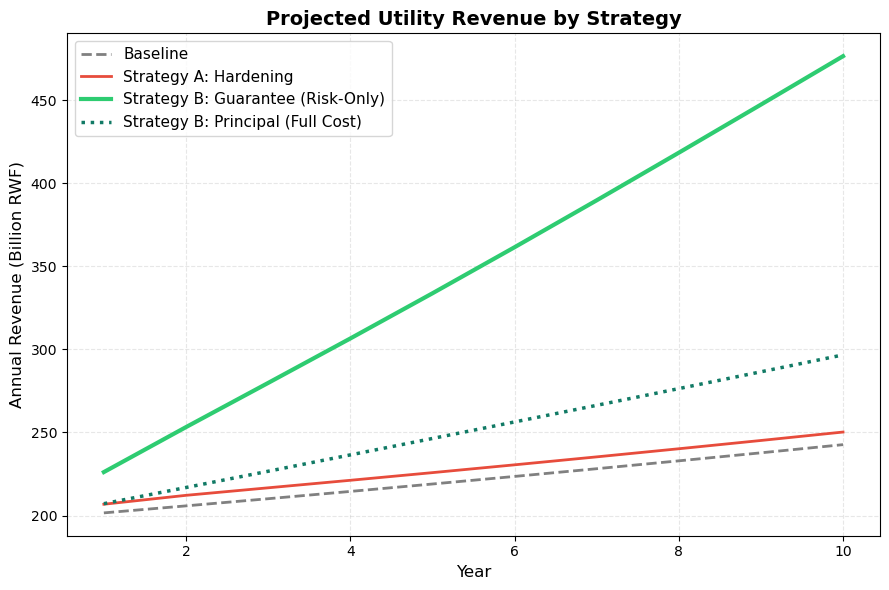

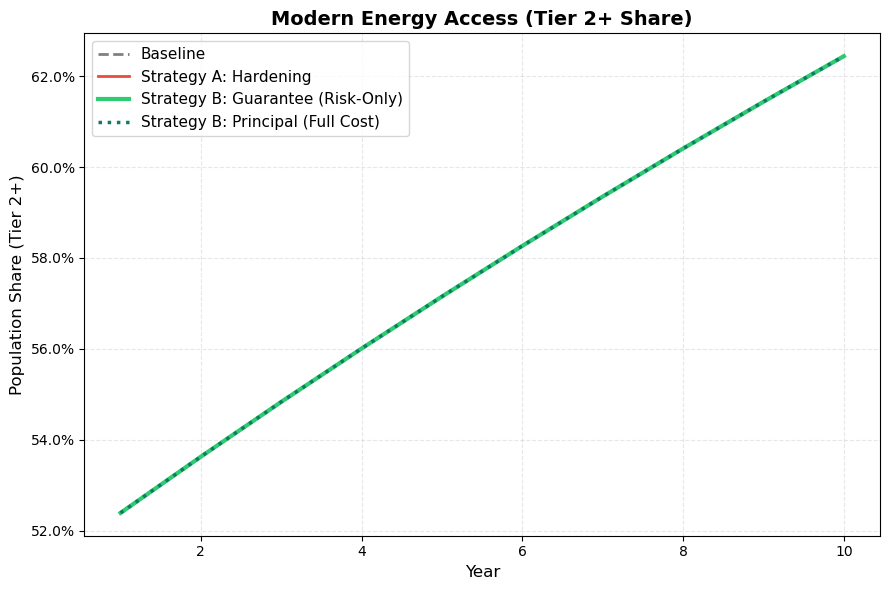

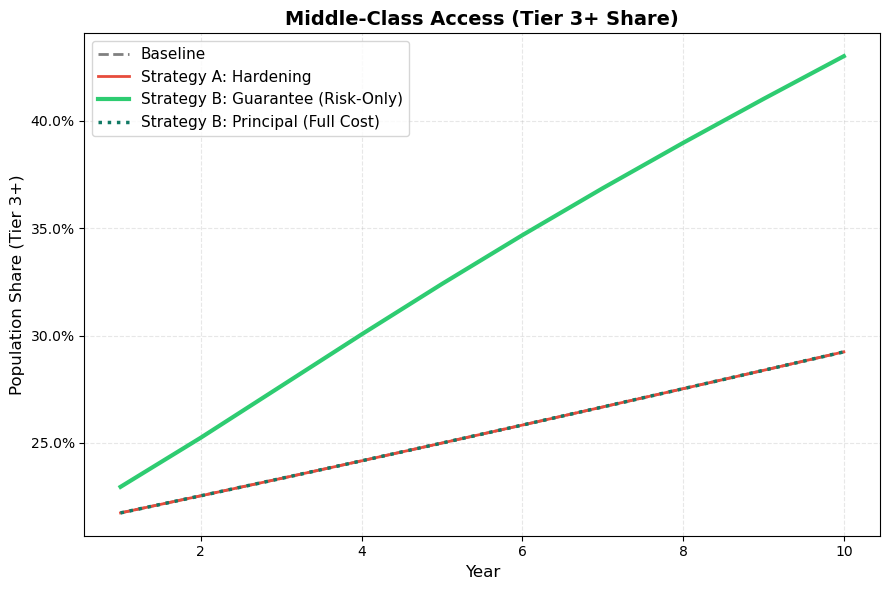


--- RESULTS SUMMARY (Year 10) ---
Revenue (Guarantee): 476.4B
Revenue (Principal): 296.7B
Tier 2+ (Guarantee): 62.4%
Tier 2+ (Principal): 62.4%
Tier 3+ (Guarantee): 43.0%
Tier 3+ (Principal): 29.2%


In [18]:
# --- Cell 14: 10-Year Projections (A vs B-Guarantee vs B-Principal) ---
import matplotlib.ticker as mtick

# === 1. CONFIGURATION ===
BUDGET_PER_YEAR = 20_000_000_000
ABS_LIFT = float(PROB_LIFT_FROM_DATA) if 'PROB_LIFT_FROM_DATA' in globals() else 0.15
BASE_DRIFT_RATE = 0.026

# Cost Constants
COST_A = CONFIG_FAIR['COST_GRID_PER_HH'] # 100,000

principal   = CONFIG_FAIR['COST_CAPITAL_SUBSIDY']
exp_loss    = principal * CONFIG_FAIR['DEFAULT_RATE']
admin_cost  = CONFIG_FAIR['ADMIN_PER_LOAN']

# Define the two costs for B
COST_B_GUARANTEE = max(exp_loss + admin_cost, 1e-9)  # ~29k
COST_B_PRINCIPAL = max(principal + admin_cost, 1e-9) # ~305k

print(f"--- COST PARAMETERS ---")
print(f"Strategy A (Hardening):   {COST_A:,.0f} RWF")
print(f"Strategy B (Guarantee):   {COST_B_GUARANTEE:,.0f} RWF (Risk Only)")
print(f"Strategy B (Principal):   {COST_B_PRINCIPAL:,.0f} RWF (Full Cost)")
print("-" * 30)

# --- 2. HELPER FUNCTIONS (Same Robust Logic) ---
def block_bill(kwh, blocks):
    bill, rem, prev = 0.0, float(kwh), 0
    for b in sorted(blocks, key=lambda z: z['limit']):
        span = b['limit'] - prev
        take = min(rem, span)
        bill += take * b['price']
        rem  -= take
        prev  = b['limit']
        if rem <= 0: break
    return bill

def current_revenue(state):
    mask = state['Conn_Grid'] == 1
    if not mask.any(): return 0.0
    base = state.loc[mask].copy()
    monthly_kwh = base['Tier'].map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0).astype(float)
    eff_kwh = monthly_kwh * base['m_R'].clip(0,1)
    bills = eff_kwh.apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    return float(np.sum(bills * base['HH_WT']))

def share_tier_x_plus(state, x=2):
    mask = state['Conn_Grid'] == 1
    wtot = float(state.loc[mask, 'HH_WT'].sum())
    if wtot <= 0: return 0.0
    return float(np.sum((state.loc[mask, 'Tier'] >= x).astype(float) * state.loc[mask, 'HH_WT']) / wtot)

def apply_natural_drift(state, rate=BASE_DRIFT_RATE):
    st = state.copy()
    mask = st['Conn_Grid'] == 1
    st['HH_Move'] = np.where(mask, st['HH_WT'] * rate, 0.0)
    st['HH_Stay'] = st['HH_WT'] - st['HH_Move']
    
    moved = st[mask].copy()
    moved['HH_WT'] = moved['HH_Move']
    moved['Tier'] = (moved['Tier'] + 1).clip(0, 5)
    stayed = st.copy()
    stayed['HH_WT'] = stayed['HH_Stay']
    out = pd.concat([stayed, moved], ignore_index=True)
    return out[out['HH_WT'] > 0].groupby(['hhid','Conn_Grid','Tier','m_R'], as_index=False)['HH_WT'].sum()

def with_roi_columns(state, cost_A, cost_B):
    st = state.copy()
    base_kwh = st['Tier'].map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)
    next_kwh = (st['Tier'] + 1).clip(0,5).map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)
    m0 = st['m_R'].astype(float).clip(0,1)
    
    # Bills
    bill0 = (base_kwh * m0).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    bill1 = (next_kwh * m0).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    
    # ROI A (Hardening)
    m1 = np.minimum(m0 * 1.2, 0.99)
    bill0_improved = (base_kwh * m1).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    st['ROI_A'] = np.where(st['Conn_Grid']==1, (bill0_improved - bill0) / max(cost_A,1e-9), 0.0)
    
    # ROI B (Financing)
    prob_adopt = ABS_LIFT * np.power(m0, 0.6)
    st['ROI_B'] = np.where((st['Conn_Grid']==1) & (st['Tier']<5), 
                           ((bill1 - bill0) * prob_adopt) / max(cost_B,1e-9), 0.0)
    return st

def apply_hardening_year(state, budget, cost_A):
    state = apply_natural_drift(state)
    st = with_roi_columns(state, cost_A, 999999) # Cost B irrelevant here
    
    mask_eligible = (st['Conn_Grid']==1) & (st['ROI_A'] > 0)
    candidates = st[mask_eligible].copy()
    others = st[~mask_eligible].copy()
    
    if candidates.empty: return state

    candidates = candidates.sort_values('ROI_A', ascending=False)
    treat_units = budget / cost_A
    candidates['cumsum_wt'] = candidates['HH_WT'].cumsum()
    candidates['take'] = np.minimum(candidates['HH_WT'], np.maximum(0, treat_units - (candidates['cumsum_wt'] - candidates['HH_WT'])))
            
    treated = candidates[candidates['take'] > 0].copy()
    treated['HH_WT'] = treated['take']
    treated['m_R'] = np.minimum(treated['m_R'] * 1.2, 0.99)
    
    candidates['HH_WT'] = np.maximum(candidates['HH_WT'] - candidates['take'], 0.0)
    untreated = candidates[candidates['HH_WT'] > 1e-9] 
    
    out = pd.concat([treated, untreated, others], ignore_index=True)
    return out.groupby(['hhid','Conn_Grid','Tier','m_R'], as_index=False)['HH_WT'].sum()

def apply_finance_year(state, budget, cost_B):
    state = apply_natural_drift(state)
    st = with_roi_columns(state, 999999, cost_B) # Cost A irrelevant here
    
    mask_eligible = (st['Conn_Grid']==1) & (st['ROI_B'] > 0)
    candidates = st[mask_eligible].copy()
    others = st[~mask_eligible].copy()
    
    if candidates.empty: return state

    candidates = candidates.sort_values('ROI_B', ascending=False)
    treat_units = budget / cost_B
    candidates['cumsum_wt'] = candidates['HH_WT'].cumsum()
    candidates['take'] = np.minimum(candidates['HH_WT'], np.maximum(0, treat_units - (candidates['cumsum_wt'] - candidates['HH_WT'])))

    treated_part = candidates[candidates['take'] > 0].copy()
    treated_part['HH_WT'] = treated_part['take']
    
    p = np.clip(ABS_LIFT * np.power(treated_part['m_R'].astype(float).clip(0,1), 0.6), 0.0, 1.0)
    
    upgraders = treated_part.copy()
    upgraders['HH_WT'] = treated_part['HH_WT'] * p
    upgraders['Tier'] = (upgraders['Tier'] + 1).clip(0,5)
    non_upgraders = treated_part.copy()
    non_upgraders['HH_WT'] = treated_part['HH_WT'] * (1 - p)
    
    candidates['HH_WT'] = np.maximum(candidates['HH_WT'] - candidates['take'], 0.0)
    untreated = candidates[candidates['HH_WT'] > 1e-9]

    out = pd.concat([upgraders, non_upgraders, untreated, others], ignore_index=True)
    return out.groupby(['hhid','Conn_Grid','Tier','m_R'], as_index=False)['HH_WT'].sum()

# --- 3. RUNNING ALL SCENARIOS ---
# Initial State
state0 = df_agents.rename(columns={'UsabilityIndex':'m_R','CapacityTier':'Tier'}).copy()
for c in ['Tier','m_R','HH_WT','Conn_Grid']: state0[c] = pd.to_numeric(state0[c], errors='coerce').fillna(0)

years = range(1, 11)

# DEFINE KEYS FOR FULL LEGEND NAMES
KEY_BASE   = 'Baseline'
KEY_STRAT_A = 'Strategy A: Hardening'
KEY_GUAR   = 'Strategy B: Guarantee (Risk-Only)'
KEY_PRINC  = 'Strategy B: Principal (Full Cost)'

results = {
    KEY_BASE:   {'rev': [], 'share2': [], 'share3': []},
    KEY_STRAT_A: {'rev': [], 'share2': [], 'share3': []},
    KEY_GUAR:   {'rev': [], 'share2': [], 'share3': []},
    KEY_PRINC:  {'rev': [], 'share2': [], 'share3': []}
}

# 1. Baseline
curr = state0.copy()
for t in years:
    curr = apply_natural_drift(curr)
    results[KEY_BASE]['rev'].append(current_revenue(curr))
    results[KEY_BASE]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_BASE]['share3'].append(share_tier_x_plus(curr, 3))

# 2. Strategy A (Hardening)
curr = state0.copy()
for t in years:
    curr = apply_hardening_year(curr, BUDGET_PER_YEAR, COST_A)
    results[KEY_STRAT_A]['rev'].append(current_revenue(curr))
    results[KEY_STRAT_A]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_STRAT_A]['share3'].append(share_tier_x_plus(curr, 3))

# 3. Strategy B (Guarantee)
curr = state0.copy()
for t in years:
    curr = apply_finance_year(curr, BUDGET_PER_YEAR, COST_B_GUARANTEE)
    results[KEY_GUAR]['rev'].append(current_revenue(curr))
    results[KEY_GUAR]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_GUAR]['share3'].append(share_tier_x_plus(curr, 3))

# 4. Strategy B (Principal)
curr = state0.copy()
for t in years:
    curr = apply_finance_year(curr, BUDGET_PER_YEAR, COST_B_PRINCIPAL)
    results[KEY_PRINC]['rev'].append(current_revenue(curr))
    results[KEY_PRINC]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_PRINC]['share3'].append(share_tier_x_plus(curr, 3))

print("Simulations Complete.")

# --- 4. PLOTTING FIGURES ---

# STYLE SETTINGS (Mapped to Full Names)
colors = {
    KEY_BASE:   'gray',
    KEY_STRAT_A: '#e74c3c',         # Red
    KEY_GUAR:   '#2ecc71',          # Bright Green
    KEY_PRINC:  '#117A65'           # Dark Green
}
styles = {
    KEY_BASE:   '--',
    KEY_STRAT_A: '-',
    KEY_GUAR:   '-',
    KEY_PRINC:  ':'
}
widths = {
    KEY_BASE:   2,
    KEY_STRAT_A: 2,
    KEY_GUAR:   3,
    KEY_PRINC:  2.5
}

def plot_scenario(metric_key, title, ylabel, filename, percent=False):
    plt.figure(figsize=(9, 6))
    
    # Iterate in specific order for legend consistency
    for name in [KEY_BASE, KEY_STRAT_A, KEY_GUAR, KEY_PRINC]:
        y_vals = np.array(results[name][metric_key])
        if metric_key == 'rev': y_vals /= 1e9 # Billions
        
        plt.plot(years, y_vals, 
                 linestyle=styles[name], 
                 color=colors[name], 
                 linewidth=widths[name], 
                 label=name)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Year", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=11, loc='best')
    
    if percent:
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# FIGURE 1: REVENUE
plot_scenario('rev', "Projected Utility Revenue by Strategy", "Annual Revenue (Billion RWF)", "revenue_impact.png")

# FIGURE 2: TIER 2+ ACCESS
plot_scenario('share2', "Modern Energy Access (Tier 2+ Share)", "Population Share (Tier 2+)", "tier2_access.png", percent=True)

# FIGURE 3: TIER 3+ ACCESS
plot_scenario('share3', "Middle-Class Access (Tier 3+ Share)", "Population Share (Tier 3+)", "tier3_access.png", percent=True)

print("\n--- RESULTS SUMMARY (Year 10) ---")
print(f"Revenue (Guarantee): {results[KEY_GUAR]['rev'][-1]/1e9:.1f}B")
print(f"Revenue (Principal): {results[KEY_PRINC]['rev'][-1]/1e9:.1f}B")
print(f"Tier 2+ (Guarantee): {results[KEY_GUAR]['share2'][-1]:.1%}")
print(f"Tier 2+ (Principal): {results[KEY_PRINC]['share2'][-1]:.1%}")
print(f"Tier 3+ (Guarantee): {results[KEY_GUAR]['share3'][-1]:.1%}")
print(f"Tier 3+ (Principal): {results[KEY_PRINC]['share3'][-1]:.1%}")

--- COST PARAMETERS (PER HOUSEHOLD) ---
Strategy A (Hardening):   100,000 RWF
Strategy B (Guarantee):   50,000 RWF (Leveraged/Risk-Only)
Strategy B (Principal):   305,000 RWF (Direct Lending/Full Cost)
Levrage Ratio (Prin/Guar): 6.1x
------------------------------
Simulations Complete.


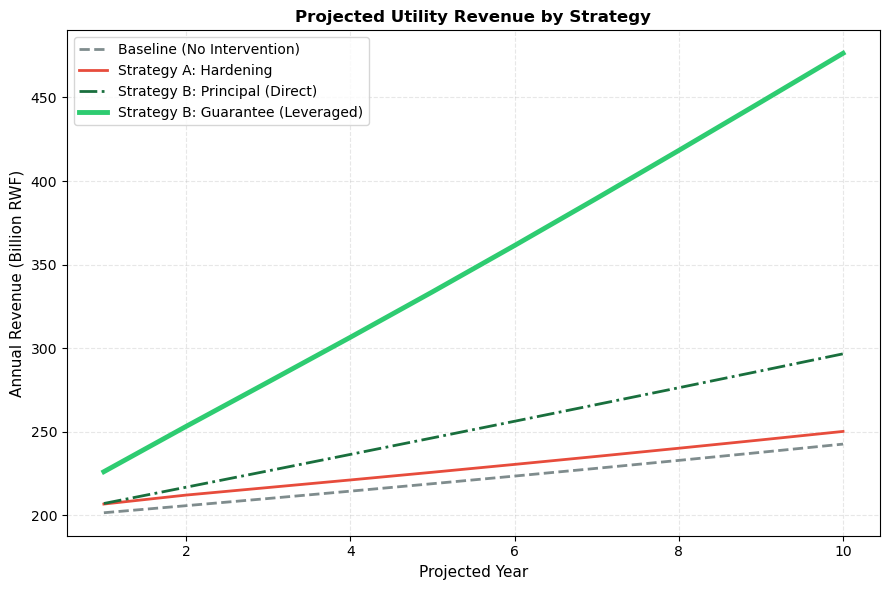

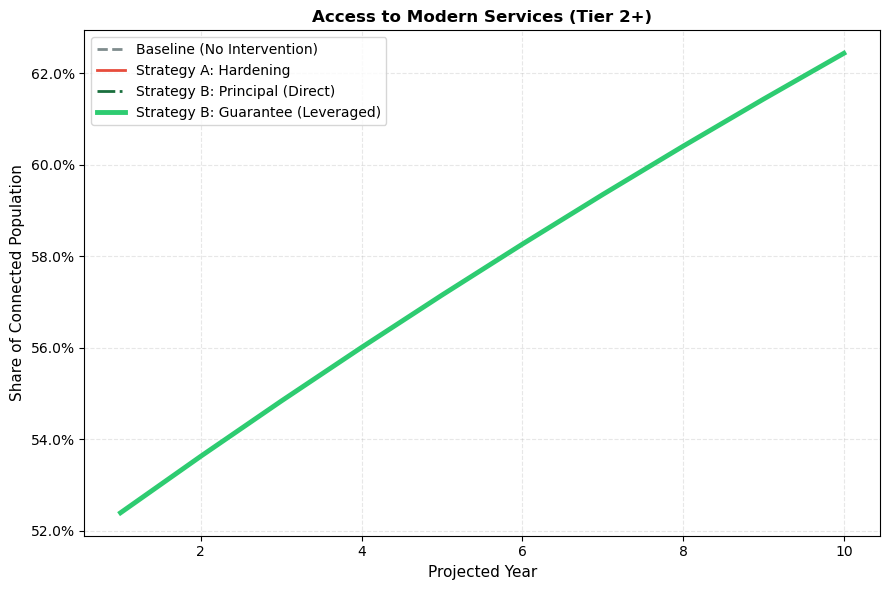

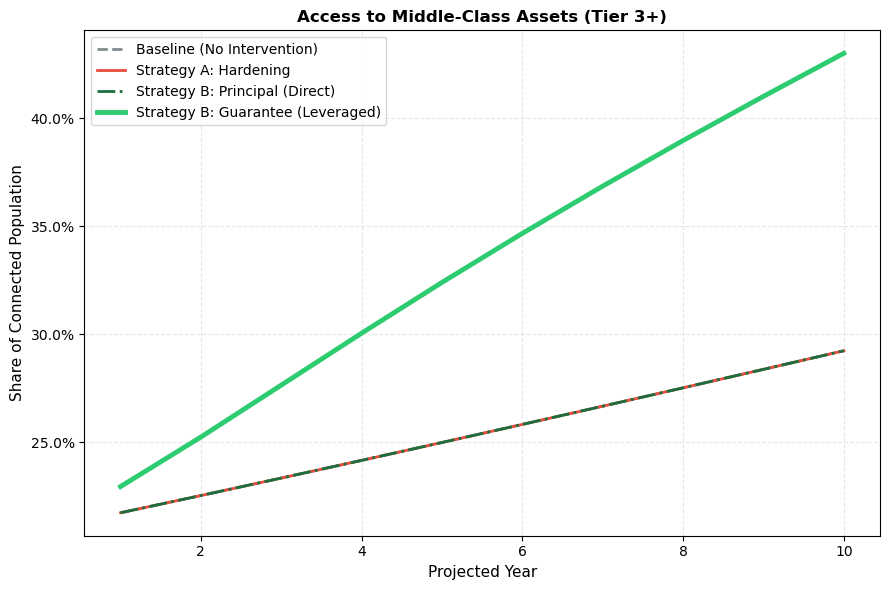


--- RESULTS SUMMARY (Year 10) ---
Revenue (Guarantee): 476.4B RWF
Revenue (Principal): 296.7B RWF
Revenue Multiplier:  1.61x
------------------------------
Tier 2+ (Guarantee): 62.4%
Tier 2+ (Principal): 62.4%
------------------------------
Tier 3+ (Guarantee): 43.0%
Tier 3+ (Principal): 29.2%


In [19]:
# Cell 14: 10-Year Projections (Leverage & Scalability Analysis)
import matplotlib.ticker as mtick

# === 1. CONFIGURATION ===
BUDGET_PER_YEAR = 20_000_000_000
ABS_LIFT = float(PROB_LIFT_FROM_DATA) if 'PROB_LIFT_FROM_DATA' in globals() else 0.15
BASE_DRIFT_RATE = 0.026

# Cost Constants
COST_A = CONFIG_FAIR['COST_GRID_PER_HH'] # 100,000

principal   = CONFIG_FAIR['COST_CAPITAL_SUBSIDY']
exp_loss    = principal * CONFIG_FAIR['DEFAULT_RATE']
admin_cost  = CONFIG_FAIR['ADMIN_PER_LOAN']

# Define the two costs for B
COST_B_GUARANTEE = max(exp_loss + admin_cost, 1e-9)  # ~29k (Risk + Admin)
COST_B_PRINCIPAL = max(principal + admin_cost, 1e-9) # ~305k (Full Capital + Admin)

print(f"--- COST PARAMETERS (PER HOUSEHOLD) ---")
print(f"Strategy A (Hardening):   {COST_A:,.0f} RWF")
print(f"Strategy B (Guarantee):   {COST_B_GUARANTEE:,.0f} RWF (Leveraged/Risk-Only)")
print(f"Strategy B (Principal):   {COST_B_PRINCIPAL:,.0f} RWF (Direct Lending/Full Cost)")
print(f"Levrage Ratio (Prin/Guar): {COST_B_PRINCIPAL/COST_B_GUARANTEE:.1f}x")
print("-" * 30)

# --- 2. HELPER FUNCTIONS ---
# (Logic remains identical to preserve simulation integrity)
def block_bill(kwh, blocks):
    bill, rem, prev = 0.0, float(kwh), 0
    for b in sorted(blocks, key=lambda z: z['limit']):
        span = b['limit'] - prev
        take = min(rem, span)
        bill += take * b['price']
        rem  -= take
        prev  = b['limit']
        if rem <= 0: break
    return bill

def current_revenue(state):
    mask = state['Conn_Grid'] == 1
    if not mask.any(): return 0.0
    base = state.loc[mask].copy()
    monthly_kwh = base['Tier'].map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0).astype(float)
    eff_kwh = monthly_kwh * base['m_R'].clip(0,1)
    bills = eff_kwh.apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    return float(np.sum(bills * base['HH_WT']))
    

def share_tier_x_plus(state, x=2):
    mask = state['Conn_Grid'] == 1
    wtot = float(state.loc[mask, 'HH_WT'].sum())
    if wtot <= 0: return 0.0
    return float(np.sum((state.loc[mask, 'Tier'] >= x).astype(float) * state.loc[mask, 'HH_WT']) / wtot)

def apply_natural_drift(state, rate=BASE_DRIFT_RATE):
    st = state.copy()
    mask = st['Conn_Grid'] == 1
    st['HH_Move'] = np.where(mask, st['HH_WT'] * rate, 0.0)
    st['HH_Stay'] = st['HH_WT'] - st['HH_Move']
    
    moved = st[mask].copy()
    moved['HH_WT'] = moved['HH_Move']
    moved['Tier'] = (moved['Tier'] + 1).clip(0, 5)
    stayed = st.copy()
    stayed['HH_WT'] = stayed['HH_Stay']
    out = pd.concat([stayed, moved], ignore_index=True)
    return out[out['HH_WT'] > 0].groupby(['hhid','Conn_Grid','Tier','m_R'], as_index=False)['HH_WT'].sum()

def with_roi_columns(state, cost_A, cost_B):
    st = state.copy()
    base_kwh = st['Tier'].map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)
    next_kwh = (st['Tier'] + 1).clip(0,5).map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)
    m0 = st['m_R'].astype(float).clip(0,1)
    
    # Bills
    bill0 = (base_kwh * m0).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    bill1 = (next_kwh * m0).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    
    # ROI A (Hardening)
    m1 = np.minimum(m0 * 1.2, 0.99)
    bill0_improved = (base_kwh * m1).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    st['ROI_A'] = np.where(st['Conn_Grid']==1, (bill0_improved - bill0) / max(cost_A,1e-9), 0.0)
    
    # ROI B (Financing)
    prob_adopt = ABS_LIFT * np.power(m0, 0.6)
    st['ROI_B'] = np.where((st['Conn_Grid']==1) & (st['Tier']<5), 
                           ((bill1 - bill0) * prob_adopt) / max(cost_B,1e-9), 0.0)
    return st

def apply_hardening_year(state, budget, cost_A):
    state = apply_natural_drift(state)
    st = with_roi_columns(state, cost_A, 999999) # Cost B irrelevant here
    
    mask_eligible = (st['Conn_Grid']==1) & (st['ROI_A'] > 0)
    candidates = st[mask_eligible].copy()
    others = st[~mask_eligible].copy()
    
    if candidates.empty: return state

    candidates = candidates.sort_values('ROI_A', ascending=False)
    treat_units = budget / cost_A
    candidates['cumsum_wt'] = candidates['HH_WT'].cumsum()
    candidates['take'] = np.minimum(candidates['HH_WT'], np.maximum(0, treat_units - (candidates['cumsum_wt'] - candidates['HH_WT'])))
            
    treated = candidates[candidates['take'] > 0].copy()
    treated['HH_WT'] = treated['take']
    treated['m_R'] = np.minimum(treated['m_R'] * 1.2, 0.99)
    
    candidates['HH_WT'] = np.maximum(candidates['HH_WT'] - candidates['take'], 0.0)
    untreated = candidates[candidates['HH_WT'] > 1e-9] 
    
    out = pd.concat([treated, untreated, others], ignore_index=True)
    return out.groupby(['hhid','Conn_Grid','Tier','m_R'], as_index=False)['HH_WT'].sum()

def apply_finance_year(state, budget, cost_B):
    state = apply_natural_drift(state)
    st = with_roi_columns(state, 999999, cost_B) # Cost A irrelevant here
    
    mask_eligible = (st['Conn_Grid']==1) & (st['ROI_B'] > 0)
    candidates = st[mask_eligible].copy()
    others = st[~mask_eligible].copy()
    
    if candidates.empty: return state

    candidates = candidates.sort_values('ROI_B', ascending=False)
    treat_units = budget / cost_B
    candidates['cumsum_wt'] = candidates['HH_WT'].cumsum()
    candidates['take'] = np.minimum(candidates['HH_WT'], np.maximum(0, treat_units - (candidates['cumsum_wt'] - candidates['HH_WT'])))

    treated_part = candidates[candidates['take'] > 0].copy()
    treated_part['HH_WT'] = treated_part['take']
    
    p = np.clip(ABS_LIFT * np.power(treated_part['m_R'].astype(float).clip(0,1), 0.6), 0.0, 1.0)
    
    upgraders = treated_part.copy()
    upgraders['HH_WT'] = treated_part['HH_WT'] * p
    upgraders['Tier'] = (upgraders['Tier'] + 1).clip(0,5)
    non_upgraders = treated_part.copy()
    non_upgraders['HH_WT'] = treated_part['HH_WT'] * (1 - p)
    
    candidates['HH_WT'] = np.maximum(candidates['HH_WT'] - candidates['take'], 0.0)
    untreated = candidates[candidates['HH_WT'] > 1e-9]

    out = pd.concat([upgraders, non_upgraders, untreated, others], ignore_index=True)
    return out.groupby(['hhid','Conn_Grid','Tier','m_R'], as_index=False)['HH_WT'].sum()

# --- 3. RUNNING ALL SCENARIOS ---
state0 = df_agents.rename(columns={'UsabilityIndex':'m_R','CapacityTier':'Tier'}).copy()
for c in ['Tier','m_R','HH_WT','Conn_Grid']: state0[c] = pd.to_numeric(state0[c], errors='coerce').fillna(0)

years = range(1, 11)

# Names for Legend
KEY_BASE    = 'Baseline (No Intervention)'
KEY_STRAT_A = 'Strategy A: Hardening'
KEY_GUAR    = 'Strategy B: Guarantee (Leveraged)'
KEY_PRINC   = 'Strategy B: Principal (Direct)'

results = {
    KEY_BASE:    {'rev': [], 'share2': [], 'share3': []},
    KEY_STRAT_A: {'rev': [], 'share2': [], 'share3': []},
    KEY_GUAR:    {'rev': [], 'share2': [], 'share3': []},
    KEY_PRINC:   {'rev': [], 'share2': [], 'share3': []}
}

# 1. Baseline
curr = state0.copy()
for t in years:
    curr = apply_natural_drift(curr)
    results[KEY_BASE]['rev'].append(current_revenue(curr))
    results[KEY_BASE]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_BASE]['share3'].append(share_tier_x_plus(curr, 3))

# 2. Strategy A
curr = state0.copy()
for t in years:
    curr = apply_hardening_year(curr, BUDGET_PER_YEAR, COST_A)
    results[KEY_STRAT_A]['rev'].append(current_revenue(curr))
    results[KEY_STRAT_A]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_STRAT_A]['share3'].append(share_tier_x_plus(curr, 3))

# 3. Strategy B (Guarantee)
curr = state0.copy()
for t in years:
    curr = apply_finance_year(curr, BUDGET_PER_YEAR, COST_B_GUARANTEE)
    results[KEY_GUAR]['rev'].append(current_revenue(curr))
    results[KEY_GUAR]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_GUAR]['share3'].append(share_tier_x_plus(curr, 3))

# 4. Strategy B (Principal)
curr = state0.copy()
for t in years:
    curr = apply_finance_year(curr, BUDGET_PER_YEAR, COST_B_PRINCIPAL)
    results[KEY_PRINC]['rev'].append(current_revenue(curr))
    results[KEY_PRINC]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_PRINC]['share3'].append(share_tier_x_plus(curr, 3))

print("Simulations Complete.")

# --- 4. PLOTTING ---

# Styles
colors = {
    KEY_BASE:    '#7f8c8d',     # Gray
    KEY_STRAT_A: '#e74c3c',     # Red
    KEY_GUAR:    '#2ecc71',     # Bright Green (Optimal)
    KEY_PRINC:   '#196f3d'      # Dark Green (Sub-optimal)
}
styles = {
    KEY_BASE:    '--',
    KEY_STRAT_A: '-',
    KEY_GUAR:    '-',
    KEY_PRINC:   '-.'
}
widths = {
    KEY_BASE:    2,
    KEY_STRAT_A: 2,
    KEY_GUAR:    3.5,           # Emphasize the winner
    KEY_PRINC:   2
}

def plot_scenario(metric_key, title, ylabel, filename, percent=False):
    plt.figure(figsize=(9, 6))
    
    # Order: Base, A, Principal, Guarantee (so Guarantee is on top)
    plot_order = [KEY_BASE, KEY_STRAT_A, KEY_PRINC, KEY_GUAR]
    
    for name in plot_order:
        y_vals = np.array(results[name][metric_key])
        if metric_key == 'rev': y_vals /= 1e9 # Billions
        
        plt.plot(years, y_vals, 
                 linestyle=styles[name], 
                 color=colors[name], 
                 linewidth=widths[name], 
                 label=name)

    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel("Projected Year", fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=10, loc='best', frameon=True)
    
    if percent:
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# Generate Plots
plot_scenario('rev', "Projected Utility Revenue by Strategy", "Annual Revenue (Billion RWF)", "fig_proj_revenue.png")
plot_scenario('share2', "Access to Modern Services (Tier 2+)", "Share of Connected Population", "fig_proj_tier2.png", percent=True)
plot_scenario('share3', "Access to Middle-Class Assets (Tier 3+)", "Share of Connected Population", "fig_proj_tier3.png", percent=True)

# --- 5. FINAL RESULTS SUMMARY ---
print("\n--- RESULTS SUMMARY (Year 10) ---")
print(f"Revenue (Guarantee): {results[KEY_GUAR]['rev'][-1]/1e9:.1f}B RWF")
print(f"Revenue (Principal): {results[KEY_PRINC]['rev'][-1]/1e9:.1f}B RWF")
print(f"Revenue Multiplier:  {results[KEY_GUAR]['rev'][-1] / results[KEY_PRINC]['rev'][-1]:.2f}x")
print("-" * 30)
print(f"Tier 2+ (Guarantee): {results[KEY_GUAR]['share2'][-1]:.1%}")
print(f"Tier 2+ (Principal): {results[KEY_PRINC]['share2'][-1]:.1%}")
print("-" * 30)
print(f"Tier 3+ (Guarantee): {results[KEY_GUAR]['share3'][-1]:.1%}")
print(f"Tier 3+ (Principal): {results[KEY_PRINC]['share3'][-1]:.1%}")

In [20]:
# === Print Agent Stats table values ===
import numpy as np
import pandas as pd
import os

def _wavg(series, weights):
    s = pd.to_numeric(series, errors='coerce')
    w = pd.to_numeric(weights, errors='coerce')
    m = s.notna() & np.isfinite(s) & np.isfinite(w) & (w > 0)
    if m.sum() == 0:
        return np.nan
    return float(np.average(s[m], weights=w[m]))

def _fmt_pct_plain(x, digits=1):
    if x is None or not np.isfinite(x):
        return "--"
    return f"{x*100:.{digits}f}%"

def _fmt_num_plain(x, digits=2):
    if x is None or not np.isfinite(x):
        return "--"
    return f"{x:.{digits}f}"

def _fmt_int_plain(x):
    try:
        v = int(round(float(x)))
        return f"{v:,d}"
    except Exception:
        return "--"

# ---------- Gather sources ----------
if 'df' not in globals():
    raise RuntimeError("Expected dataframe 'df' from earlier cells.")
if 'df_agents' not in globals():
    raise RuntimeError("Expected dataframe 'df_agents' from earlier cells.")

# Base (full) survey for urban/rural & weights
base = df[['hhid','HH_WT','Is_Urban']].copy() if 'Is_Urban' in df.columns else df[['hhid','HH_WT']].copy()
if 'Is_Urban' not in base.columns:
    base['Is_Urban'] = np.nan

# Agents view for connection, reliability, tiers, Section-H answers
ag = df_agents.copy()

# Normalize aliases
if 'm_R' not in ag.columns and 'UsabilityIndex' in ag.columns:
    ag['m_R'] = pd.to_numeric(ag['UsabilityIndex'], errors='coerce')
if 'Tier' not in ag.columns and 'CapacityTier' in ag.columns:
    ag['Tier'] = pd.to_numeric(ag['CapacityTier'], errors='coerce').astype('Int64')

# Merge Urban/Rural via hhid (safe even if missing)
ag = ag.merge(base[['hhid','Is_Urban','HH_WT']], on='hhid', how='left', suffixes=('','_base'))

# Prefer agent HH_WT if present; else take base
if 'HH_WT_x' in ag.columns and 'HH_WT_y' in ag.columns:
    ag['HH_WT'] = ag['HH_WT_x'].fillna(ag['HH_WT_y'])
    ag.drop(columns=['HH_WT_x','HH_WT_y'], inplace=True)

# Coerce key columns
for c in ['Conn_Grid','m_R','Tier','HH_WT','Is_Urban']:
    if c in ag.columns:
        ag[c] = pd.to_numeric(ag[c], errors='coerce')

ag['Conn_Grid'] = (ag.get('Conn_Grid', 0) == 1).astype(int)
ag['Is_Urban'] = (ag.get('Is_Urban', 0) == 1).astype(int)
ag['HH_WT'] = ag['HH_WT'].fillna(0)

# Section H (if present in agents) OR from df_h_raw
if all(c in ag.columns for c in ['H03','H04','H05','H06']):
    H_local = ag[['hhid','H03','H04','H05','H06']].copy()
    H_local['H_WT'] = ag['HH_WT'].values
else:
    H_local = None

if H_local is None and 'df_h_raw' in globals() and df_h_raw is not None:
    H_local = df_h_raw[['hhid','H03','H04','H05','H06','HH_WT']].copy()
    H_local = H_local.rename(columns={'HH_WT':'H_WT'})

# ---------- Compute metrics ----------
Nraw_val = len(df)  # unweighted households in analytic file
connected = ag[ag['Conn_Grid'] == 1].copy()

Nconn_val = len(connected)
Popwt_val = connected['HH_WT'].sum()

mR_mean_val  = _wavg(connected['m_R'], connected['HH_WT'])
mR_urban_val = _wavg(connected.loc[connected['Is_Urban']==1, 'm_R'],
                     connected.loc[connected['Is_Urban']==1, 'HH_WT'])
mR_rural_val = _wavg(connected.loc[connected['Is_Urban']==0, 'm_R'],
                     connected.loc[connected['Is_Urban']==0, 'HH_WT'])

def tier_share(t):
    if Popwt_val <= 0:
        return np.nan
    w = connected.loc[connected['Tier'] == t, 'HH_WT'].sum()
    return w / Popwt_val

pT1 = tier_share(1); pT2 = tier_share(2); pT3 = tier_share(3); pT4 = tier_share(4); pT5 = tier_share(5)
pTge2 = sum(x for x in [pT2, pT3, pT4, pT5] if x is not None and np.isfinite(x))

# Credit metrics (use Section-H weights if available)
pCash = np.nan; pCreditAny = np.nan; liftAbs = np.nan
if H_local is not None and not H_local.empty:
    H = H_local.copy()
    for c in ['H03','H04','H05','H06','H_WT']:
        H[c] = pd.to_numeric(H[c], errors='coerce')
    H = H[np.isfinite(H['H_WT']) & (H['H_WT'] > 0)]
    H['Accept_Cash']       = (H['H03'] == 1).astype(int)
    H['Accept_Credit_Any'] = ((H['H03']==1)|(H['H04']==1)|(H['H05']==1)|(H['H06']==1)).astype(int)

    pCash      = _wavg(H['Accept_Cash'], H['H_WT'])
    pCreditAny = _wavg(H['Accept_Credit_Any'], H['H_WT'])
    liftAbs    = (pCreditAny - pCash) if (np.isfinite(pCash) and np.isfinite(pCreditAny)) else np.nan

# ---------- Print results ----------
print("\n=== Agent Stats (printed values) ===")
print(f"Nraw (unweighted households in df): { _fmt_int_plain(Nraw_val) }")
print(f"Nconn (connected households):       { _fmt_int_plain(Nconn_val) }")
print(f"Popwt (weighted connected pop):     { _fmt_int_plain(Popwt_val) }")
print("")
print(f"m_R mean (weighted):                { _fmt_num_plain(mR_mean_val, 2) }")
print(f"m_R urban (weighted):               { _fmt_num_plain(mR_urban_val, 2) }")
print(f"m_R rural (weighted):               { _fmt_num_plain(mR_rural_val, 2) }")
print("")
print("Tier shares among connected (weighted):")
print(f"  Tier 1:                           { _fmt_pct_plain(pT1, 1) }")
print(f"  Tier 2:                           { _fmt_pct_plain(pT2, 1) }")
print(f"  Tier 3:                           { _fmt_pct_plain(pT3, 1) }")
print(f"  Tier 4:                           { _fmt_pct_plain(pT4, 1) }")
print(f"  Tier 5:                           { _fmt_pct_plain(pT5, 1) }")
print(f"  Tier >=2:                         { _fmt_pct_plain(pTge2, 1) }")
print("")
print("Payment acceptance (weighted; Section H if available):")
print(f"  Accept cash:                      { _fmt_pct_plain(pCash, 1) }")
print(f"  Accept any credit:                { _fmt_pct_plain(pCreditAny, 1) }")
print(f"  Lift (credit - cash), abs pts:    { _fmt_pct_plain(liftAbs, 1) }")



=== Agent Stats (printed values) ===
Nraw (unweighted households in df): 5,706
Nconn (connected households):       2,661
Popwt (weighted connected pop):     1,520,388

m_R mean (weighted):                0.96
m_R urban (weighted):               0.98
m_R rural (weighted):               0.96

Tier shares among connected (weighted):
  Tier 1:                           48.9%
  Tier 2:                           30.2%
  Tier 3:                           0.7%
  Tier 4:                           18.7%
  Tier 5:                           1.6%
  Tier >=2:                         51.1%

Payment acceptance (weighted; Section H if available):
  Accept cash:                      30.6%
  Accept any credit:                48.9%
  Lift (credit - cash), abs pts:    18.3%


--- STRUCTURAL SENSITIVITY ANALYSIS (Baseline Share: 74.2%) ---
Cost Structure Risk: 66.1%
Behavioral Risk: 73.4%
Technical Risk: 73.4%
Credit Risk: 71.9%
Adoption Risk: 57.1%
Infrastructure Cost Risk: 74.2%


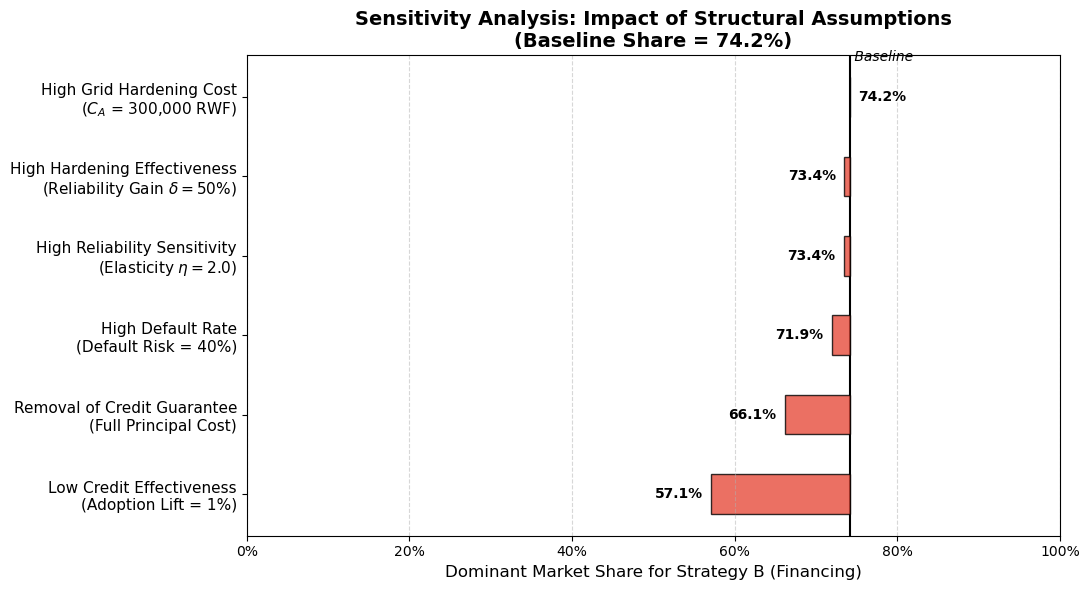

In [21]:
# Cell 15: Sensitivity Analysis - Tornado Diagram
# 1. Update the Solver to be Dynamic
def calculate_stackelberg_dynamic(agent_df, config, absolute_lift=0.183, 
                                  eta=0.6, delta=0.2):
    df = agent_df.copy()

    # Aliases
    if 'Tier' not in df.columns: df['Tier'] = df['CapacityTier'].astype(int)
    if 'm_R' not in df.columns:  df['m_R']  = df['UsabilityIndex'].astype(float)
    df['Accept_Cash'] = (pd.to_numeric(df['H03'], errors='coerce') == 1).astype(int)

    # 1. BASELINE REVENUE
    base_kwh = df['Tier'].map(config['TIER_KWH_MONTHLY']).fillna(0)
    u0 = df['m_R'].replace(0, 0.01)
    
    # 2. STRATEGY A (Hardening) - Dynamic Delta
    u1 = np.minimum(u0 * (1 + delta), 0.99)
    base_rev = (base_kwh * u0).apply(lambda k: annual_bill_from_kwh(k, config))
    strat_A_rev = (base_kwh * u1).apply(lambda k: annual_bill_from_kwh(k, config))
    
    gain_A = strat_A_rev - base_rev
    cost_A = config['COST_GRID_PER_HH']
    df['ROI_A'] = np.where(df['Conn_Grid'] == 1, gain_A / cost_A, 0.0)

    # 3. STRATEGY B (Financing) - Dynamic Eta
    next_kwh = (df['Tier'] + 1).clip(0, 5).map(config['TIER_KWH_MONTHLY'])
    next_rev = (next_kwh * u0).apply(lambda k: annual_bill_from_kwh(k, config))
    
    # Dynamic Risk Aversion
    prob_adopt = absolute_lift * np.power(u0, eta)
    rev_gain_B = (next_rev - base_rev) * prob_adopt
    
    # Cost
    risk_cost = config['COST_CAPITAL_SUBSIDY'] * config['DEFAULT_RATE']
    cost_B = max(risk_cost + config['ADMIN_PER_LOAN'], 1e-9)
    
    elig_B = (df['Tier'] < 5) & ((df['Accept_Cash'] == 0) | (df['H04'] == 1) | (df['H05'] == 1) | (df['H06'] == 1))
    rev_gain_B[~elig_B] = 0.0
    
    df['ROI_B'] = np.where(df['Conn_Grid'] == 1, rev_gain_B / cost_B, 0.0)

    # 4. Winner
    EPS = 1e-9
    df['Winner'] = 'None'
    mask_A = (df['ROI_A'] > df['ROI_B'] + EPS) & (df['ROI_A'] > EPS)
    mask_B = (df['ROI_B'] > df['ROI_A'] + EPS) & (df['ROI_B'] > EPS)
    df.loc[mask_A, 'Winner'] = 'Hardening'
    df.loc[mask_B, 'Winner'] = 'Financing'
    
    return df

# 2. Define Sensitivity Scenarios (NEW SCENARIO ADDED HERE)
stress_scenarios = [
    ("Removal of Credit Guarantee\n(Full Principal Cost)", "PRINCIPAL_MODE", True, "Cost Structure Risk"),
    ("High Reliability Sensitivity\n(Elasticity $\eta = 2.0$)", "ETA", 2.0, "Behavioral Risk"),
    ("High Hardening Effectiveness\n(Reliability Gain $\delta = 50\%$)", "DELTA", 0.5, "Technical Risk"),
    ("High Default Rate\n(Default Risk = 40%)", "DEFAULT", 0.40, "Credit Risk"),
    ("Low Credit Effectiveness\n(Adoption Lift = 1%)", "LIFT", 0.01, "Adoption Risk"),
    ("High Grid Hardening Cost\n($C_A$ = 300,000 RWF)", "COST_A", 300000, "Infrastructure Cost Risk")
]

# 3. Run and Aggregate
base_df = calculate_stackelberg_dynamic(df_agents, CONFIG_FAIR, absolute_lift=ABSOLUTE_LIFT, eta=0.6, delta=0.2)
base_conn = base_df[base_df['Conn_Grid']==1]
base_share = np.average((base_conn['Winner']=='Financing').astype(float), weights=base_conn['HH_WT'])

results = []
print(f"--- STRUCTURAL SENSITIVITY ANALYSIS (Baseline Share: {base_share:.1%}) ---")

for label, param, val, desc in stress_scenarios:
    # Reset Defaults
    cfg = CONFIG_FAIR.copy()
    lift = ABSOLUTE_LIFT
    eta = 0.6
    delta = 0.2
    
    # Apply Stress (NEW ELIF STATEMENT ADDED HERE)
    if param == "PRINCIPAL_MODE":
        full_cost = cfg['COST_CAPITAL_SUBSIDY'] + cfg['ADMIN_PER_LOAN']
        cfg['ADMIN_PER_LOAN'] = full_cost - (cfg['COST_CAPITAL_SUBSIDY'] * cfg['DEFAULT_RATE'])
    elif param == "ETA": eta = val
    elif param == "DELTA": delta = val
    elif param == "DEFAULT": cfg['DEFAULT_RATE'] = val
    elif param == "LIFT": lift = val
    elif param == "COST_A": cfg['COST_GRID_PER_HH'] = val
        
    # Solve
    res_df = calculate_stackelberg_dynamic(df_agents, cfg, absolute_lift=lift, eta=eta, delta=delta)
    
    # Calc Share
    conn = res_df[res_df['Conn_Grid']==1]
    share = np.average((conn['Winner']=='Financing').astype(float), weights=conn['HH_WT']) if len(conn) > 0 else 0.0
        
    delta_share = share - base_share
    results.append({'Label': label, 'Share': share, 'Delta': delta_share, 'Desc': desc})
    print(f"{desc}: {share:.1%}")

# 4. Plot Tornado
res_df = pd.DataFrame(results).sort_values('Delta', ascending=True)

plt.figure(figsize=(11, 6))
plt.axvline(base_share, color='black', linestyle='-', linewidth=1.5, zorder=0)

y_pos = np.arange(len(res_df))
for i, row in enumerate(res_df.itertuples()):
    color = '#e74c3c' if row.Delta < 0 else '#2ecc71'
    plt.barh(i, row.Delta, left=base_share, height=0.5, color=color, edgecolor='black', alpha=0.8)
    
    txt = f"{row.Share:.1%}"
    ha = 'right' if row.Delta < 0 else 'left'
    offset = -0.01 if row.Delta < 0 else 0.01
    plt.text(base_share + row.Delta + offset, i, txt, va='center', ha=ha, fontweight='bold', fontsize=10)

plt.yticks(y_pos, res_df['Label'], fontsize=11)
plt.xlabel("Dominant Market Share for Strategy B (Financing)", fontsize=12)
plt.title(f"Sensitivity Analysis: Impact of Structural Assumptions\n(Baseline Share = {base_share:.1%})", fontsize=14, fontweight='bold')
plt.xlim(0, 1.0)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.text(base_share, len(res_df)-0.5, " Baseline", va='center', ha='left', fontsize=10, style='italic', color='black')

plt.tight_layout()
plt.savefig("fig_robustness_tornado.png", dpi=300)
plt.show()

--- STRUCTURAL SENSITIVITY ANALYSIS (Baseline Share: 74.2%) ---
Default Rate | Low: 74.2% | High: 73.0%
Grid Hardening Cost | Low: 74.2% | High: 74.2%
Removal of Credit Guarantee (Full Principal Cost): 66.1%
Reliability Sensitivity ($\eta = 2.0$): 73.4%
Hardening Effectiveness ($\delta = 50\%$): 73.4%
Credit Effectiveness (Adoption Lift = 1%): 57.1%


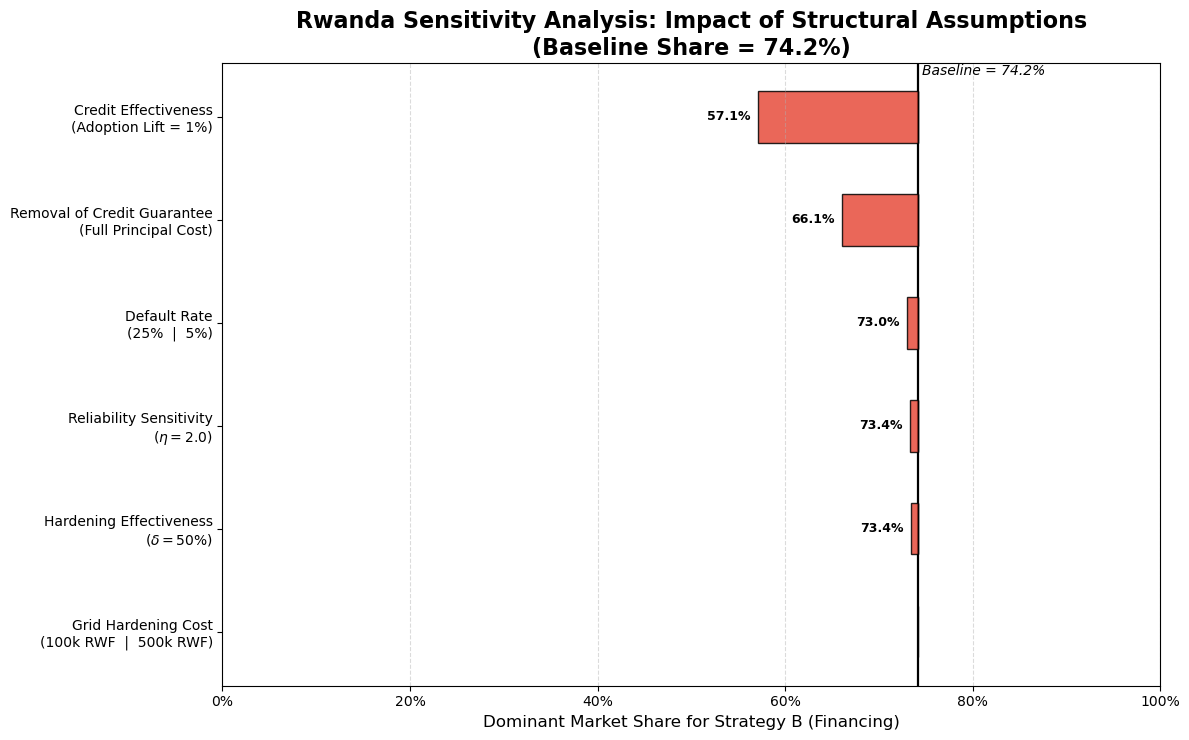

In [22]:
# Cell 15: Sensitivity Analysis - True Tornado Style (Updated)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Solver
def calculate_stackelberg_dynamic(agent_df, config, absolute_lift=0.183, eta=0.6, delta=0.2):
    df = agent_df.copy()

    # Aliases
    if 'Tier' not in df.columns:
        df['Tier'] = df['CapacityTier'].astype(int)
    if 'm_R' not in df.columns:
        df['m_R'] = df['UsabilityIndex'].astype(float)
    df['Accept_Cash'] = (pd.to_numeric(df['H03'], errors='coerce') == 1).astype(int)

    # 1. BASELINE REVENUE
    base_kwh = df['Tier'].map(config['TIER_KWH_MONTHLY']).fillna(0)
    u0 = df['m_R'].replace(0, 0.01)

    # 2. STRATEGY A (Hardening)
    u1 = np.minimum(u0 * (1 + delta), 0.99)
    base_rev = (base_kwh * u0).apply(lambda k: annual_bill_from_kwh(k, config))
    strat_A_rev = (base_kwh * u1).apply(lambda k: annual_bill_from_kwh(k, config))

    gain_A = strat_A_rev - base_rev
    cost_A = config['COST_GRID_PER_HH']
    df['ROI_A'] = np.where(df['Conn_Grid'] == 1, gain_A / cost_A, 0.0)

    # 3. STRATEGY B (Financing)
    next_kwh = (df['Tier'] + 1).clip(0, 5).map(config['TIER_KWH_MONTHLY'])
    next_rev = (next_kwh * u0).apply(lambda k: annual_bill_from_kwh(k, config))

    prob_adopt = absolute_lift * np.power(u0, eta)
    rev_gain_B = (next_rev - base_rev) * prob_adopt

    risk_cost = config['COST_CAPITAL_SUBSIDY'] * config['DEFAULT_RATE']
    cost_B = max(risk_cost + config['ADMIN_PER_LOAN'], 1e-9)

    elig_B = (
        (df['Tier'] < 5) &
        ((df['Accept_Cash'] == 0) | (df['H04'] == 1) | (df['H05'] == 1) | (df['H06'] == 1))
    )
    rev_gain_B[~elig_B] = 0.0

    df['ROI_B'] = np.where(df['Conn_Grid'] == 1, rev_gain_B / cost_B, 0.0)

    # 4. Winner
    EPS = 1e-9
    df['Winner'] = 'None'
    mask_A = (df['ROI_A'] > df['ROI_B'] + EPS) & (df['ROI_A'] > EPS)
    mask_B = (df['ROI_B'] > df['ROI_A'] + EPS) & (df['ROI_B'] > EPS)
    df.loc[mask_A, 'Winner'] = 'Hardening'
    df.loc[mask_B, 'Winner'] = 'Financing'

    return df


# 2. Helper to evaluate one scenario
def get_financing_share(agent_df, cfg, lift, eta, delta):
    res_df = calculate_stackelberg_dynamic(
        agent_df, cfg, absolute_lift=lift, eta=eta, delta=delta
    )
    conn = res_df[res_df['Conn_Grid'] == 1]
    if len(conn) == 0:
        return 0.0
    return np.average((conn['Winner'] == 'Financing').astype(float), weights=conn['HH_WT'])


# 3. Baseline
base_cfg = CONFIG_FAIR.copy()
base_lift = ABSOLUTE_LIFT
base_eta = 0.6
base_delta = 0.2

base_share = get_financing_share(df_agents, base_cfg, base_lift, base_eta, base_delta)
print(f"--- STRUCTURAL SENSITIVITY ANALYSIS (Baseline Share: {base_share:.1%}) ---")


# 4. Define bounded and one-sided scenarios
bounded_scenarios = [
    {
        "Label": "Default Rate",
        "Low": ("5%", {"DEFAULT_RATE": 0.05}),
        "High": ("25%", {"DEFAULT_RATE": 0.25})
    },
    {
        "Label": "Grid Hardening Cost",
        "Low": ("100k RWF", {"COST_GRID_PER_HH": 100000}),
        "High": ("500k RWF", {"COST_GRID_PER_HH": 500000})
    },
]

one_sided_scenarios = [
    ("Removal of Credit Guarantee", "Full Principal Cost", "PRINCIPAL_MODE", True),
    ("Reliability Sensitivity", r"$\eta = 2.0$", "ETA", 2.0),
    ("Hardening Effectiveness", r"$\delta = 50\%$", "DELTA", 0.5),
    ("Credit Effectiveness", "Adoption Lift = 1%", "LIFT", 0.01),
]


# 5. Run scenarios
rows = []

# Bounded scenarios (same line)
for scen in bounded_scenarios:
    label = scen["Label"]

    # Low bound
    cfg_low = CONFIG_FAIR.copy()
    lift_low = ABSOLUTE_LIFT
    eta_low = 0.6
    delta_low = 0.2
    for k, v in scen["Low"][1].items():
        cfg_low[k] = v
    low_share = get_financing_share(df_agents, cfg_low, lift_low, eta_low, delta_low)

    # High bound
    cfg_high = CONFIG_FAIR.copy()
    lift_high = ABSOLUTE_LIFT
    eta_high = 0.6
    delta_high = 0.2
    for k, v in scen["High"][1].items():
        cfg_high[k] = v
    high_share = get_financing_share(df_agents, cfg_high, lift_high, eta_high, delta_high)

    rows.append({
        "Label": label,
        "LowText": scen["Low"][0],
        "HighText": scen["High"][0],
        "LowShare": low_share,
        "HighShare": high_share,
        "Type": "bounded"
    })

    print(f"{label} | Low: {low_share:.1%} | High: {high_share:.1%}")

# One-sided scenarios
for main_label, sub_label, param, val in one_sided_scenarios:
    cfg = CONFIG_FAIR.copy()
    lift = ABSOLUTE_LIFT
    eta = 0.6
    delta = 0.2

    if param == "PRINCIPAL_MODE":
        full_cost = cfg['COST_CAPITAL_SUBSIDY'] + cfg['ADMIN_PER_LOAN']
        cfg['ADMIN_PER_LOAN'] = full_cost - (cfg['COST_CAPITAL_SUBSIDY'] * cfg['DEFAULT_RATE'])
    elif param == "ETA":
        eta = val
    elif param == "DELTA":
        delta = val
    elif param == "LIFT":
        lift = val

    share = get_financing_share(df_agents, cfg, lift, eta, delta)

    rows.append({
        "Label": main_label,
        "LowText": "",
        "HighText": sub_label,
        "LowShare": base_share,
        "HighShare": share,
        "Type": "one_sided"
    })

    print(f"{main_label} ({sub_label}): {share:.1%}")

tornado_df = pd.DataFrame(rows)

# Sort by spread so it looks like a tornado
tornado_df["Spread"] = (
    tornado_df[["LowShare", "HighShare"]].max(axis=1) -
    tornado_df[["LowShare", "HighShare"]].min(axis=1)
)
tornado_df = tornado_df.sort_values("Spread", ascending=True).reset_index(drop=True)


# 6. Plot tornado
plt.figure(figsize=(12, 7.5))
plt.axvline(base_share, color='black', linestyle='-', linewidth=1.6, zorder=0)

label_threshold = 0.003  # suppress labels for tiny changes

for i, row in enumerate(tornado_df.itertuples()):
    y = i
    left_share = min(row.LowShare, row.HighShare)
    right_share = max(row.LowShare, row.HighShare)

    # Case 1: entire range below baseline -> all red
    if right_share < base_share:
        plt.barh(
            y,
            right_share - left_share,
            left=left_share,
            height=0.50,
            color='#e74c3c',
            edgecolor='black',
            alpha=0.85
        )
        if (right_share - left_share) > label_threshold:
            plt.text(left_share - 0.008, y, f"{left_share:.1%}",
                     va='center', ha='right', fontsize=9, fontweight='bold')
            plt.text(right_share + 0.008, y, f"{right_share:.1%}",
                     va='center', ha='left', fontsize=9, fontweight='bold')

    # Case 2: entire range above or equal to baseline -> all green
    elif left_share >= base_share:
        plt.barh(
            y,
            right_share - left_share,
            left=left_share,
            height=0.50,
            color='#2ecc71',
            edgecolor='black',
            alpha=0.85
        )
        if (right_share - left_share) > label_threshold:
            plt.text(left_share - 0.008, y, f"{left_share:.1%}",
                     va='center', ha='right', fontsize=9, fontweight='bold')
            plt.text(right_share + 0.008, y, f"{right_share:.1%}",
                     va='center', ha='left', fontsize=9, fontweight='bold')

    # Case 3: range spans baseline -> red on left, green on right
    else:
        # left/red portion
        plt.barh(
            y,
            base_share - left_share,
            left=left_share,
            height=0.50,
            color='#e74c3c',
            edgecolor='black',
            alpha=0.85
        )
        if (base_share - left_share) > label_threshold:
            plt.text(left_share - 0.008, y, f"{left_share:.1%}",
                     va='center', ha='right', fontsize=9, fontweight='bold')

        # right/green portion
        plt.barh(
            y,
            right_share - base_share,
            left=base_share,
            height=0.50,
            color='#2ecc71',
            edgecolor='black',
            alpha=0.85
        )
        if (right_share - base_share) > label_threshold:
            plt.text(right_share + 0.008, y, f"{right_share:.1%}",
                     va='center', ha='left', fontsize=9, fontweight='bold')

# labels
yticklabels = []
for row in tornado_df.itertuples():
    if row.Type == "bounded":
        # Dynamically match labels to visual direction
        if row.LowShare <= row.HighShare:
            left_txt, right_txt = row.LowText, row.HighText
        else:
            left_txt, right_txt = row.HighText, row.LowText

        yticklabels.append(f"{row.Label}\n({left_txt}  |  {right_txt})")
    else:
        yticklabels.append(f"{row.Label}\n({row.HighText})")

plt.yticks(np.arange(len(tornado_df)), yticklabels, fontsize=10)
plt.xlabel("Dominant Market Share for Strategy B (Financing)", fontsize=12)
plt.title(
    f"Rwanda Sensitivity Analysis: Impact of Structural Assumptions\n(Baseline Share = {base_share:.1%})",
    fontsize=16, fontweight='bold'
)
plt.xlim(0, 1.0)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='x', linestyle='--', alpha=0.45)

# show baseline only once
plt.text(
    base_share + 0.004, len(tornado_df) - 0.55,
    f"Baseline = {base_share:.1%}",
    va='center', ha='left', fontsize=10, style='italic', color='black'
)

plt.tight_layout()
plt.savefig("fig_robustness_tornado.png", dpi=300)
plt.show()

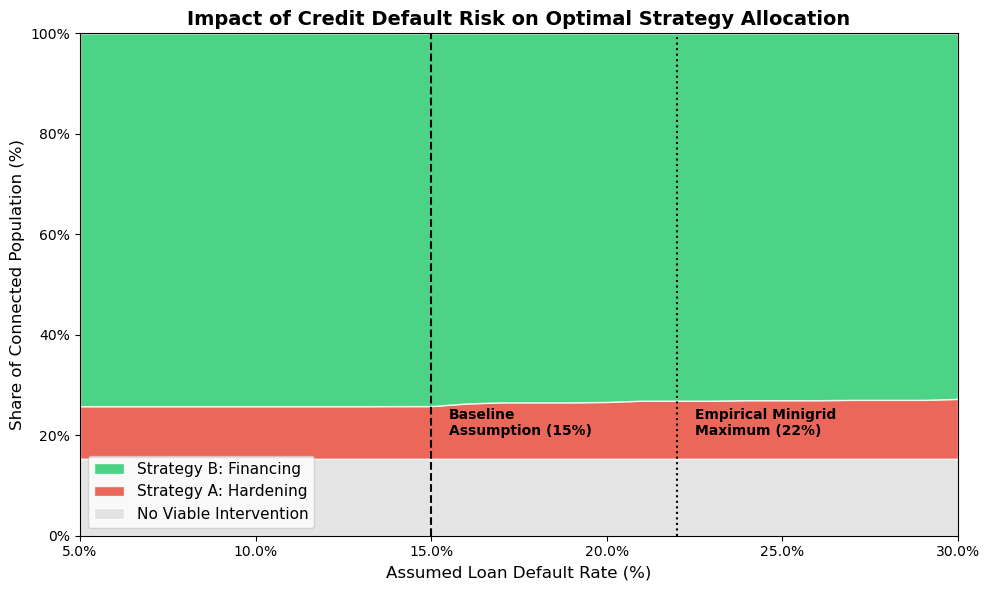

In [23]:
def run_default_sensitivity(agent_df, base_config, default_rates):
    shares_A = []
    shares_B = []
    shares_None = []
    
    for r in default_rates:
        # Create a temporary config with the new default rate
        cfg = base_config.copy()
        cfg['DEFAULT_RATE'] = r
        
        # Solve the Stackelberg game dynamically
        res_df = calculate_stackelberg_dynamic(agent_df, cfg, absolute_lift=0.183, eta=0.6, delta=0.2)
        
        # Filter to connected households only
        conn = res_df[res_df['Conn_Grid'] == 1]
        w_total = conn['HH_WT'].sum()
        
        if w_total > 0:
            s_A = np.average((conn['Winner'] == 'Hardening').astype(float), weights=conn['HH_WT'])
            s_B = np.average((conn['Winner'] == 'Financing').astype(float), weights=conn['HH_WT'])
            s_N = 1.0 - (s_A + s_B)
        else:
            s_A, s_B, s_N = 0, 0, 0
            
        shares_A.append(s_A)
        shares_B.append(s_B)
        shares_None.append(s_N)
        
    return np.array(shares_A), np.array(shares_B), np.array(shares_None)

# 1. Define the range of default rates to test (5% to 30%)
test_defaults = np.linspace(0.05, 0.30, 26)

# 2. Run the simulation
s_A, s_B, s_N = run_default_sensitivity(df_agents, CONFIG_FAIR, test_defaults)

# 3. Plotting the Stacked Area Chart
plt.figure(figsize=(10, 6))

# Plot the stacked areas
plt.stackplot(test_defaults * 100, 
              s_N * 100, s_A * 100, s_B * 100,
              labels=['No Viable Intervention', 'Strategy A: Hardening', 'Strategy B: Financing'],
              colors=['#e0e0e0', '#e74c3c', '#2ecc71'],
              alpha=0.85, edgecolor='white', linewidth=1)

# Annotate the specific 15% Baseline and 22% Empirical bounds
plt.axvline(15, color='black', linestyle='--', linewidth=1.5)
plt.text(15.5, 20, "Baseline\nAssumption (15%)", fontweight='bold', fontsize=10, color='black')

plt.axvline(22, color='black', linestyle=':', linewidth=1.5)
plt.text(22.5, 20, "Empirical Minigrid\nMaximum (22%)", fontweight='bold', fontsize=10, color='black')

# Formatting
plt.title("Impact of Credit Default Risk on Optimal Strategy Allocation", fontsize=14, fontweight='bold')
plt.xlabel("Assumed Loan Default Rate (%)", fontsize=12)
plt.ylabel("Share of Connected Population (%)", fontsize=12)
plt.xlim(5, 30)
plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter())

# Reverse legend order to match stack order (top to bottom)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], loc='lower left', frameon=True, fontsize=11)

plt.tight_layout()
plt.savefig("fig_default_sensitivity_area.png", dpi=300)
plt.show()

### Nigeria Analysis

In [24]:
# NG Cell 1: Imports and Nigeria File Configuration
import zipfile

np.random.seed(20260126)

NG_ZIP = "NGA_2018_MTF_v01_M_CSV.zip"
NG_ROOT = "NGA_2018_MTF_v01_M_CSV"

if not os.path.exists(NG_ROOT):
    print(">>> Unzipping Nigeria MTF archive...")
    with zipfile.ZipFile(NG_ZIP, "r") as zf:
        zf.extractall(".")

print(f">>> Nigeria environment ready. Data directory: {NG_ROOT}")

>>> Nigeria environment ready. Data directory: NGA_2018_MTF_v01_M_CSV


In [25]:
# NG Cell 2: Load Nigeria MTF Files

def ng_read(filename, cols=None, convert_categoricals=False):
    path = os.path.join(NG_ROOT, filename)
    if not os.path.exists(path):
        print(f"Warning: {filename} not found.")
        return None
    return pd.read_stata(path, columns=cols, convert_categoricals=convert_categoricals)

print(">>> Loading Nigeria MTF files...")

# Identification / geography / urban-rural
ng_id = ng_read(
    "MTF_NG_HH_Identification.dta",
    cols=["HH_ID", "hhid", "lga", "EA_code", "state_id", "ward", "Urbanization", "locality"],
    convert_categoricals=True
)

# Electricity service
ng_c = ng_read("MTF_NG_HH_SEC_C.dta", convert_categoricals=True)

# Financial access
ng_b = ng_read("MTF_NG_HH_SEC_B.dta", convert_categoricals=False)

# Solar financing
ng_solar = ng_read("MTF_NG_HH_SEC_C_SOLAR.dta", convert_categoricals=True)

# Electrical assets
ng_assets = ng_read("MTF_NG_HH_SEC_N_ELEC_ASSET.dta", convert_categoricals=True)

# Cookstove financing ladder
ng_k = ng_read("MTF_NG_HH_SEC_K.dta", convert_categoricals=False)

print(">>> Nigeria data loaded.")
for name, obj in {
    "Identification": ng_id,
    "Electricity": ng_c,
    "Finance": ng_b,
    "Solar": ng_solar,
    "Electric Assets": ng_assets,
    "Cookstove Ladder": ng_k
}.items():
    print(f"   - {name}: {None if obj is None else obj.shape}")

>>> Loading Nigeria MTF files...
>>> Nigeria data loaded.
   - Identification: (3669, 8)
   - Electricity: (3669, 287)
   - Finance: (3669, 72)
   - Solar: (52, 27)
   - Electric Assets: (113739, 5)
   - Cookstove Ladder: (3424, 43)


In [26]:
w = pd.read_stata("ng_weights.dta")

In [27]:
# NG Cell 3: Cleaning, Merging, Reliability, Credit Proxies, and Asset Pivot

# -----------------------------
# 1. Base household table
# -----------------------------
if ng_id is None:
    raise FileNotFoundError("MTF_NG_HH_Identification.dta is required.")

ng_df = ng_id.drop_duplicates(subset="HH_ID").copy()
# -----------------------------
# Canonical ID setup
# -----------------------------
ng_df["HH_ID_full"] = pd.to_numeric(ng_df["HH_ID"], errors="coerce").astype("Int64")
ng_df["hhid_short"] = pd.to_numeric(ng_df["hhid"], errors="coerce")

# Use FULL composite HH_ID as canonical key everywhere downstream
ng_df["hhid"] = ng_df["HH_ID_full"]

# -----------------------------
# Nigeria sampling weights
# -----------------------------
print(">>> Integrating Nigeria household weights...")

ng_w = pd.read_stata("ng_weights.dta").copy()
ng_w["HH_ID_full"] = pd.to_numeric(ng_w["HH_ID"], errors="coerce").astype("Int64")

# Collapse duplicates in weight file
ng_w = (
    ng_w.groupby("HH_ID_full", as_index=False)["wt"]
    .max()
    .rename(columns={"wt": "HH_WT"})
)

# Merge weights on FULL HH_ID
ng_df = ng_df.merge(ng_w[["HH_ID_full", "HH_WT"]], on="HH_ID_full", how="left")

# Clean weights
ng_df["HH_WT"] = pd.to_numeric(ng_df["HH_WT"], errors="coerce")

# Diagnostics
print("Matched households:", ng_df["HH_WT"].notna().sum(), "out of", len(ng_df))
print("Unmatched households:", ng_df["HH_WT"].isna().sum())

# Keep weighted households only
ng_df = ng_df[ng_df["HH_WT"].notna()].copy()

print(">>> Weight integration complete.")
print("Total weighted households:", ng_df["HH_WT"].sum())
print("Unweighted sample size:", len(ng_df))
print("Mean HH weight:", ng_df["HH_WT"].mean())

# Geography aliases for compatibility with Rwanda code style
ng_df["Cluster"] = ng_df["EA_code"]
ng_df["PROVINCE"] = ng_df["state_id"]
ng_df["DISTRICT"] = ng_df["lga"]

# # Fallback weights (replace if you later locate actual survey HH weights)
# ng_df["HH_WT"] = 1.0

# Urban flag
ng_df["Is_Urban"] = (ng_df["Urbanization"].astype(str).str.lower() == "urban").astype(int)

# -----------------------------
# 2. Electricity connection + reliability (Rwanda-style direct hours)
# -----------------------------
if ng_c is None:
    raise FileNotFoundError("MTF_NG_HH_SEC_C.dta is required.")

ng_c2 = ng_c.copy()

def yesno_to_int(s):
    return s.astype(str).str.strip().str.lower().eq("yes").astype(int)

# Robust yes/no converter for Stata-labelled categorical or string fields
def to_binary_yes(series):
    s_str = series.astype(str).str.strip().str.lower()
    s_num = pd.to_numeric(series, errors="coerce")
    return (
        (s_str == "yes") |
        (s_str == "y") |
        (s_str == "1") |
        (s_num == 1)
    ).astype(int)

# Connection status
ng_c2["Conn_Grid_Main"] = to_binary_yes(ng_c2["C2"]) if "C2" in ng_c2.columns else 0
ng_c2["Conn_Mini"] = to_binary_yes(ng_c2["C43"]) if "C43" in ng_c2.columns else 0
ng_c2["Conn_Grid"] = ((ng_c2["Conn_Grid_Main"] == 1) | (ng_c2["Conn_Mini"] == 1)).astype(int)

print("Connection check:")
print(ng_c2["C2"].value_counts(dropna=False))
print(ng_c2["C43"].value_counts(dropna=False))
print(ng_c2[["Conn_Grid_Main", "Conn_Mini", "Conn_Grid"]].mean())
print(ng_c2["Conn_Grid"].value_counts(dropna=False))



# Typical availability-hour fields
# Grid: C_28b (24h), C_29b (evening 4h)
# Mini-grid: C_68b (24h), C_69b (evening 4h)
for c in ["C_28b", "C_29b", "C68b", "C69b"]:
    if c not in ng_c2.columns:
        ng_c2[c] = np.nan
    ng_c2[c] = pd.to_numeric(ng_c2[c], errors="coerce")
    ng_c2.loc[ng_c2[c].isin([888, 888.0, 999, 999.0, -8, -8.0, -9, -9.0]), c] = np.nan

# Start with main-grid hours
ng_c2["Hours"] = ng_c2["C_28b"]
ng_c2["Evening_Hrs"] = ng_c2["C_29b"]

# Override with mini-grid hours where relevant
mask_mini = ng_c2["Conn_Mini"] == 1
ng_c2.loc[mask_mini, "Hours"] = ng_c2.loc[mask_mini, "C68b"].where(
    ng_c2.loc[mask_mini, "C68b"].notna(),
    ng_c2.loc[mask_mini, "Hours"]
)
ng_c2.loc[mask_mini, "Evening_Hrs"] = ng_c2.loc[mask_mini, "C69b"].where(
    ng_c2.loc[mask_mini, "C69b"].notna(),
    ng_c2.loc[mask_mini, "Evening_Hrs"]
)

# Zero out unconnected households
mask_conn = ng_c2["Conn_Grid"] == 1
ng_c2.loc[~mask_conn, ["Hours", "Evening_Hrs"]] = 0

# Bound valid ranges
ng_c2["Hours"] = ng_c2["Hours"].where(ng_c2["Hours"].between(0, 24))
ng_c2["Evening_Hrs"] = ng_c2["Evening_Hrs"].where(ng_c2["Evening_Hrs"].between(0, 4))

# Merge into household dataframe
keep_c = [
    "HH_ID",
    "Conn_Grid",
    "Conn_Grid_Main",
    "Conn_Mini",
    "Hours",
    "Evening_Hrs"
]
ng_df = ng_df.merge(ng_c2[keep_c], on="HH_ID", how="left")

# Hierarchical imputation, Rwanda-style
for col in ["Hours", "Evening_Hrs"]:
    ng_df[col] = pd.to_numeric(ng_df[col], errors="coerce")

def ng_weighted_fill(group_series, weights):
    ok = group_series.notna() & weights.gt(0)
    if ok.any():
        return np.average(group_series[ok], weights=weights[ok])
    return np.nan

# for col in ["Hours", "Evening_Hrs"]:
#     ng_df[col] = ng_df.groupby("Cluster")[col].transform(
#         lambda s: s.fillna(ng_weighted_fill(s, ng_df.loc[s.index, "HH_WT"]))
#     )
#     ng_df[col] = ng_df.groupby("PROVINCE")[col].transform(
#         lambda s: s.fillna(ng_weighted_fill(s, ng_df.loc[s.index, "HH_WT"]))
#     )
#     ng_df[col] = ng_df[col].fillna(0.0)

for col in ["Hours", "Evening_Hrs"]:
    # Fill by Cluster
    ng_df[col] = ng_df.groupby("Cluster", observed=False)[col].transform(
        lambda s: s.fillna(ng_weighted_fill(s, ng_df.loc[s.index, "HH_WT"]))
    )
    # Fill by Province
    ng_df[col] = ng_df.groupby("PROVINCE", observed=False)[col].transform(
        lambda s: s.fillna(ng_weighted_fill(s, ng_df.loc[s.index, "HH_WT"]))
    )
    ng_df[col] = ng_df[col].fillna(0.0)

ng_df["Hours"] = ng_df["Hours"].clip(0, 24)
ng_df["Evening_Hrs"] = ng_df["Evening_Hrs"].clip(0, 4)

# Rwanda-style usability score
daily_score = (0.15 + (np.power(ng_df["Hours"] / 24.0, 0.8)) / (0.15 + 1))
evening_score = (ng_df["Evening_Hrs"] / 4.0).clip(0, 1)
m_raw = 0.7 * daily_score + 0.3 * evening_score

ng_df["m_R"] = np.where(ng_df["Conn_Grid"] == 1, m_raw.clip(0, 1), 0.0)

# -----------------------------
# 3. Financial access proxy
# -----------------------------
if ng_b is not None:
    ng_b2 = ng_b.drop_duplicates(subset="HH_ID").copy()

    loan_src_cols = [c for c in ng_b2.columns if c.startswith("B20__") and c != "B20__13"]
    savings_cols  = [c for c in ng_b2.columns if c.startswith("B17__")]

    for c in loan_src_cols + savings_cols + ["B20__13"]:
        if c in ng_b2.columns:
            ng_b2[c] = pd.to_numeric(ng_b2[c], errors="coerce").fillna(0)

    ng_b2["Any_Loan_Source"] = (ng_b2[loan_src_cols] == 1).any(axis=1).astype(int) if loan_src_cols else 0
    ng_b2["Any_Savings_Acct"] = (ng_b2[savings_cols] == 1).any(axis=1).astype(int) if savings_cols else 0
    ng_b2["Cannot_Get_Loan"] = (ng_b2["B20__13"] == 1).astype(int) if "B20__13" in ng_b2.columns else 0

    ng_b2["Has_Credit"] = ((ng_b2["Any_Loan_Source"] == 1) | (ng_b2["Any_Savings_Acct"] == 1)).astype(int)

    ng_df = ng_df.merge(
        ng_b2[["HH_ID", "Has_Credit", "Any_Loan_Source", "Any_Savings_Acct", "Cannot_Get_Loan"]],
        on="HH_ID", how="left"
    )
else:
    ng_df["Has_Credit"] = 0
    ng_df["Any_Loan_Source"] = 0
    ng_df["Any_Savings_Acct"] = 0
    ng_df["Cannot_Get_Loan"] = 0

for c in ["Has_Credit", "Any_Loan_Source", "Any_Savings_Acct", "Cannot_Get_Loan"]:
    ng_df[c] = pd.to_numeric(ng_df[c], errors="coerce").fillna(0).astype(int)

# -----------------------------
# 4. Section K financing ladder (write H03-H06 from the start)
# -----------------------------
if ng_k is None:
    raise FileNotFoundError("MTF_NG_HH_SEC_K.dta is required for Nigeria financing ladder.")

k = ng_k.copy()
k["hhid"] = pd.to_numeric(k["HH_ID"], errors="coerce").astype("Int64")

# Keep needed columns only if present
k_cols = [
    "hhid",
    "K3", "K4", "K6", "K8",
    "K3_charcoal", "K4_charcoal", "K6_charcoal", "K8_charcoal"
]
k = k[[c for c in k_cols if c in k.columns]].copy()

# Helpers:
# Wood ladder appears coded 1=yes, 2=no
# Charcoal ladder appears coded 1=yes, 0=no
def yes_12(series):
    s = pd.to_numeric(series, errors="coerce")
    return (s == 1).astype(int)

def yes_10(series):
    s = pd.to_numeric(series, errors="coerce")
    return (s == 1).astype(int)

# Non-cumulative willingness flags
cash_flag = (
    (yes_12(k["K3"]) if "K3" in k.columns else 0) |
    (yes_10(k["K3_charcoal"]) if "K3_charcoal" in k.columns else 0)
).astype(int)

m6_flag = (
    (yes_12(k["K4"]) if "K4" in k.columns else 0) |
    (yes_10(k["K4_charcoal"]) if "K4_charcoal" in k.columns else 0)
).astype(int)

m12_flag = (
    (yes_12(k["K6"]) if "K6" in k.columns else 0) |
    (yes_10(k["K6_charcoal"]) if "K6_charcoal" in k.columns else 0)
).astype(int)

m24_flag = (
    (yes_12(k["K8"]) if "K8" in k.columns else 0) |
    (yes_10(k["K8_charcoal"]) if "K8_charcoal" in k.columns else 0)
).astype(int)

# Write Rwanda-style ladder fields directly
k_ladder = pd.DataFrame({
    "hhid": k["hhid"],
    "H03": cash_flag.astype(int),   # cash-only
    "H04": m6_flag.astype(int),     # 6 months
    "H05": m12_flag.astype(int),    # 12 months
    "H06": m24_flag.astype(int)     # 24 months
})

# Collapse to one row per household if duplicates exist
k_ladder = k_ladder.groupby("hhid", as_index=False)[["H03", "H04", "H05", "H06"]].max()

# Merge ladder into main household file
ng_df = ng_df.merge(k_ladder, on="hhid", how="left")

for c in ["H03", "H04", "H05", "H06"]:
    ng_df[c] = pd.to_numeric(ng_df[c], errors="coerce").fillna(0).astype(int)

ng_df["Accept_Cash"] = ng_df["H03"].astype(int)

# -----------------------------
# 5. Electrical asset pivot
# -----------------------------
if ng_assets is None:
    raise FileNotFoundError("MTF_NG_HH_SEC_N_ELEC_ASSET.dta is required.")

asset_long = ng_assets.copy()
asset_long["own_asset"] = asset_long["own_asset"].astype(str).str.strip().str.lower().eq("yes").astype(int)
asset_long["item_id"] = asset_long["item_id"].astype(str).str.strip()

asset_wide = (
    asset_long[asset_long["own_asset"] == 1]
    .assign(val=1)
    .pivot_table(index="HH_ID", columns="item_id", values="val", aggfunc="max", fill_value=0)
    .reset_index()
)

ng_df = ng_df.merge(asset_wide, on="HH_ID", how="left")
asset_cols = [c for c in ng_df.columns if c not in ng_id.columns and c not in ng_c2.columns]
for c in asset_wide.columns:
    if c != "HH_ID":
        ng_df[c] = pd.to_numeric(ng_df[c], errors="coerce").fillna(0).astype(int)

print(">>> Nigeria household analytic file ready.")
print(ng_df.shape)

>>> Integrating Nigeria household weights...
Matched households: 3668 out of 3669
Unmatched households: 1
>>> Weight integration complete.
Total weighted households: 7962486.0
Unweighted sample size: 3668
Mean HH weight: 2170.7976
Connection check:
C2
No     1968
Yes    1700
NaN       1
Name: count, dtype: int64
C43
No     3651
Yes      17
NaN       1
Name: count, dtype: int64
Conn_Grid_Main    0.463342
Conn_Mini         0.004633
Conn_Grid         0.463887
dtype: float64
Conn_Grid
0    1967
1    1702
Name: count, dtype: int64
>>> Nigeria household analytic file ready.
(3668, 60)


In [28]:
# Mean supply hours (grid vs minigrid) — typical week

grid = ng_c2[ng_c2["Conn_Grid_Main"] == 1]
mini = ng_c2[ng_c2["Conn_Mini"] == 1]

print("Grid mean day hours:", grid["C_28b"].mean())
print("Grid mean evening hours:", grid["C_29b"].mean())
print("Mini-grid mean day hours:", mini["C68b"].mean())
print("Mini-grid mean evening hours:", mini["C69b"].mean())

Grid mean day hours: 11.643198090692124
Grid mean evening hours: 2.958183990442055
Mini-grid mean day hours: 9.23076923076923
Mini-grid mean evening hours: 2.923076923076923


In [29]:
# print(ng_df["outage_typ_week"].describe())
# print(ng_df["outage_worst_week"].describe())

In [30]:
# NG Cell 4: Tier Mapping and Agent Table

# Nigeria appliance groups mapped to Rwanda-style tiers
NG_TIER5_VARS = [
    "Air Conditioner (AC)",
    "Electric water heater",
    "Microwave oven"
]

NG_TIER4_VARS = [
    "Washing machine",
    "Electric Iron",
    "Space Heater",
    "Electric sewing machine",
    "Hair dryer",
    "Electric Water Pump",
    "Indoor Air cooler"
]

NG_TIER3_VARS = [
    "Refrigerator",
    "Freezer",
    "Rice cooker",
    "Electric food processor/blender",
    "Electric hot water pot/kettle"
]

NG_TIER2_VARS = [
    "Regular Color TV",
    "Flat color TV",
    "Black & White TV",
    "Computer",
    "Fan",
    "Radio/CD Players/sound system",
    "VCD/DVD"
]

def ng_has_any_asset(row, cols):
    return any(pd.to_numeric(row.get(c, 0), errors="coerce") > 0 for c in cols if c in row.index)

def ng_get_tier_strict(row):
    if ng_has_any_asset(row, NG_TIER5_VARS):
        return 5
    elif ng_has_any_asset(row, NG_TIER4_VARS):
        return 4
    elif ng_has_any_asset(row, NG_TIER3_VARS):
        return 3
    elif ng_has_any_asset(row, NG_TIER2_VARS):
        return 2
    elif row.get("Conn_Grid", 0) == 1:
        return 1
    else:
        return 0

ng_df["Tier"] = ng_df.apply(ng_get_tier_strict, axis=1)
ng_df["CapacityTier"] = ng_df["Tier"].astype(int)
ng_df["UsabilityIndex"] = ng_df["m_R"].astype(float)
ng_df["Accept_Cash"] = ng_df["H03"].astype(int)

ng_cols_micro = [
    "hhid", "HH_WT", "Conn_Grid", "UsabilityIndex", "CapacityTier",
    "H03", "H04", "H05", "H06"
]
ng_df_agents = ng_df[ng_cols_micro].copy()

print(">>> Nigeria ABM inputs ready.")
print(f"Avg m(R) among connected: {np.average(ng_df.loc[ng_df['Conn_Grid']==1,'m_R'], weights=ng_df.loc[ng_df['Conn_Grid']==1,'HH_WT']):.2f}")
print("Tier distribution (connected only):")
print(ng_df.loc[ng_df["Conn_Grid"] == 1, "Tier"].value_counts(normalize=True).sort_index())

>>> Nigeria ABM inputs ready.
Avg m(R) among connected: 0.64
Tier distribution (connected only):
Tier
1    0.209753
2    0.323149
3    0.066980
4    0.314924
5    0.085194
Name: proportion, dtype: float64


In [31]:
def weighted_median(values, weights):
    values = np.asarray(values)
    weights = np.asarray(weights)

    # sort by values
    sorter = np.argsort(values)
    values_sorted = values[sorter]
    weights_sorted = weights[sorter]

    # cumulative weights
    cumsum = np.cumsum(weights_sorted)
    cutoff = 0.5 * weights_sorted.sum()

    return values_sorted[cumsum >= cutoff][0]


--- NIGERIA DIAGNOSTIC REPORT ---
1. RELIABILITY (m(R))
   - National Avg: 0.64
   - Urban:        0.63
   - Rural:        0.65
------------------------------
2. CAPACITY TRAP (Share of HHs in Tier 1)
   - National Avg: 23.7%
   - Urban:        11.3%
   - Rural:        37.0%

--- NIGERIA FINANCE LIFT FROM SECTION K ---
Cash Adoption: 38.9%
+ 6 Months:    49.4%
+ 12 Months:   59.2%
+ 24 Months:   62.5%
CREDIT MULTIPLIER: 1.61x
Absolute lift used in model: 0.236


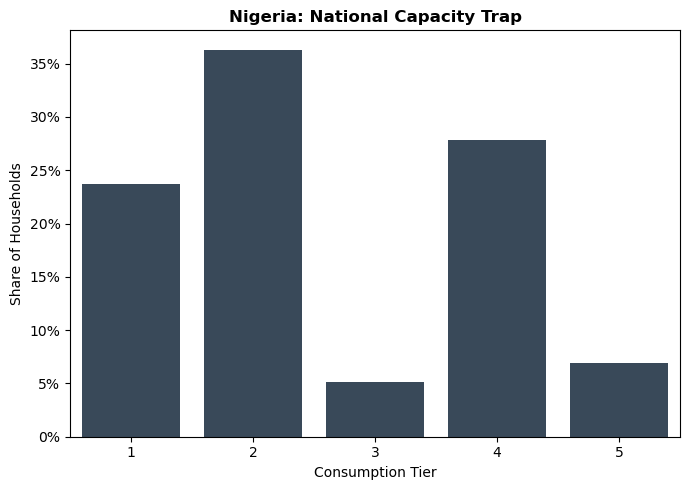

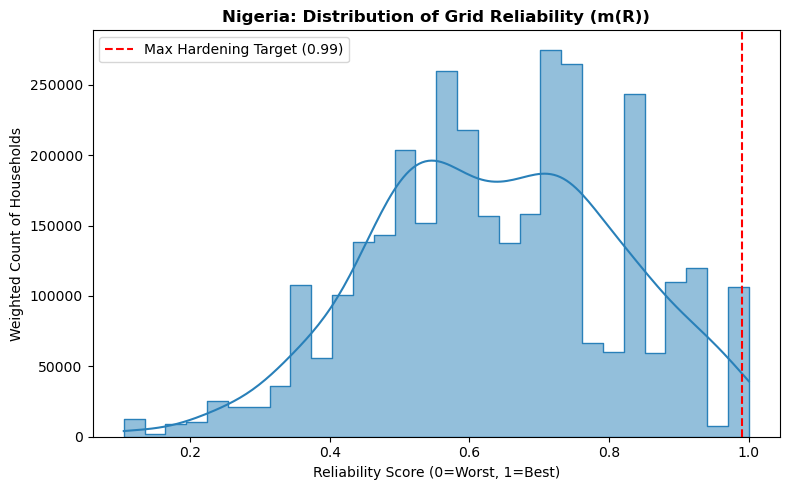

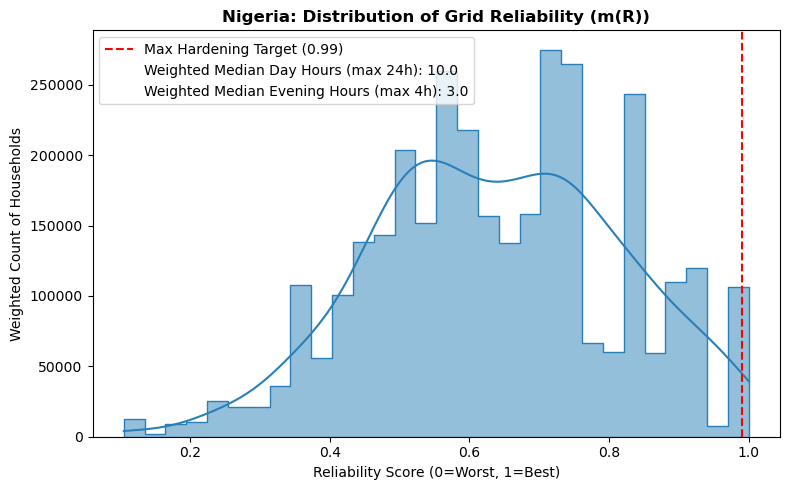

In [32]:
# NG Cell 5: Diagnostics and Provisional Nigeria Credit-Lift Proxy

ng_grid_users = ng_df[ng_df["Conn_Grid"] == 1].copy()
ng_grid_users["URB"] = np.where(ng_grid_users["Is_Urban"] == 1, "Urban", "Rural")

def ng_get_trap_share(subset_df):
    if subset_df.empty:
        return 0.0
    tier1_weight = subset_df.loc[subset_df["Tier"] <= 1, "HH_WT"].sum()
    total_weight = subset_df["HH_WT"].sum()
    return tier1_weight / total_weight if total_weight > 0 else 0.0

# ---------- Weighted median helper ----------
def wmedian(x, w):
    x = np.asarray(x)
    w = np.asarray(w)
    s = np.argsort(x)
    x, w = x[s], w[s]
    cw = np.cumsum(w) / np.sum(w)
    return x[np.searchsorted(cw, 0.5)]

# ---------- Compute weighted medians ----------
day_med = wmedian(ng_grid_users["Hours"], ng_grid_users["HH_WT"])
eve_med = wmedian(ng_grid_users["Evening_Hrs"], ng_grid_users["HH_WT"])

ng_national_trap = ng_get_trap_share(ng_grid_users)
ng_national_mr = np.average(ng_grid_users["m_R"], weights=ng_grid_users["HH_WT"])

ng_urban = ng_grid_users[ng_grid_users["URB"] == "Urban"]
ng_rural = ng_grid_users[ng_grid_users["URB"] == "Rural"]

ng_urban_trap = ng_get_trap_share(ng_urban)
ng_rural_trap = ng_get_trap_share(ng_rural)

ng_urban_mr = np.average(ng_urban["m_R"], weights=ng_urban["HH_WT"]) if len(ng_urban) else np.nan
ng_rural_mr = np.average(ng_rural["m_R"], weights=ng_rural["HH_WT"]) if len(ng_rural) else np.nan

print("--- NIGERIA DIAGNOSTIC REPORT ---")
print("1. RELIABILITY (m(R))")
print(f"   - National Avg: {ng_national_mr:.2f}")
print(f"   - Urban:        {ng_urban_mr:.2f}")
print(f"   - Rural:        {ng_rural_mr:.2f}")
print("-" * 30)
print("2. CAPACITY TRAP (Share of HHs in Tier 1)")
print(f"   - National Avg: {ng_national_trap:.1%}")
print(f"   - Urban:        {ng_urban_trap:.1%}")
print(f"   - Rural:        {ng_rural_trap:.1%}")

# ------------------------------------------------
# Nigeria finance lift from Section K ladder
# ------------------------------------------------
print("\n--- NIGERIA FINANCE LIFT FROM SECTION K ---")

k_connected = ng_df[ng_df["Conn_Grid"] == 1].copy()
w = k_connected["HH_WT"]

rate_cash  = np.average((k_connected["H03"] == 1).astype(float), weights=w)
rate_6m    = np.average(((k_connected["H03"] == 1) | (k_connected["H04"] == 1)).astype(float), weights=w)
rate_12m   = np.average(((k_connected["H03"] == 1) | (k_connected["H04"] == 1) | (k_connected["H05"] == 1)).astype(float), weights=w)
rate_total = np.average(((k_connected["H03"] == 1) | (k_connected["H04"] == 1) | (k_connected["H05"] == 1) | (k_connected["H06"] == 1)).astype(float), weights=w)

PROB_LIFT_FROM_DATA_NG = float(max(rate_total - rate_cash, 0.01))
multiplier = rate_total / rate_cash if rate_cash > 0 else np.nan

print(f"Cash Adoption: {rate_cash:.1%}")
print(f"+ 6 Months:    {rate_6m:.1%}")
print(f"+ 12 Months:   {rate_12m:.1%}")
print(f"+ 24 Months:   {rate_total:.1%}")
print(f"CREDIT MULTIPLIER: {multiplier:.2f}x")
print(f"Absolute lift used in model: {PROB_LIFT_FROM_DATA_NG:.3f}")

# Simple diagnostic plots
plt.figure(figsize=(7,5))
nat_trap = ng_grid_users.groupby("Tier")["HH_WT"].sum().reset_index()
nat_trap["Pct"] = nat_trap["HH_WT"] / nat_trap["HH_WT"].sum()
sns.barplot(data=nat_trap, x="Tier", y="Pct", order=[1,2,3,4,5], color="#34495e")
plt.title("Nigeria: National Capacity Trap", fontweight="bold")
plt.ylabel("Share of Households")
plt.xlabel("Consumption Tier")
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig("ng_fig_capacity_trap_national.png", dpi=300)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=ng_grid_users, x="m_R", weights="HH_WT", bins=30, kde=True, color="#2980b9", element="step")
plt.title("Nigeria: Distribution of Grid Reliability (m(R))", fontweight="bold")
plt.xlabel("Reliability Score (0=Worst, 1=Best)")
plt.ylabel("Weighted Count of Households")
plt.axvline(0.99, color="red", linestyle="--", label="Max Hardening Target (0.99)")
plt.legend()
plt.tight_layout()
plt.savefig("ng_fig_reliability_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(
    data=ng_grid_users, x="m_R", weights="HH_WT",
    bins=30, kde=True, color="#2980b9", element="step"
)

plt.title("Nigeria: Distribution of Grid Reliability (m(R))", fontweight="bold")
plt.xlabel("Reliability Score (0=Worst, 1=Best)")
plt.ylabel("Weighted Count of Households")

plt.axvline(0.99, color="red", linestyle="--", label="Max Hardening Target (0.99)")

# ---------- Legend text block ----------
plt.plot([], [], ' ', label=f"Weighted Median Day Hours (max 24h): {day_med:.1f}")
plt.plot([], [], ' ', label=f"Weighted Median Evening Hours (max 4h): {eve_med:.1f}")

plt.legend()
plt.tight_layout()
plt.savefig("ng_fig_reliability_distribution.png", dpi=300)
plt.show()


--- NIGERIA CREDIT LIFT (SECTION K LADDER) ---
Cash Adoption: 38.9%
+ 6 Months:    49.4%
+ 12 Months:   59.2%
+ 24 Months:   62.5%
CREDIT MULTIPLIER: 1.61x
Absolute lift used in model: 0.236


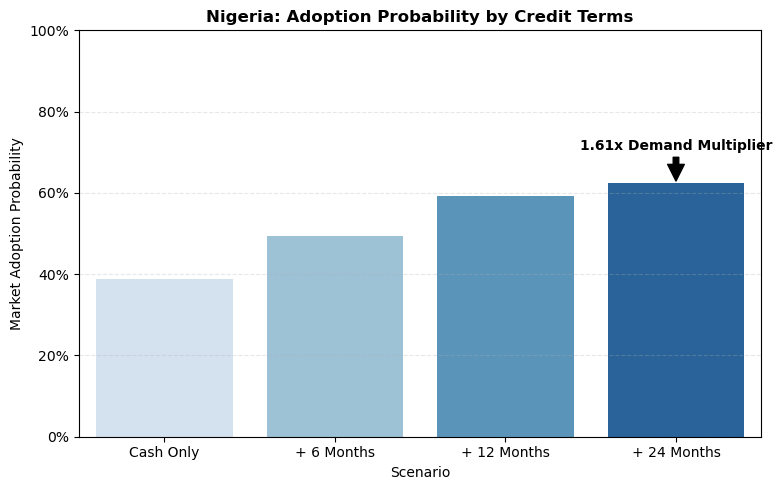

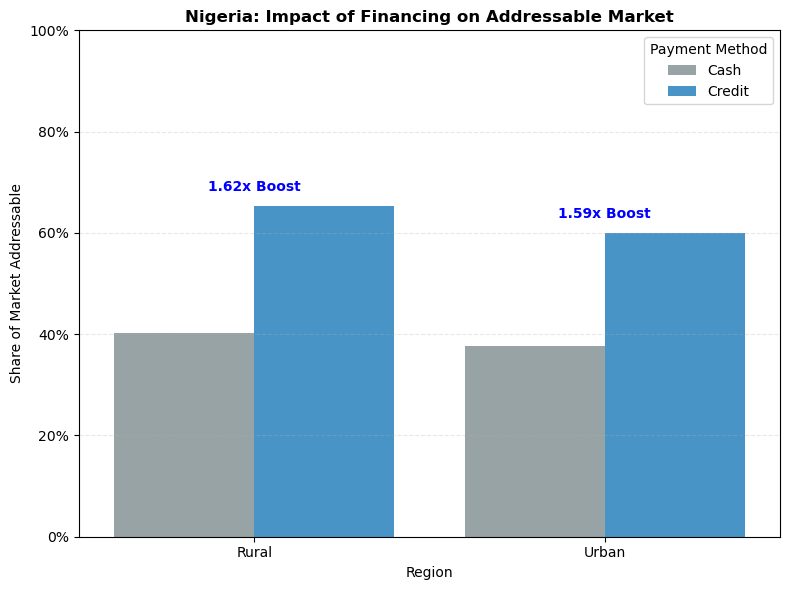

In [33]:
# NG Cell 5b: Credit Lift Plots from Section-K Ladder Already Written into ng_df

print("\n--- NIGERIA CREDIT LIFT (SECTION K LADDER) ---")

k_connected = ng_df[ng_df["Conn_Grid"] == 1].copy()
w = k_connected["HH_WT"]

rate_cash  = np.average((k_connected["H03"] == 1).astype(float), weights=w)
rate_6m    = np.average(((k_connected["H03"] == 1) | (k_connected["H04"] == 1)).astype(float), weights=w)
rate_12m   = np.average(((k_connected["H03"] == 1) | (k_connected["H04"] == 1) | (k_connected["H05"] == 1)).astype(float), weights=w)
rate_total = np.average(((k_connected["H03"] == 1) | (k_connected["H04"] == 1) | (k_connected["H05"] == 1) | (k_connected["H06"] == 1)).astype(float), weights=w)

multiplier = rate_total / rate_cash if rate_cash > 0 else np.nan

print(f"Cash Adoption: {rate_cash:.1%}")
print(f"+ 6 Months:    {rate_6m:.1%}")
print(f"+ 12 Months:   {rate_12m:.1%}")
print(f"+ 24 Months:   {rate_total:.1%}")
print(f"CREDIT MULTIPLIER: {multiplier:.2f}x")
print(f"Absolute lift used in model: {PROB_LIFT_FROM_DATA_NG:.3f}")

ladder_df = pd.DataFrame({
    "Scenario": ["Cash Only", "+ 6 Months", "+ 12 Months", "+ 24 Months"],
    "Adoption": [rate_cash, rate_6m, rate_12m, rate_total]
})

plt.figure(figsize=(8,5))
sns.barplot(
    data=ladder_df,
    x="Scenario",
    y="Adoption",
    hue="Scenario",
    palette="Blues",
    legend=False
)
plt.title("Nigeria: Adoption Probability by Credit Terms", fontweight="bold")
plt.ylabel("Market Adoption Probability")
plt.ylim(0, 1.0)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

if np.isfinite(multiplier):
    plt.annotate(
        f"{multiplier:.2f}x Demand Multiplier",
        xy=(3, rate_total),
        xytext=(3, min(rate_total + 0.08, 0.95)),
        arrowprops=dict(facecolor='black', shrink=0.05),
        ha='center',
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("ng_fig_credit_ladder.png", dpi=300)
plt.show()

k_connected["Region"] = np.where(k_connected["Is_Urban"] == 1, "Urban", "Rural")

rows = []
for region, g in k_connected.groupby("Region"):
    w = g["HH_WT"]
    rc = np.average((g["H03"] == 1).astype(float), weights=w)
    rt = np.average(((g["H03"] == 1) | (g["H04"] == 1) | (g["H05"] == 1) | (g["H06"] == 1)).astype(float), weights=w)
    rows.append({"Region": region, "Scenario": "Cash", "Adoption": rc})
    rows.append({"Region": region, "Scenario": "Credit", "Adoption": rt})

plot_df = pd.DataFrame(rows)

plt.figure(figsize=(8,6))
sns.barplot(
    data=plot_df,
    x="Region",
    y="Adoption",
    hue="Scenario",
    palette=["#95a5a6", "#3498db"]
)
plt.title("Nigeria: Impact of Financing on Addressable Market", fontweight="bold")
plt.ylabel("Share of Market Addressable")
plt.ylim(0, 1.0)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, region in enumerate(["Rural", "Urban"]):
    if region not in plot_df["Region"].values:
        continue
    rc = plot_df.query("Region == @region and Scenario == 'Cash'")["Adoption"].values[0]
    rt = plot_df.query("Region == @region and Scenario == 'Credit'")["Adoption"].values[0]
    mult = rt / rc if rc > 0 else np.nan
    if np.isfinite(mult):
        plt.text(i, min(rt + 0.03, 0.95), f"{mult:.2f}x Boost",
                 ha="center", fontweight="bold", color="blue")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title="Payment Method")
plt.tight_layout()
plt.savefig("ng_fig_credit_regional.png", dpi=300)
plt.show()

>>> Solving Nigeria Stackelberg model...


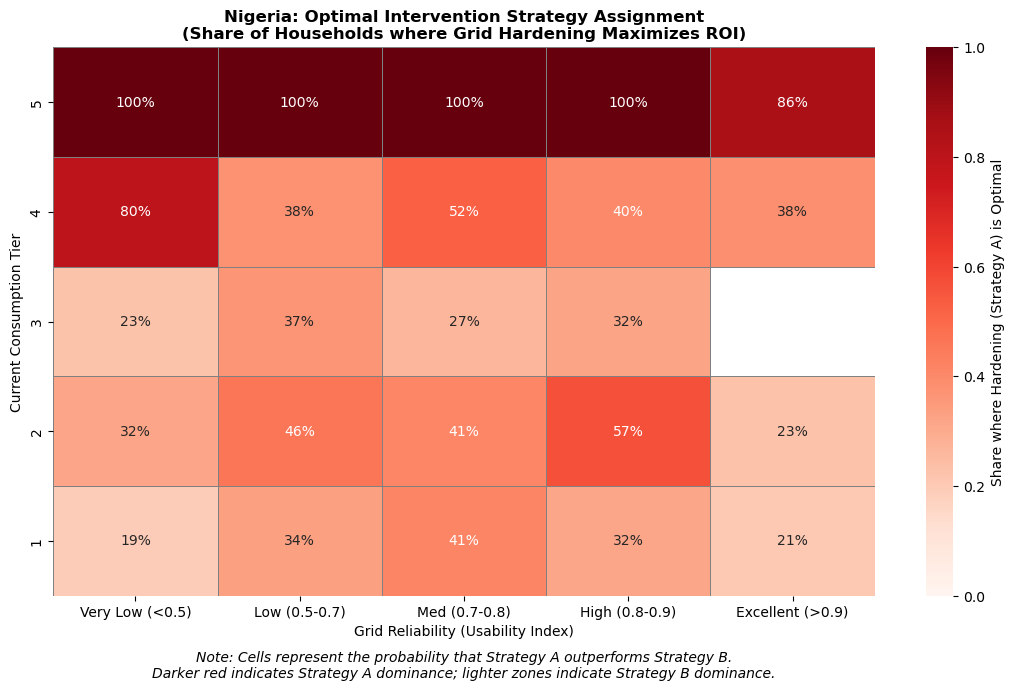


--- NIGERIA FINAL RESULTS (Connected HHs Only) ---
Financing (B) dominates in: 53.5% of households
Hardening (A) dominates in: 45.3% of households
No Viable Intervention:     1.2% of households


In [34]:
# NG Cell 6: Nigeria Stackelberg Core Analysis

# Use your existing solver if already defined; otherwise define it here
if "calculate_stackelberg_winner" not in globals():
    def block_bill(kwh, blocks):
        bill, rem, prev = 0.0, kwh, 0
        for b in sorted(blocks, key=lambda z: z["limit"]):
            span = b["limit"] - prev
            take = min(rem, span)
            bill += take * b["price"]
            rem -= take
            prev = b["limit"]
            if rem <= 0:
                break
        return bill

    def annual_bill_from_kwh(monthly_kwh, config):
        return block_bill(monthly_kwh, config["TARIFF_BLOCKS"]) * 12

    def calculate_stackelberg_winner(agent_df, config, absolute_lift=0.15):
        df = agent_df.copy()

        if "Tier" not in df.columns:
            df["Tier"] = df["CapacityTier"].astype(int) if "CapacityTier" in df.columns else 0
        if "m_R" not in df.columns:
            df["m_R"] = df["UsabilityIndex"].astype(float) if "UsabilityIndex" in df.columns else 0.0

        for c in ["H03", "H04", "H05", "H06"]:
            if c not in df.columns:
                df[c] = 0

        df["Accept_Cash"] = (pd.to_numeric(df["H03"], errors="coerce") == 1).astype(int)

        base_kwh_monthly = df["Tier"].map(config["TIER_KWH_MONTHLY"]).fillna(0)
        u0 = df["m_R"].replace(0, 0.01)

        u1 = np.minimum(u0 * 1.2, 0.99)
        base_rev = (base_kwh_monthly * u0).apply(lambda k: annual_bill_from_kwh(k, config))
        strat_A_rev = (base_kwh_monthly * u1).apply(lambda k: annual_bill_from_kwh(k, config))
        rev_gain_A = strat_A_rev - base_rev
        cost_A = config["COST_GRID_PER_HH"]
        df["ROI_A"] = np.where(df["Conn_Grid"] == 1, rev_gain_A / cost_A, 0.0)

        next_kwh_monthly = (df["Tier"] + 1).clip(0, 5).map(config["TIER_KWH_MONTHLY"])
        next_rev = (next_kwh_monthly * u0).apply(lambda k: annual_bill_from_kwh(k, config))

        risk_cost = config["COST_CAPITAL_SUBSIDY"] * config["DEFAULT_RATE"]
        unit_cost_B = max(risk_cost + config["ADMIN_PER_LOAN"], 1e-9)

        rev_gain_B = (next_rev - base_rev) * absolute_lift * np.power(u0, 0.6)

        elig_B = (df["Tier"] < 5) & ((df["Accept_Cash"] == 0) | (df["H04"] == 1) | (df["H05"] == 1) | (df["H06"] == 1))
        rev_gain_B[~elig_B] = 0.0

        df["ROI_B"] = np.where(df["Conn_Grid"] == 1, rev_gain_B / unit_cost_B, 0.0)

        EPS = 1e-9
        df["Winner"] = "None"
        mask_A = (df["ROI_A"] > df["ROI_B"] + EPS) & (df["ROI_A"] > EPS)
        mask_B = (df["ROI_B"] > df["ROI_A"] + EPS) & (df["ROI_B"] > EPS)
        df.loc[mask_A, "Winner"] = "Hardening"
        df.loc[mask_B, "Winner"] = "Financing"
        return df

NG_CONFIG = {
    "P_BASE": 0.02,
    "COST_GRID_PER_HH": 100_000,
    "COST_CAPITAL_SUBSIDY": 300_000,
    "DEFAULT_RATE": 0.15,
    "ADMIN_PER_LOAN": 5_000,
    # Keep Rwanda tariff structure initially for comparability
    "TARIFF_BLOCKS": [
        {"limit": 15, "price": 89},
        {"limit": 50, "price": 310},
        {"limit": 9_999, "price": 369}
    ],
    "TIER_KWH_MONTHLY": {0:0, 1:5, 2:15, 3:30, 4:150, 5:250}
}

NG_ABS_LIFT = float(PROB_LIFT_FROM_DATA_NG)

print(">>> Solving Nigeria Stackelberg model...")
ng_df_solved = calculate_stackelberg_winner(ng_df_agents, NG_CONFIG, NG_ABS_LIFT)

# Build heatmap
rel_cats = ['Very Low (<0.5)', 'Low (0.5-0.7)', 'Med (0.7-0.8)', 'High (0.8-0.9)', 'Excellent (>0.9)']
rel_dtype = pd.CategoricalDtype(categories=rel_cats, ordered=True)

ng_df_solved["Rel_Bin"] = pd.cut(
    ng_df_solved["m_R"],
    bins=[0, 0.5, 0.7, 0.8, 0.9, 1.0],
    labels=rel_cats,
    include_lowest=True
).astype(rel_dtype)

ng_conn = ng_df_solved[ng_df_solved["Conn_Grid"] == 1].copy()
ng_conn["A_win"] = (ng_conn["Winner"] == "Hardening").astype(float)
ng_conn["B_win"] = (ng_conn["Winner"] == "Financing").astype(float)

def ng_wmean(x, w):
    return np.average(x, weights=w) if np.sum(w) > 0 else np.nan

# ng_pivot_A = (
#     ng_conn.groupby(["Tier", "Rel_Bin"], observed=False)
#     .apply(lambda g: ng_wmean(g["A_win"], g["HH_WT"]))
#     .unstack()
# )

ng_pivot_A = (
    ng_conn.groupby(["Tier", "Rel_Bin"], observed=False)[["A_win", "HH_WT"]]
    .apply(lambda g: ng_wmean(g["A_win"], g["HH_WT"]))
    .unstack()
)

tier_order = [5, 4, 3, 2, 1]
ng_pivot_A = ng_pivot_A.reindex(index=tier_order, columns=rel_cats).fillna(0.0)

ng_support_w = (
    ng_conn.groupby(["Tier", "Rel_Bin"], observed=False)["HH_WT"]
    .sum().unstack()
    .reindex(index=tier_order, columns=rel_cats)
    .fillna(0.0)
)

ng_support_pct = ng_support_w / ng_support_w.values.sum() * 100.0
ng_mask_low = ng_support_pct < 0.5

ng_annot = (ng_pivot_A * 100).round().astype(int).astype(str) + '%'
ng_annot = ng_annot.where(~ng_mask_low, other='')

plt.figure(figsize=(11, 7))
sns.heatmap(
    ng_pivot_A,
    annot=ng_annot,
    fmt='',
    cmap="Reds",
    mask=ng_mask_low,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Share where Hardening (Strategy A) is Optimal'},
    linewidths=0.5, linecolor='gray'
)

plt.title("Nigeria: Optimal Intervention Strategy Assignment\n(Share of Households where Grid Hardening Maximizes ROI)", fontsize=12, fontweight='bold')
plt.ylabel("Current Consumption Tier")
plt.xlabel("Grid Reliability (Usability Index)")
plt.text(
    0.5, -0.15,
    "Note: Cells represent the probability that Strategy A outperforms Strategy B.\nDarker red indicates Strategy A dominance; lighter zones indicate Strategy B dominance.",
    transform=plt.gca().transAxes, ha='center', fontsize=10, style='italic'
)
plt.tight_layout()
plt.savefig("ng_fig_policy_dominance.png", dpi=300)
plt.show()

# Summary shares
w = ng_conn["HH_WT"]
ng_share_B = np.average(ng_conn["B_win"], weights=w)
ng_share_A = np.average(ng_conn["A_win"], weights=w)
ng_share_None = 1.0 - (ng_share_A + ng_share_B)

print("\n--- NIGERIA FINAL RESULTS (Connected HHs Only) ---")
print(f"Financing (B) dominates in: {ng_share_B:.1%} of households")
print(f"Hardening (A) dominates in: {ng_share_A:.1%} of households")
print(f"No Viable Intervention:     {ng_share_None:.1%} of households")

In [35]:
np.average(ng_df["m_R"], weights=ng_df["HH_WT"])

np.float64(0.26363357382928615)

In [36]:
np.average(
    ng_df.loc[ng_df["Conn_Grid"]==1,"m_R"],
    weights=ng_df.loc[ng_df["Conn_Grid"]==1,"HH_WT"]
)

np.float64(0.6391436446833273)

In [37]:
# NG Cell 7: Optional Rwanda vs Nigeria Summary Comparison
# Run this only if your Rwanda df / df_solved / PROB_LIFT_FROM_DATA still exist in memory.

comparison_rows = []

# Nigeria
comparison_rows.append({
    "Country": "Nigeria (NW sample)",
    "Connected HHs": int((ng_df["Conn_Grid"] == 1).sum()),
    "Mean m(R)": round(np.average(ng_df.loc[ng_df["Conn_Grid"] == 1, "m_R"], weights=ng_df.loc[ng_df["Conn_Grid"] == 1, "HH_WT"]), 3),
    "Tier 1 Share": round((ng_df.loc[(ng_df["Conn_Grid"] == 1) & (ng_df["Tier"] == 1), "HH_WT"].sum() /
                           ng_df.loc[ng_df["Conn_Grid"] == 1, "HH_WT"].sum()), 3),
    "Finance Lift Proxy": round(PROB_LIFT_FROM_DATA_NG, 3),
    "Financing Optimal": round(ng_share_B, 3),
    "Hardening Optimal": round(ng_share_A, 3),
    "No Viable": round(ng_share_None, 3)
})

# Rwanda if present
if "df" in globals() and "df_solved" in globals():
    rw_conn = df_solved[df_solved["Conn_Grid"] == 1].copy()
    rw_conn["A_win"] = (rw_conn["Winner"] == "Hardening").astype(float)
    rw_conn["B_win"] = (rw_conn["Winner"] == "Financing").astype(float)

    rw_w = rw_conn["HH_WT"]
    rw_share_B = np.average(rw_conn["B_win"], weights=rw_w)
    rw_share_A = np.average(rw_conn["A_win"], weights=rw_w)
    rw_share_None = 1.0 - (rw_share_A + rw_share_B)

    comparison_rows.insert(0, {
        "Country": "Rwanda",
        "Connected HHs": int((df["Conn_Grid"] == 1).sum()),
        "Mean m(R)": round(np.average(df.loc[df["Conn_Grid"] == 1, "m_R"], weights=df.loc[df["Conn_Grid"] == 1, "HH_WT"]), 3),
        "Tier 1 Share": round((df.loc[(df["Conn_Grid"] == 1) & (df["Tier"] == 1), "HH_WT"].sum() /
                               df.loc[df["Conn_Grid"] == 1, "HH_WT"].sum()), 3),
        "Finance Lift Proxy": round(float(PROB_LIFT_FROM_DATA), 3) if "PROB_LIFT_FROM_DATA" in globals() else np.nan,
        "Financing Optimal": round(rw_share_B, 3),
        "Hardening Optimal": round(rw_share_A, 3),
        "No Viable": round(rw_share_None, 3)
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))
comparison_df.to_csv("rwanda_nigeria_comparison_table.csv", index=False)

            Country  Connected HHs  Mean m(R)  Tier 1 Share  Finance Lift Proxy  Financing Optimal  Hardening Optimal  No Viable
             Rwanda           2661      0.965         0.489               0.183              0.742              0.105      0.153
Nigeria (NW sample)           1702      0.639         0.237               0.236              0.535              0.453      0.012


In [38]:
print("NG lift:", NG_ABS_LIFT)
print("RW lift:", ABSOLUTE_LIFT)

print("NG config:", NG_CONFIG)
print("RW config:", CONFIG_FAIR)

NG lift: 0.2363783805976269
RW lift: 0.18339567813502683
NG config: {'P_BASE': 0.02, 'COST_GRID_PER_HH': 100000, 'COST_CAPITAL_SUBSIDY': 300000, 'DEFAULT_RATE': 0.15, 'ADMIN_PER_LOAN': 5000, 'TARIFF_BLOCKS': [{'limit': 15, 'price': 89}, {'limit': 50, 'price': 310}, {'limit': 9999, 'price': 369}], 'TIER_KWH_MONTHLY': {0: 0, 1: 5, 2: 15, 3: 30, 4: 150, 5: 250}}
RW config: {'P_BASE': 0.02, 'COST_GRID_PER_HH': 100000, 'COST_CAPITAL_SUBSIDY': 300000, 'DEFAULT_RATE': 0.15, 'ADMIN_PER_LOAN': 5000, 'TARIFF_BLOCKS': [{'limit': 15, 'price': 89}, {'limit': 50, 'price': 310}, {'limit': 9999, 'price': 369}], 'TIER_KWH_MONTHLY': {0: 0, 1: 5, 2: 15, 3: 30, 4: 150, 5: 250}}


In [39]:
print("NG lift:", NG_ABS_LIFT)
print("RW lift:", ABSOLUTE_LIFT)

print("NG config:", NG_CONFIG)
print("RW config:", CONFIG_FAIR)

NG lift: 0.2363783805976269
RW lift: 0.18339567813502683
NG config: {'P_BASE': 0.02, 'COST_GRID_PER_HH': 100000, 'COST_CAPITAL_SUBSIDY': 300000, 'DEFAULT_RATE': 0.15, 'ADMIN_PER_LOAN': 5000, 'TARIFF_BLOCKS': [{'limit': 15, 'price': 89}, {'limit': 50, 'price': 310}, {'limit': 9999, 'price': 369}], 'TIER_KWH_MONTHLY': {0: 0, 1: 5, 2: 15, 3: 30, 4: 150, 5: 250}}
RW config: {'P_BASE': 0.02, 'COST_GRID_PER_HH': 100000, 'COST_CAPITAL_SUBSIDY': 300000, 'DEFAULT_RATE': 0.15, 'ADMIN_PER_LOAN': 5000, 'TARIFF_BLOCKS': [{'limit': 15, 'price': 89}, {'limit': 50, 'price': 310}, {'limit': 9999, 'price': 369}], 'TIER_KWH_MONTHLY': {0: 0, 1: 5, 2: 15, 3: 30, 4: 150, 5: 250}}


In [40]:
print(ng_df_agents.describe(include="all"))
print("\nMissing values:")
print(ng_df_agents.isna().sum())
print("\nConnected share:", ng_df_agents["Conn_Grid"].mean())
print("\nTier counts:")
print(ng_df.assign(Tier=ng_df["CapacityTier"]).loc[ng_df["Conn_Grid"]==1, "CapacityTier"].value_counts().sort_index())
print("\nm_R summary among connected:")
print(ng_df.loc[ng_df["Conn_Grid"]==1, "UsabilityIndex"].describe())

                       hhid         HH_WT    Conn_Grid  UsabilityIndex  \
count                3668.0   3668.000000  3668.000000     3668.000000   
mean   6849138841734.179688   2170.797607     0.464013        0.305495   
std    4132304732463.172363   3004.397705     0.498771        0.352277   
min         1000506120305.0     14.160000     0.000000        0.000000   
25%         3008515461326.0    570.419983     0.000000        0.000000   
50%        10002502681451.5   1114.160034     0.000000        0.000000   
75%        11001502105526.0   2363.479980     1.000000        0.656096   
max        12019518883301.0  30639.449219     1.000000        1.000000   

       CapacityTier          H03          H04          H05          H06  
count   3668.000000  3668.000000  3668.000000  3668.000000  3668.000000  
mean       1.481461     0.337241     0.094057     0.095147     0.045529  
std        1.600871     0.472832     0.291947     0.293458     0.208489  
min        0.000000     0.000000     

In [41]:
# NG Check 1: ROI summary by tier

tmp = ng_df_solved.copy()
tmp["Tier"] = tmp["CapacityTier"] if "CapacityTier" in tmp.columns else tmp["Tier"]

roi_summary = (
    tmp[tmp["Conn_Grid"] == 1]
    .groupby("Tier")
    # Slice all necessary columns here to exclude the 'Tier' column from the group DataFrame
    [["m_R", "ROI_A", "ROI_B", "HH_WT"]]
    .apply(lambda g: pd.Series({
        "n": len(g),
        "mean_mR": np.average(g["m_R"], weights=g["HH_WT"]),
        "mean_ROI_A": np.average(g["ROI_A"], weights=g["HH_WT"]),
        "mean_ROI_B": np.average(g["ROI_B"], weights=g["HH_WT"]),
        "share_A_pos": np.average((g["ROI_A"] > 0).astype(float), weights=g["HH_WT"]),
        "share_B_pos": np.average((g["ROI_B"] > 0).astype(float), weights=g["HH_WT"]),
        "share_A_gt_B": np.average((g["ROI_A"] > g["ROI_B"]).astype(float), weights=g["HH_WT"]),
        "share_B_gt_A": np.average((g["ROI_B"] > g["ROI_A"]).astype(float), weights=g["HH_WT"])
    }))
)

print(roi_summary.round(4))

          n  mean_mR  mean_ROI_A  mean_ROI_B  share_A_pos  share_B_pos  \
Tier                                                                     
1     357.0   0.6114      0.0056      0.0166       0.9688       0.6975   
2     550.0   0.6509      0.0187      0.0505       0.9840       0.5610   
3     114.0   0.6501      0.1167      0.7419       0.9795       0.6493   
4     536.0   0.6439      0.7532      0.5794       0.9777       0.5569   
5     145.0   0.6453      1.2607      0.0000       0.9890       0.0000   

      share_A_gt_B  share_B_gt_A  
Tier                              
1           0.2928        0.7072  
2           0.4332        0.5668  
3           0.3301        0.6699  
4           0.5036        0.4964  
5           0.9890        0.0110  


In [42]:
elig_B = (df["Tier"] < 5) & ((df["Accept_Cash"] == 0) | (df["H04"] == 1) | (df["H05"] == 1) | (df["H06"] == 1))

In [43]:
# NG Check 2: financing eligibility

tmp = ng_df_solved.copy()
tmp["Tier"] = tmp["CapacityTier"] if "CapacityTier" in tmp.columns else tmp["Tier"]

elig_B = (tmp["Tier"] < 5) & (
    (tmp["Accept_Cash"] == 0) | (tmp["H04"] == 1) | (tmp["H05"] == 1) | (tmp["H06"] == 1)
)

# Define the columns we need for the calculation
calc_cols = ["HH_WT", "H03", "H04", "H05", "H06"]

elig_summary = (
    tmp[tmp["Conn_Grid"] == 1]
    .groupby("Tier")
    [calc_cols]  # Explicitly select only the necessary columns
    .apply(lambda g: pd.Series({
        "share_eligible_B": np.average(elig_B.loc[g.index].astype(float), weights=g["HH_WT"]),
        "share_H03_cash": np.average((g["H03"] == 1).astype(float), weights=g["HH_WT"]),
        "share_H04": np.average((g["H04"] == 1).astype(float), weights=g["HH_WT"]),
        "share_H05": np.average((g["H05"] == 1).astype(float), weights=g["HH_WT"]),
        "share_H06": np.average((g["H06"] == 1).astype(float), weights=g["HH_WT"])
    }))
)
print(elig_summary.round(4))

      share_eligible_B  share_H03_cash  share_H04  share_H05  share_H06
Tier                                                                   
1               0.6975          0.3025     0.1193     0.0927     0.0462
2               0.5610          0.4390     0.1003     0.1227     0.0303
3               0.6493          0.3507     0.1198     0.0870     0.0252
4               0.5569          0.4431     0.1021     0.0776     0.0452
5               0.0000          0.2362     0.0743     0.0847     0.0118


In [44]:
# NG Check 3: inspect households in hardening-dominant bins

tmp = ng_df_solved.copy()
tmp["Rel_Bin"] = pd.cut(
    tmp["m_R"],
    bins=[0, 0.5, 0.7, 0.8, 0.9, 1.0],
    labels=['Very Low (<0.5)', 'Low (0.5-0.7)', 'Med (0.7-0.8)', 'High (0.8-0.9)', 'Excellent (>0.9)'],
    include_lowest=True
)

inspect = tmp[
    (tmp["Conn_Grid"] == 1) &
    (
        ((tmp["CapacityTier"] == 5)) |
        ((tmp["CapacityTier"] == 4) & (tmp["Rel_Bin"] == 'Very Low (<0.5)'))
    )
][["hhid", "CapacityTier", "m_R", "H03", "H04", "H05", "H06", "ROI_A", "ROI_B", "Winner", "HH_WT"]]

print(inspect.head(30))

              hhid  CapacityTier       m_R  H03  H04  H05  H06     ROI_A  \
143  1007507541901             4  0.445326    1    0    0    0  0.591571   
210  1012500800501             5  0.454604    1    0    0    0  1.006493   
219  1012500802701             5  0.800488    0    0    0    0  1.772281   
230  1012509342901             4  0.250171    1    0    0    0  0.279191   
232  1012509343301             4  0.455795    0    0    0    0  0.605478   
235  1012509344601             5  0.657757    1    0    0    0  1.456274   
237  1013501240301             5  0.605795    1    0    0    0  1.341229   
246  1013501241701             5  0.407156    1    0    0    0  0.901443   
266  1013507620601             4  0.370326    1    0    0    0  0.491941   
267  1013507620701             5  0.657757    1    0    0    0  1.456274   
272  1013507621901             5  0.550171    1    0    0    0  1.218078   
290  1016504160401             4  0.455795    1    0    0    0  0.605478   
292  1016504

In [45]:
# NG Check 4: weighted support by heatmap cell
print((ng_support_pct.round(2)).fillna(0))

Rel_Bin  Very Low (<0.5)  Low (0.5-0.7)  Med (0.7-0.8)  High (0.8-0.9)  \
Tier                                                                     
5                   1.42           2.74           1.61            0.64   
4                   6.06          10.25           5.75            3.72   
3                   1.09           2.18           0.80            0.71   
2                   5.65          15.08           7.02            6.24   
1                   6.59           8.92           3.41            2.55   

Rel_Bin  Excellent (>0.9)  
Tier                       
5                    0.54  
4                    2.08  
3                    0.40  
2                    2.32  
1                    2.24  


In [46]:
# NG Check 5: toy households

toy = pd.DataFrame({
    "hhid": [1, 2, 3],
    "HH_WT": [1, 1, 1],
    "Conn_Grid": [1, 1, 1],
    "UsabilityIndex": [0.4, 0.8, 0.95],
    "CapacityTier": [4, 4, 5],
    "H03": [0, 0, 0],
    "H04": [1, 1, 1],
    "H05": [0, 0, 0],
    "H06": [0, 0, 0]
})

toy_solved = calculate_stackelberg_winner(toy, NG_CONFIG, NG_ABS_LIFT)
print(toy_solved[["CapacityTier", "m_R", "ROI_A", "ROI_B", "Winner"]])

   CapacityTier   m_R    ROI_A     ROI_B     Winner
0             4  0.40  0.53136  0.483216  Hardening
1             4  0.80  1.06272  1.464837  Financing
2             5  0.95  0.44280  0.000000  Hardening


In [47]:
# NG Check 6: mild perturbation tests

for lift in [NG_ABS_LIFT * 0.75, NG_ABS_LIFT, NG_ABS_LIFT * 1.25]:
    res = calculate_stackelberg_winner(ng_df_agents, NG_CONFIG, lift)
    conn = res[res["Conn_Grid"] == 1]
    w = conn["HH_WT"]
    share_A = np.average((conn["Winner"] == "Hardening").astype(float), weights=w)
    share_B = np.average((conn["Winner"] == "Financing").astype(float), weights=w)
    share_N = 1 - share_A - share_B
    print(f"Lift={lift:.3f} -> A={share_A:.1%}, B={share_B:.1%}, None={share_N:.1%}")

Lift=0.177 -> A=56.8%, B=42.0%, None=1.2%
Lift=0.236 -> A=45.3%, B=53.5%, None=1.2%
Lift=0.295 -> A=43.4%, B=55.4%, None=1.2%


In [48]:
print(ng_df_agents[["H03", "H04", "H05", "H06"]].mean())

H03    0.337241
H04    0.094057
H05    0.095147
H06    0.045529
dtype: float64


--- NIGERIA STRUCTURAL SENSITIVITY ANALYSIS (Baseline Share: 53.5%) ---
Default Rate | Low: 55.8% | High: 38.0%
Grid Hardening Cost | Low: 53.5% | High: 55.8%
Removal of Credit Guarantee (Full Principal Cost): 9.6%
Reliability Sensitivity ($\eta = 2.0$): 32.2%
Hardening Effectiveness ($\delta = 50\%$): 35.2%
Credit Effectiveness (Adoption Lift = 1%): 1.7%


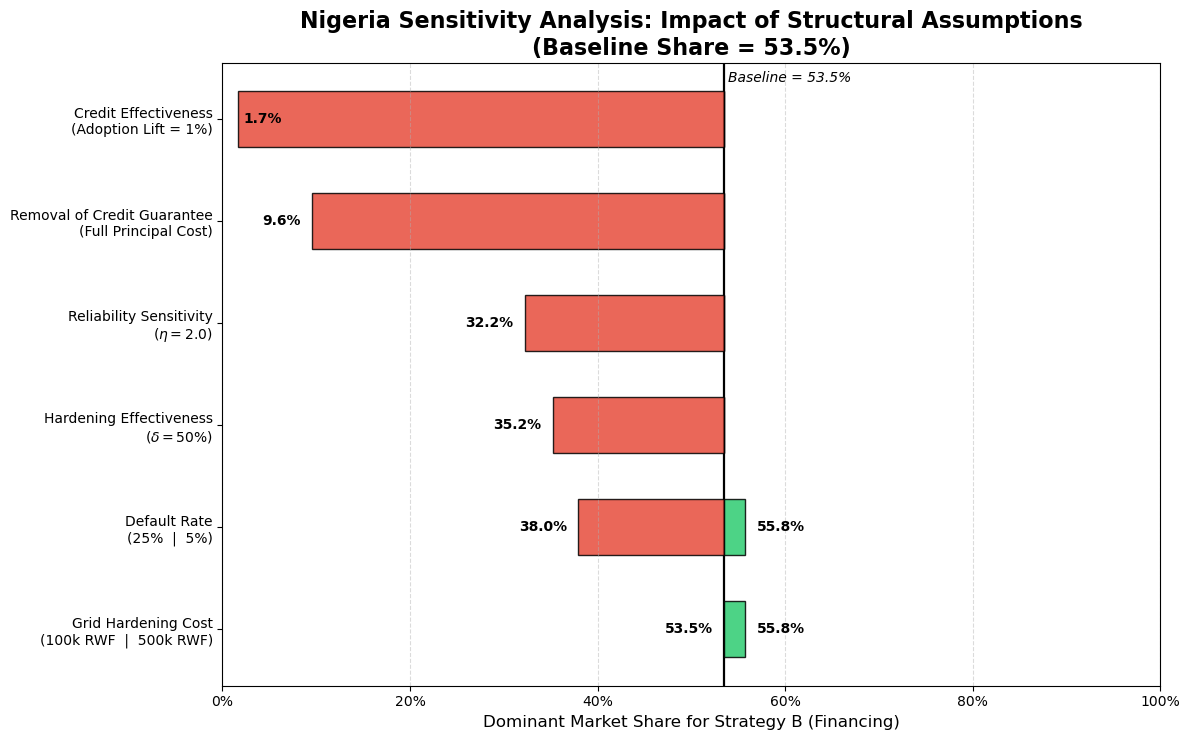

In [49]:
# NG Cell: Sensitivity Analysis - True Tornado Style (Nigeria)
# 1. Dynamic solver for Nigeria
def calculate_stackelberg_dynamic_ng(agent_df, config, absolute_lift=0.236, eta=0.6, delta=0.2):
    df = agent_df.copy()

    # Aliases
    if 'Tier' not in df.columns:
        df['Tier'] = df['CapacityTier'].astype(int)
    if 'm_R' not in df.columns:
        df['m_R'] = df['UsabilityIndex'].astype(float)
    df['Accept_Cash'] = (pd.to_numeric(df['H03'], errors='coerce') == 1).astype(int)

    # Baseline revenue
    base_kwh = df['Tier'].map(config['TIER_KWH_MONTHLY']).fillna(0)
    u0 = df['m_R'].replace(0, 0.01)

    # Strategy A: Hardening
    u1 = np.minimum(u0 * (1 + delta), 0.99)
    base_rev = (base_kwh * u0).apply(lambda k: annual_bill_from_kwh(k, config))
    strat_A_rev = (base_kwh * u1).apply(lambda k: annual_bill_from_kwh(k, config))

    gain_A = strat_A_rev - base_rev
    cost_A = config['COST_GRID_PER_HH']
    df['ROI_A'] = np.where(df['Conn_Grid'] == 1, gain_A / cost_A, 0.0)

    # Strategy B: Financing
    next_kwh = (df['Tier'] + 1).clip(0, 5).map(config['TIER_KWH_MONTHLY']).fillna(0)
    next_rev = (next_kwh * u0).apply(lambda k: annual_bill_from_kwh(k, config))

    prob_adopt = absolute_lift * np.power(u0, eta)
    rev_gain_B = (next_rev - base_rev) * prob_adopt

    risk_cost = config['COST_CAPITAL_SUBSIDY'] * config['DEFAULT_RATE']
    cost_B = max(risk_cost + config['ADMIN_PER_LOAN'], 1e-9)

    elig_B = (
        (df['Tier'] < 5) &
        ((df['Accept_Cash'] == 0) | (df['H04'] == 1) | (df['H05'] == 1) | (df['H06'] == 1))
    )
    rev_gain_B[~elig_B] = 0.0

    df['ROI_B'] = np.where(df['Conn_Grid'] == 1, rev_gain_B / cost_B, 0.0)

    # Winner
    EPS = 1e-9
    df['Winner'] = 'None'
    mask_A = (df['ROI_A'] > df['ROI_B'] + EPS) & (df['ROI_A'] > EPS)
    mask_B = (df['ROI_B'] > df['ROI_A'] + EPS) & (df['ROI_B'] > EPS)
    df.loc[mask_A, 'Winner'] = 'Hardening'
    df.loc[mask_B, 'Winner'] = 'Financing'

    return df


# 2. Helper
def get_financing_share_ng(agent_df, cfg, lift, eta, delta):
    res_df = calculate_stackelberg_dynamic_ng(
        agent_df, cfg, absolute_lift=lift, eta=eta, delta=delta
    )
    conn = res_df[res_df['Conn_Grid'] == 1]
    if len(conn) == 0:
        return 0.0
    return np.average((conn['Winner'] == 'Financing').astype(float), weights=conn['HH_WT'])


# 3. Baseline
ng_base_cfg = NG_CONFIG.copy()
ng_base_lift = NG_ABS_LIFT
ng_base_eta = 0.6
ng_base_delta = 0.2

ng_base_share = get_financing_share_ng(
    ng_df_agents, ng_base_cfg, ng_base_lift, ng_base_eta, ng_base_delta
)
print(f"--- NIGERIA STRUCTURAL SENSITIVITY ANALYSIS (Baseline Share: {ng_base_share:.1%}) ---")


# 4. Define bounded and one-sided scenarios
ng_bounded_scenarios = [
    {
        "Label": "Default Rate",
        "Low": ("5%", {"DEFAULT_RATE": 0.05}),
        "High": ("25%", {"DEFAULT_RATE": 0.25})
    },
    {
        "Label": "Grid Hardening Cost",
        "Low": ("100k RWF", {"COST_GRID_PER_HH": 100000}),
        "High": ("500k RWF", {"COST_GRID_PER_HH": 500000})
    },
]

ng_one_sided_scenarios = [
    ("Removal of Credit Guarantee", "Full Principal Cost", "PRINCIPAL_MODE", True),
    ("Reliability Sensitivity", r"$\eta = 2.0$", "ETA", 2.0),
    ("Hardening Effectiveness", r"$\delta = 50\%$", "DELTA", 0.5),
    ("Credit Effectiveness", "Adoption Lift = 1%", "LIFT", 0.01),
]


# 5. Run scenarios
ng_rows = []

# bounded scenarios
for scen in ng_bounded_scenarios:
    label = scen["Label"]

    cfg_low = NG_CONFIG.copy()
    lift_low = NG_ABS_LIFT
    eta_low = 0.6
    delta_low = 0.2
    for k, v in scen["Low"][1].items():
        cfg_low[k] = v
    low_share = get_financing_share_ng(ng_df_agents, cfg_low, lift_low, eta_low, delta_low)

    cfg_high = NG_CONFIG.copy()
    lift_high = NG_ABS_LIFT
    eta_high = 0.6
    delta_high = 0.2
    for k, v in scen["High"][1].items():
        cfg_high[k] = v
    high_share = get_financing_share_ng(ng_df_agents, cfg_high, lift_high, eta_high, delta_high)

    ng_rows.append({
        "Label": label,
        "LowText": scen["Low"][0],
        "HighText": scen["High"][0],
        "LowShare": low_share,
        "HighShare": high_share,
        "Type": "bounded"
    })

    print(f"{label} | Low: {low_share:.1%} | High: {high_share:.1%}")

# one-sided scenarios
for main_label, sub_label, param, val in ng_one_sided_scenarios:
    cfg = NG_CONFIG.copy()
    lift = NG_ABS_LIFT
    eta = 0.6
    delta = 0.2

    if param == "PRINCIPAL_MODE":
        full_cost = cfg['COST_CAPITAL_SUBSIDY'] + cfg['ADMIN_PER_LOAN']
        cfg['ADMIN_PER_LOAN'] = full_cost - (cfg['COST_CAPITAL_SUBSIDY'] * cfg['DEFAULT_RATE'])
    elif param == "ETA":
        eta = val
    elif param == "DELTA":
        delta = val
    elif param == "LIFT":
        lift = val

    share = get_financing_share_ng(ng_df_agents, cfg, lift, eta, delta)

    ng_rows.append({
        "Label": main_label,
        "LowText": "",
        "HighText": sub_label,
        "LowShare": ng_base_share,
        "HighShare": share,
        "Type": "one_sided"
    })

    print(f"{main_label} ({sub_label}): {share:.1%}")

ng_tornado_df = pd.DataFrame(ng_rows)

# sort by spread
ng_tornado_df["Spread"] = (
    ng_tornado_df[["LowShare", "HighShare"]].max(axis=1) -
    ng_tornado_df[["LowShare", "HighShare"]].min(axis=1)
)
ng_tornado_df = ng_tornado_df.sort_values("Spread", ascending=True).reset_index(drop=True)


# 6. Plot tornado
plt.figure(figsize=(12, 7.5))
plt.axvline(ng_base_share, color='black', linestyle='-', linewidth=1.6, zorder=0)

label_threshold = 0.003
left_pad = 0.012
right_pad = 0.012

def draw_left_label(x, y, txt):
    # very small values go inside the bar to avoid colliding with the axis / y-labels
    if x < 0.05:
        plt.text(
            x + 0.006, y, txt,
            va='center', ha='left',
            fontsize=10, fontweight='bold',
            clip_on=False
        )
    else:
        plt.text(
            x - left_pad, y, txt,
            va='center', ha='right',
            fontsize=10, fontweight='bold',
            clip_on=False
        )

def draw_right_label(x, y, txt):
    plt.text(
        x + right_pad, y, txt,
        va='center', ha='left',
        fontsize=10, fontweight='bold',
        clip_on=False
    )

for i, row in enumerate(ng_tornado_df.itertuples()):
    y = i

    low_share_raw = row.LowShare
    high_share_raw = row.HighShare

    left_share = min(low_share_raw, high_share_raw)
    right_share = max(low_share_raw, high_share_raw)

    # Case 1: entire range below baseline -> all red
    if right_share < ng_base_share:
        plt.barh(
            y,
            right_share - left_share,
            left=left_share,
            height=0.55,
            color='#e74c3c',
            edgecolor='black',
            alpha=0.85
        )
        if (right_share - left_share) > label_threshold:
            draw_left_label(left_share, y, f"{left_share:.1%}")
            draw_right_label(right_share, y, f"{right_share:.1%}")

    # Case 2: entire range above baseline -> all green
    elif left_share >= ng_base_share:
        plt.barh(
            y,
            right_share - left_share,
            left=left_share,
            height=0.55,
            color='#2ecc71',
            edgecolor='black',
            alpha=0.85
        )
        if (right_share - left_share) > label_threshold:
            draw_left_label(left_share, y, f"{left_share:.1%}")
            draw_right_label(right_share, y, f"{right_share:.1%}")

    # Case 3: spans baseline -> red left, green right
    else:
        plt.barh(
            y,
            ng_base_share - left_share,
            left=left_share,
            height=0.55,
            color='#e74c3c',
            edgecolor='black',
            alpha=0.85
        )
        if (ng_base_share - left_share) > label_threshold:
            draw_left_label(left_share, y, f"{left_share:.1%}")

        plt.barh(
            y,
            right_share - ng_base_share,
            left=ng_base_share,
            height=0.55,
            color='#2ecc71',
            edgecolor='black',
            alpha=0.85
        )
        if (right_share - ng_base_share) > label_threshold:
            draw_right_label(right_share, y, f"{right_share:.1%}")

# labels
yticklabels = []
for row in ng_tornado_df.itertuples():
    if row.Type == "bounded":
        # if row.Label == "Grid Hardening Cost":
        #     # force reversed display order for this row
        #     yticklabels.append(f"{row.Label}\n({row.HighText}  |  {row.LowText})")
        if row.LowShare <= row.HighShare:
            
            yticklabels.append(f"{row.Label}\n({row.LowText}  |  {row.HighText})")
        else:
            yticklabels.append(f"{row.Label}\n({row.HighText}  |  {row.LowText})")
    else:
        yticklabels.append(f"{row.Label}\n({row.HighText})")

plt.yticks(np.arange(len(ng_tornado_df)), yticklabels, fontsize=10)
plt.xlabel("Dominant Market Share for Strategy B (Financing)", fontsize=12)
plt.title(
    f"Nigeria Sensitivity Analysis: Impact of Structural Assumptions\n(Baseline Share = {ng_base_share:.1%})",
    fontsize=16, fontweight='bold'
)
plt.xlim(0, 1.0)
plt.margins(x=0.02)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='x', linestyle='--', alpha=0.45)

plt.text(
    ng_base_share + 0.004, len(ng_tornado_df) - 0.60,
    f"Baseline = {ng_base_share:.1%}",
    va='center', ha='left', fontsize=10, style='italic', color='black'
)

plt.tight_layout()
plt.savefig("ng_fig_robustness_tornado.png", dpi=300)
plt.show()